In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score, ConfusionMatrixDisplay

from matplotlib.patches import Rectangle
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import brier_score_loss



In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))
    
def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])
    

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:

# cycle_range_dict = {'LuNER':{'other': np.arange(35,46),
#                             #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
#                              'RnaseP': np.arange(30,41)},
#                     'Thermo': np.arange(30,41)}

cycle_range_dict = {'LuNER':{'other': np.arange(20,45),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(20,45)},
                    'Thermo': np.arange(20,45)}
                    
fn_range = np.arange(-.99, 4, 0.01)

In [5]:
curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'LuNER', 'Thermo')

test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_test_pred_df.csv'))
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
print(test_pred.shape)
test_pred = (test_pred
             .merge(join_df.loc[~join_df.file.isin(['h0pi','dbt7']) & join_df.cycle_no == 1,['curve_idx']].drop_duplicates(), on='curve_idx')
             .merge(groundtruth_df.loc[groundtruth_df.split=='test',['curve_idx','sample_id','igi_call','groundtruth']]
                    .drop_duplicates(),
                    on='curve_idx')
             )
print(test_pred.shape)
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)


(6175, 4)
(6088, 7)


In [6]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
test_igi_fnr = igi_fn/(igi_fn+igi_tp) 
test_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
test_igi_fpr = igi_fp/(igi_fp + igi_tn)
test_igi_tpr = igi_tp/(igi_tp + igi_fn)

In [7]:
groundtruth_df.loc[groundtruth_df.groundtruth == -1, ['sample_type','curve_idx']].drop_duplicates().sample_type.value_counts()

sample_type
Negative Control (qPCR)                       1540
Human Normal Negative Control (Extraction)     548
Positive Control (qPCR)                        469
Name: count, dtype: int64

In [8]:
print('Train positive:')
print(groundtruth_df.loc[(groundtruth_df.split!='test') & 
                         (groundtruth_df.sample_type == 'Positive Control (qPCR)')].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split!='test') & 
                         (groundtruth_df.sample_type == 'Positive Control (qPCR)')].sample_id.nunique())
print('Test positive:')
print(groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (groundtruth_df.sample_type == 'Positive Control (qPCR)')].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (groundtruth_df.sample_type == 'Positive Control (qPCR)')].sample_id.nunique())

print('Train negative:')
print(groundtruth_df.loc[(groundtruth_df.split != 'test') & 
                         (~groundtruth_df.sample_type.isin(['Positive Control (qPCR)','Clinical Sample']))].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split != 'test') & 
                         (~groundtruth_df.sample_type.isin(['Positive Control (qPCR)','Clinical Sample']))].sample_id.nunique())
print('Test negative:')
print(groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (~groundtruth_df.sample_type.isin(['Positive Control (qPCR)','Clinical Sample']))].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (~groundtruth_df.sample_type.isin(['Positive Control (qPCR)','Clinical Sample']))].sample_id.nunique())

print('Train clinical:')
print(groundtruth_df.loc[(groundtruth_df.split != 'test') & 
                         (groundtruth_df.sample_type.isin(['Clinical Sample']))].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split != 'test') & 
                         (groundtruth_df.sample_type.isin(['Clinical Sample']))].sample_id.nunique())
print('Test clinical:')
print(groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (groundtruth_df.sample_type.isin(['Clinical Sample']))].curve_idx.nunique(),
      groundtruth_df.loc[(groundtruth_df.split == 'test') & 
                         (groundtruth_df.sample_type.isin(['Clinical Sample']))].sample_id.nunique())

Train positive:
1146 347
Test positive:
394 122
Train negative:
1774 541
Test negative:
556 170
Train clinical:
15661 15661
Test clinical:
5225 5225


In [9]:
groundtruth_df[groundtruth_df.groundtruth_target == 0].sample_type.value_counts()

sample_type
Negative Control (qPCR)                       1540
Human Normal Negative Control (Extraction)     548
Positive Control (qPCR)                        469
Name: count, dtype: int64

In [10]:
df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['sample_id','target']].drop_duplicates()
df['test_kit'] = np.where(df.target == 'MS2', 'Thermo', 'Luner')
df.test_kit.value_counts(normalize=True)

test_kit
Luner     0.753597
Thermo    0.246403
Name: proportion, dtype: float64

In [11]:

retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_retest_pred_df.csv'))
# retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'experimental/seq_retest_pred_df.csv'))
print(retest_pred.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_pred = (retest_pred
               .merge(join_df.loc[~join_df.file.isin(['h0pi','dbt7']) & join_df.cycle_no == 1, 'curve_idx'].drop_duplicates(), on='curve_idx')
               .merge(retest_groundtruth[['curve_idx','target','sample_id','groundtruth_target','igi_call']]
                      .loc[(retest_groundtruth.final_patient_result != 'ReSample') &
                          (~retest_groundtruth.final_patient_result.isna()) &
                      (~retest_groundtruth.curve_idx.isin(groundtruth_df[groundtruth_df.split.isin(['train','val'])].curve_idx))]
                        #   (~retest_groundtruth.target.isin(['RnaseP','MS2']))]
                          )
               .rename(columns={'groundtruth_target':'groundtruth_label'}))
# )

retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_pred.shape)

thermo_sample_ids = retest_pred[retest_pred.target == 'ORF1ab'].sample_id.unique()
retest_pred['test_kit'] = 'LuNER'
retest_pred.loc[retest_pred.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'

df = retest_pred.groupby(['sample_id','test_kit']).curve_idx.nunique().reset_index()
invalid_sample_ids = df[((df.test_kit == 'LuNER') & (df.curve_idx != 3)) | ((df.test_kit == 'Thermo') & (df.curve_idx != 4))].sample_id
retest_pred = retest_pred[~retest_pred.sample_id.isin(invalid_sample_ids)]
print('Number of valid retest samples:', retest_pred.sample_id.nunique())
print(retest_pred.shape)


(4084, 4)
(3000, 9)
Number of valid retest samples: 277
(906, 10)


In [12]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)
retest_igi_tpr = igi_tp/(igi_tp + igi_fn)

In [13]:
qpcr_test_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
print(qpcr_test_pred.shape)
qpcr_test_pred = qpcr_test_pred[qpcr_test_pred.split == 'test'].merge(test_pred[['curve_idx']], on='curve_idx')
qpcr_test_pred['prob'] = qpcr_test_pred['prob'].fillna(0)
print(qpcr_test_pred.shape)

qpcr_retest_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_retest_pred.csv'))
print(qpcr_retest_pred.shape)
qpcr_retest_pred = (qpcr_retest_pred.merge(retest_pred[['curve_idx']], on='curve_idx'))
print(qpcr_retest_pred.shape)

(24756, 5)
(6088, 5)
(4084, 4)
(906, 4)


In [14]:
qpcrdeepnet_pred = pd.read_csv('/media/ssd1/huong/PCR-huong/qpcrdeepnet/output/rn_test_aiprediction_Thu_18Apr2024_22_31_26UTC.tsv', sep='\t')
qpcrdeepnet_pred['encoded_pred'] = 1*(qpcrdeepnet_pred.prediction == 'Positive')
qpcrdeepnet_pred['prob'] = qpcrdeepnet_pred.probability.apply(lambda x: np.float64(x.replace('[','').replace(']','')))

test_qpcrdeepnet = (qpcrdeepnet_pred
                    .merge(groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_target']], left_on='id1', right_on='curve_idx')
                    .merge(test_pred[['curve_idx']], on='curve_idx'))
print(test_qpcrdeepnet.shape)
retest_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
retest_qpcrdeepnet = (qpcrdeepnet_pred
                      .merge(retest_pred[['curve_idx','groundtruth_label']], left_on='id1', right_on='curve_idx'))
print(retest_qpcrdeepnet.shape)

(6088, 10)
(906, 10)


### vary model threshold

In [15]:
model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_pred['pred'] = 1*(test_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
    
    model_dict['thres'].append(i)
    model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    model_dict['fnr'].append(fn/(fn+tp))
    model_dict['fpr'].append(fp/(fp+tn))
    model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
model_dict_df = pd.DataFrame(model_dict)
    

In [16]:
best_acc_threshold_idx = model_dict_df.acc.idxmax()
best_acc_threshold = model_dict_df.loc[best_acc_threshold_idx, 'thres']
print('Best Accuracy on Test:', model_dict_df.loc[best_acc_threshold_idx, 'acc'])
print('Best Accuracy Threshold on Test:', best_acc_threshold)
print('Best accuracy FNR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fnr'])
print('Best accuracy FPR on Test:', model_dict_df.loc[best_acc_threshold_idx, 'fpr'])

Best Accuracy on Test: 0.9870236530880421
Best Accuracy Threshold on Test: 0.5660000000000001
Best accuracy FNR on Test: 0.008225187351489673
Best accuracy FPR on Test: 0.055105348460291734


In [17]:
print('Number of Na predictions in test set:', test_pred.outputs.isna().sum())
model_test_auc = roc_auc_score(test_pred[~test_pred.outputs.isna()].groundtruth_label, test_pred[~test_pred.outputs.isna()].outputs)
print('Model AUC on test set:', model_test_auc)
test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
calc_metrics(test_pred.groundtruth_label, test_pred.pred)

Number of Na predictions in test set: 0
Model AUC on test set: 0.9978643840944754


,acc,f1,tn,fp,fn,tp
0,0.987024,0.992773,583,34,45,5426


In [18]:
igi_test_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
igi_true_pos_frac = sum(test_pred.encoded_igi_call == 1)/test_pred.shape[0]
print('IGI true positive fraction:', igi_true_pos_frac)
print('IGI AUC on test set:', igi_test_auc)
df = calc_metrics(test_pred.groundtruth_label, test_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.8595597897503285
IGI AUC on test set: 0.9782489490038384


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.960907,0.977765,617,0,238,5233,0.043502,0.0


In [19]:
igi_pos_frac_thres = model_dict_df.loc[(model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

test_pred['pred'] = 1*(test_pred.outputs >= igi_pos_frac_thres.loc[0,'thres'])
df = calc_metrics(test_pred.groundtruth_label, test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.960742,0.977674,616,1,238,5233,0.043502,0.001621


In [20]:
true_pos_frac = sum(test_pred.groundtruth_label == 1)/test_pred.shape[0]
print('Test true positive fraction:', true_pos_frac)

Test true positive fraction: 0.8986530880420499


In [21]:
retest_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_pred['pred'] = 1*(retest_pred.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
    
    retest_model_dict['thres'].append(i)
    retest_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    retest_model_dict['fnr'].append(fn/(fn+tp))
    retest_model_dict['fpr'].append(fp/(fp+tn))
    retest_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
retest_model_dict_df = pd.DataFrame(retest_model_dict)
    

In [22]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)
print('Model FPR:', retest_model_dict_df.loc[retest_model_dict_df['pos_frac'] == true_retest_pos_frac, 'fpr'].unique(),
      '- FNR:', retest_model_dict_df.loc[retest_model_dict_df['pos_frac'] == true_retest_pos_frac, 'fnr'].unique())


True retest positive fraction: 0.3598233995584989
Model FPR: [0.06034483] - FNR: [0.10736196]


In [23]:
print('Number of Na predictions on retest:', retest_pred.outputs.isna().sum())
model_retest_auc = roc_auc_score(retest_pred[~retest_pred.outputs.isna()].groundtruth_label, 
                                 retest_pred[~retest_pred.outputs.isna()].outputs)
print('Model AUC on retest:', model_retest_auc)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

Number of Na predictions on retest: 0
Model AUC on retest: 0.9360006346519991


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.918322,0.882911,553,27,47,279,0.144172,0.046552


In [24]:
igi_retest_auc = roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
retest_igi_true_pos_frac = sum(retest_pred.encoded_igi_call == 1)/retest_pred.shape[0]
print('IGI true positive fraction:', retest_igi_true_pos_frac)
print('IGI AUC on retest:', igi_retest_auc)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

IGI true positive fraction: 0.33002207505518766
IGI AUC on retest: 0.7357785064522951


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.764901,0.6592,487,93,120,206,0.368098,0.160345


In [25]:
retest_igi_pos_frac_thres = 0.637
# retest_igi_pos_frac_thres = 0.062 #0.026 # fusion
# retest_igi_pos_frac_thres = 0.765 # seq
# retest_igi_pos_frac_thres = 0.863 # img
# retest_igi_pos_frac_thres = .reset_index()

retest_pred['pred'] = 1*(retest_pred.outputs >= retest_igi_pos_frac_thres)
df = calc_metrics(retest_pred.groundtruth_label, retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('Model')
df



Model


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.918322,0.881789,556,24,50,276,0.153374,0.041379


### vary qpcr threshold

In [26]:
qpcr_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_dict['thres'].append(i)
    qpcr_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_dict_df = pd.DataFrame(qpcr_model_dict)
    

In [27]:
qpcr_best_acc_threshold_idx = qpcr_model_dict_df.acc.idxmax()
qpcr_best_acc_threshold = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'thres']
qpcr_best_acc_posfrac = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'pos_frac']
qpcr_best_acc_fnr = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'fnr']
qpcr_best_acc_fpr = qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'fpr']
print('qpcR Best Accuracy on Test:', qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'acc'])
print('qpcR Best Accuracy Threshold on Test:', qpcr_best_acc_threshold)
print('qpcR Best accuracy FNR on Test:', qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'fnr'])
print('qpcR Best accuracy FPR on Test:', qpcr_model_dict_df.loc[qpcr_best_acc_threshold_idx, 'fpr'])

qpcR Best Accuracy on Test: 0.9553219448094612
qpcR Best Accuracy Threshold on Test: 0.522
qpcR Best accuracy FNR on Test: 0.03893255346371779
qpcR Best accuracy FPR on Test: 0.09562398703403566


In [28]:
qpcr_model_dict_df.loc[(qpcr_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.0002)) & (qpcr_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.0002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,634,0.634,0.952037,0.048437,0.043760,0.859560
1,635,0.635,0.952037,0.048437,0.043760,0.859560
2,636,0.636,0.952037,0.048437,0.043760,0.859560
3,637,0.637,0.952037,0.048437,0.043760,0.859560
4,638,0.638,0.952201,0.048437,0.042139,0.859396
5,639,0.639,0.952201,0.048437,0.042139,0.859396
6,640,0.640,0.952201,0.048437,0.042139,0.859396
7,641,0.641,0.952201,0.048437,0.042139,0.859396
8,642,0.642,0.952201,0.048437,0.042139,0.859396
9,643,0.643,0.952201,0.048437,0.042139,0.859396


In [29]:
qpcr_test_auc = roc_auc_score(qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label, qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob)
print('qPCR AUC on test set:', qpcr_test_auc)

igi_pos_frac_qpcr_thres = 0.632

qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCR AUC on test set: 0.9816603354596669


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.95253,0.973008,590,27,262,5209,0.047889,0.04376


In [30]:
qpcr_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred, labels=np.array([0,1])).ravel()
    
    qpcr_model_retest_dict['thres'].append(i)
    qpcr_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    qpcr_model_retest_dict['fnr'].append(fn/(fn+tp))
    qpcr_model_retest_dict['fpr'].append(fp/(fp+tn))
    qpcr_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
qpcr_model_retest_dict_df = pd.DataFrame(qpcr_model_retest_dict)
    

In [31]:
qpcr_model_retest_dict_df.loc[(qpcr_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0002)) & (qpcr_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0002))]

,thres,acc,fnr,fpr,pos_frac
668,0.668,0.771523,0.358896,0.155172,0.330022
669,0.669,0.771523,0.358896,0.155172,0.330022
670,0.670,0.771523,0.358896,0.155172,0.330022
671,0.671,0.771523,0.358896,0.155172,0.330022
672,0.672,0.771523,0.358896,0.155172,0.330022
673,0.673,0.771523,0.358896,0.155172,0.330022
674,0.674,0.771523,0.358896,0.155172,0.330022
675,0.675,0.771523,0.358896,0.155172,0.330022
676,0.676,0.771523,0.358896,0.155172,0.330022
677,0.677,0.771523,0.358896,0.155172,0.330022


In [32]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)
print('qpcR FPR:', qpcr_model_retest_dict_df.loc[qpcr_model_retest_dict_df['pos_frac'] == true_retest_pos_frac, 'fpr'].unique(),
      '- FNR:', qpcr_model_retest_dict_df.loc[qpcr_model_retest_dict_df['pos_frac'] == true_retest_pos_frac, 'fnr'].unique())


True retest positive fraction: 0.3598233995584989
qpcR FPR: [0.18793103] - FNR: [0.33435583]


In [33]:
qpcr_test_auc = roc_auc_score(qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].groundtruth_label, qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].prob)
print('qpcR AUC on retest set:', qpcr_test_auc)

retest_igi_pos_frac_qpcr_thres = 0.678
# retest_igi_pos_frac_qpcr_thres = 0.615
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= retest_igi_pos_frac_qpcr_thres)
df = calc_metrics(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qpcR AUC on retest set: 0.8171618037135279
qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.770419,0.666667,490,90,118,208,0.361963,0.155172


### vary qPCRdeepNet threshold

In [34]:
deepnet_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_dict['thres'].append(i)
    deepnet_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_dict_df = pd.DataFrame(deepnet_model_dict)
    

In [35]:
deepnet_best_acc_threshold_idx = deepnet_model_dict_df.acc.idxmax()
deepnet_best_acc_threshold = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'thres']
deepnet_best_acc_posfrac = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'pos_frac']
deepnet_best_acc_fnr = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'fnr']
deepnet_best_acc_fpr = deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'fpr']
print('deepnet Best Accuracy on Test:', deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'acc'])
print('deepnet Best Accuracy Threshold on Test:', deepnet_best_acc_threshold)
print('deepnet Best accuracy FNR on Test:', deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'fnr'])
print('deepnet Best accuracy FPR on Test:', deepnet_model_dict_df.loc[deepnet_best_acc_threshold_idx, 'fpr'])

deepnet Best Accuracy on Test: 0.9590998685939554
deepnet Best Accuracy Threshold on Test: 0.981
deepnet Best accuracy FNR on Test: 0.039663681228294646
deepnet Best accuracy FPR on Test: 0.05186385737439222


In [36]:
deepnet_model_dict_df.loc[(deepnet_model_dict_df.pos_frac <= (igi_true_pos_frac + 0.002)) & (deepnet_model_dict_df.pos_frac >= (igi_true_pos_frac - 0.002))].reset_index()

,index,thres,acc,fnr,fpr,pos_frac
0,994,0.994,0.955486,0.045513,0.035656,0.861367
1,995,0.995,0.954829,0.046609,0.032415,0.860053
2,996,0.996,0.954008,0.047523,0.032415,0.859231


In [37]:
qpcrdeepnet_test_auc = roc_auc_score(test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].groundtruth_target, test_qpcrdeepnet[~test_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on test set:', qpcrdeepnet_test_auc)

igi_pos_frac_deepnet_thres = 0.995

test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= igi_pos_frac_deepnet_thres)
df = calc_metrics(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
df

qPCRdeepNet AUC on test set: 0.980412115509892


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.954829,0.974316,597,20,255,5216,0.046609,0.032415


In [38]:
deepnet_model_retest_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= i)
    tn, fp, fn, tp = confusion_matrix(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
    
    deepnet_model_retest_dict['thres'].append(i)
    deepnet_model_retest_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    deepnet_model_retest_dict['fnr'].append(fn/(fn+tp))
    deepnet_model_retest_dict['fpr'].append(fp/(fp+tn))
    deepnet_model_retest_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
deepnet_model_retest_dict_df = pd.DataFrame(deepnet_model_retest_dict)
    

In [39]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
deepnet_model_retest_dict_df['diff'] = abs(deepnet_model_retest_dict_df.pos_frac - true_retest_pos_frac)

print('True retest positive fraction:', true_retest_pos_frac)
print('deepNet FPR:', deepnet_model_retest_dict_df.sort_values('diff').head(1).fpr.unique(),
      '- FNR:', deepnet_model_retest_dict_df.sort_values('diff').head(1).fnr.unique())


True retest positive fraction: 0.3598233995584989
deepNet FPR: [0.19827586] - FNR: [0.34969325]


In [40]:
deepnet_model_retest_dict_df.loc[(deepnet_model_retest_dict_df.pos_frac <= (retest_igi_true_pos_frac + 0.0005)) & (deepnet_model_retest_dict_df.pos_frac >= (retest_igi_true_pos_frac - 0.0005))]

,thres,acc,fnr,fpr,pos_frac,diff
998,0.998,0.771523,0.358896,0.155172,0.330022,0.029801


In [41]:
qpcrdeepnet_retest_auc = roc_auc_score(retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].groundtruth_label, retest_qpcrdeepnet[~retest_qpcrdeepnet.prob.isna()].prob)
print('qPCRdeepNet AUC on retest set:', qpcrdeepnet_retest_auc)

retest_igi_pos_frac_deepnet_thres = 0.998
retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= retest_igi_pos_frac_deepnet_thres)
df = calc_metrics(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred)
df['fnr'] = df.fn/(df.fn+df.tp)
df['fpr'] = df.fp/(df.fp + df.tn)
print('qpcR')
df

qPCRdeepNet AUC on retest set: 0.7743706367675058
qpcR


,acc,f1,tn,fp,fn,tp,fnr,fpr
0,0.771523,0.6688,490,90,117,209,0.358896,0.155172


### vary IGI thresholds
#### test set

##### Move individual pcr plate

In [42]:
full_test_pred = (test_pred
                  .merge(join_df[['curve_idx','target','threshold','pcr_plate','test_kit','thres_ct','cycle_no','drn','cq']].drop_duplicates(),
                         on = 'curve_idx'))
full_test_pred['encoded_igi_call'] = 1*(full_test_pred.igi_call == 'Positive')
print(full_test_pred.shape)

(266200, 18)


In [43]:
thres_ct_df = full_test_pred.loc[full_test_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
thres_ct_df['cycle_no'] = thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

new_thres_df = (full_test_pred[['pcr_plate','target','curve_idx','cycle_no','drn']]
                  .merge(thres_ct_df, on=['curve_idx','cycle_no']))
new_thres_df['igi_threshold'] = new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_test_pred = (full_test_pred
                  .merge(new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )
full_test_pred.loc[full_test_pred.igi_threshold.isna(),'igi_threshold'] = full_test_pred.loc[full_test_pred.igi_threshold.isna(),'threshold']
print(full_test_pred.shape)

# simulate with Fn thresholds and cycle for all pcr plates at the same time
thres_df = {'fpr':[], 'fnr':[], 'pos_pred': [], 'perc': [], 'cycle': []}
cq_df = full_test_pred[full_test_pred.cq != 'Undetermined'][full_test_pred.encoded_igi_call == 1].groupby(['pcr_plate','target']).cq.apply(lambda x: np.ceil(x.astype(float).max())).reset_index()
full_test_pred = (full_test_pred.merge(cq_df, how='left', on=['pcr_plate','target'], suffixes=('', '_new')))


(266200, 19)


/tmp/ipykernel_2578653/607337619.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cq_df = full_test_pred[full_test_pred.cq != 'Undetermined'][full_test_pred.encoded_igi_call == 1].groupby(['pcr_plate','target']).cq.apply(lambda x: np.ceil(x.astype(float).max())).reset_index()


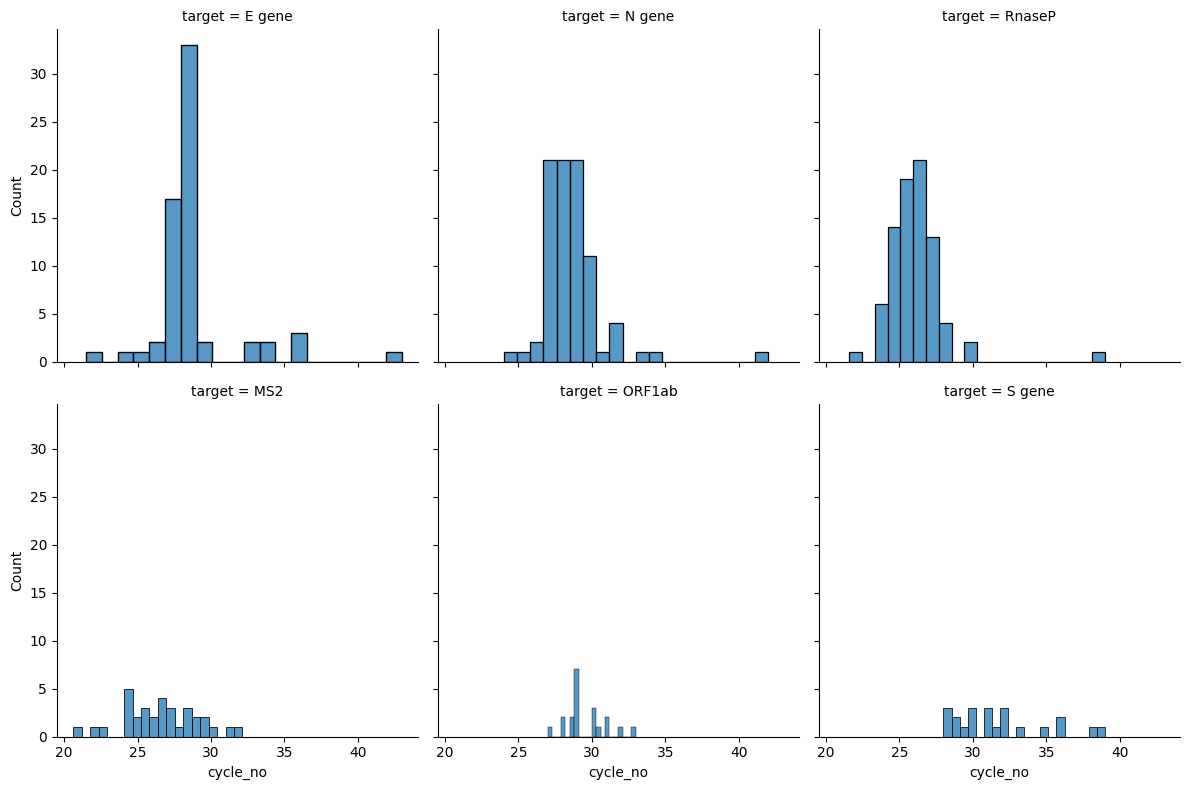

In [44]:
df = new_thres_df.groupby(['pcr_plate','target'])['cycle_no'].mean().reset_index()
g = sns.FacetGrid(df, col='target', col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x='cycle_no', bins=20)

#### systematically shift the Fn threshold and Ct

In [44]:
avg_threshold_df = full_test_pred.groupby(['target','pcr_plate']).threshold.mean().reset_index()
max_drn_df = full_test_pred.groupby(['target','pcr_plate']).drn.max().reset_index()

df = avg_threshold_df.merge(max_drn_df, on=['target','pcr_plate'])
df['ratio'] = df.threshold/df.drn

In [45]:
cycle_range_dict = {'LuNER':{'other': np.arange(20,45),
                            #  'E gene': np.concatenate([np.arange(35,40), np.arange(41,46)]),
                             'RnaseP': np.arange(20,45)},
                    'Thermo': np.arange(20,45)}
                    
fn_range = np.arange(-.99, 4, 0.01)

In [ ]:

for perc in fn_range:
    for cycle in range(-5,6):
        df = full_test_pred.copy()
        df['cq_new'] = df['cq_new'].fillna(20)
        df['new_threshold'] = full_test_pred.threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        # df['new_ct'] = np.Inf
        pass_ct = df[(df.if_pass)& (df.cycle_no >= 20)].groupby('curve_idx').cycle_no.apply(lambda x: np.floor(np.min(x))).reset_index()
        pass_ct.columns = ['curve_idx', 'new_ct']
        df = (df.merge(pass_ct, how='left', on='curve_idx'))
        df['new_ct'] = df['new_ct'].fillna(np.Inf)
        fake_df = df[(df.cycle_no >= df.new_ct)].sort_values(['curve_idx','cycle_no']).groupby('curve_idx').tail(5).groupby('curve_idx').if_pass.apply('all').reset_index()
        fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()
        
        df['new_igi_call'] = 1*((df.new_ct <= df.cq_new.astype(float) + cycle)) #& (df.new_ct >= df.baseline_end))
        df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0
        # if df.test_kit.iloc[0] == 'Thermo':
        # df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        # df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        # df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        thres_df['fpr'].append(fp/(fp+tn))
        thres_df['fnr'].append(fn/(fn+tp))
        thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        thres_df['perc'].append(perc)
        thres_df['cycle'].append(cycle)
        
        

In [46]:
final_thres_df_1 = pd.read_csv('final_thres_df_new.csv')
final_thres_df_2 = pd.read_csv('final_thres_df_new_1.csv')
final_thres_df_3 = pd.read_csv('final_thres_df_new_2.csv')
final_thres_df_4 = pd.read_csv('final_thres_df_new_3.csv')
final_thres_df_5 = pd.read_csv('final_thres_df_new_4.csv')
final_thres_df_6 = pd.read_csv('final_thres_df_new_5.csv')
final_thres_df_7 = pd.read_csv('final_thres_df_new_nofakeids.csv')

final_thres_df = pd.concat([final_thres_df_1, final_thres_df_2, 
                            final_thres_df_3, 
                            final_thres_df_4, 
                            final_thres_df_5,
                            final_thres_df_6,
                            final_thres_df_7,
                            ], ignore_index=True)

# final_thres_df = pd.read_csv('final_thres_df_new_nofakeids.csv')
final_thres_df['tpr'] = 1 - final_thres_df['fnr']
print('Total number of simulations:', final_thres_df.shape[0])

Total number of simulations: 921760


In [47]:
check_df = final_thres_df.groupby('pos_pred').perc.max().reset_index()
check_df[check_df.perc < 0]

,pos_pred,perc
5286,0.868430,-0.024
5287,0.868594,-0.045
5288,0.868758,-0.048
5289,0.868922,-0.088
5290,0.869087,-0.096
...,...,...
6083,0.999343,-1.006
6084,0.999507,-1.034
6085,0.999671,-1.108
6086,0.999836,-1.152


In [ ]:
# simulate with Fn thresholds and cycle for each pcr_plate
smallest_fpr = pd.DataFrame()
smallest_fnr = pd.DataFrame()
fn_range = np.arange(-.99, 4, 0.05)
for pcr_plate in full_test_pred.pcr_plate.unique():
    plate_thres_df = {'pcr_plate':[], 'fpr':[], 'fnr':[], 'pos_pred': [], 'cycle':[], 'perc':[]}
    for perc in fn_range:
        for cycle in range(-1,2):
            df = full_test_pred[full_test_pred.pcr_plate == pcr_plate].copy()
            df['new_threshold'] = df.threshold * (1 + perc)

            df['if_pass'] = df.drn >= df.new_threshold

            pass_ct = df[(df.if_pass)& (df.cycle_no >= 20)] \
                .groupby('curve_idx').cycle_no.min().reset_index()
            pass_ct.columns = ['curve_idx', 'new_ct']
            df = df.merge(pass_ct, how='left', on='curve_idx')
            df['new_ct'] = df['new_ct'].fillna(np.Inf)

            fake_df = df[(df.cycle_no >= df.new_ct)] \
                .sort_values(['curve_idx','cycle_no']) \
                .groupby('curve_idx').tail(5) \
                .groupby('curve_idx').if_pass.all().reset_index()
            fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

            df['new_igi_call'] = 1*((df.new_ct <= df.cq_new.astype(float) + cycle))
            df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0

            df_1 = df[df.cycle_no == 1]
            tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()

            
            plate_thres_df['fpr'].append(fp/(fp+tn))
            plate_thres_df['fnr'].append(fn/(fn+tp))
            plate_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
            plate_thres_df['pcr_plate'].append(pcr_plate)
            plate_thres_df['cycle'].append(cycle)
            plate_thres_df['perc'].append(perc)
            
    plate_thres_df = pd.DataFrame(plate_thres_df)
    smallest_fpr = pd.concat([smallest_fpr, plate_thres_df.sort_values(['fpr','fnr']).head(1)])
    smallest_fnr = pd.concat([smallest_fnr, plate_thres_df.sort_values(['fnr','fpr']).head(1)])
            
            

In [48]:
smallest_fnr = pd.read_csv('smallest_fnr_test_1.csv')
smallest_fpr = pd.read_csv('smallest_fpr_test_1.csv')

In [49]:

df = full_test_pred.copy()
df = df.merge(smallest_fnr[['pcr_plate','perc','cycle']], on=['pcr_plate'])
df['new_threshold'] = df.threshold * (1 + df.perc)

df['if_pass'] = df.drn >= df.new_threshold
passed_ids = df[df.if_pass].curve_idx.unique()
# df['new_ct'] = np.Inf
pass_ct = df[(df.if_pass)& (df.cycle_no >= 20)].groupby('curve_idx').cycle_no.apply(lambda x: np.floor(np.min(x))).reset_index()
pass_ct.columns = ['curve_idx', 'new_ct']
df = (df.merge(pass_ct, how='left', on='curve_idx'))
df['new_ct'] = df['new_ct'].fillna(np.Inf)
fake_df = df[(df.cycle_no >= df.new_ct)].sort_values(['curve_idx','cycle_no']).groupby('curve_idx').tail(5).groupby('curve_idx').if_pass.apply('all').reset_index()
fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

df['new_igi_call'] = 1*((df.new_ct <= (df.cq_new.astype(float) + df.cycle))) #& (df.new_ct >= df.baseline_end))
df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0
# if df.test_kit.iloc[0] == 'Thermo':
# df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])

# df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
# df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])

df_1 = df[df.cycle_no == 1]
tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
print('Smallest FNR:', fn/(fn+tp))
print(f'Corresponding FPR {fp/(fp+tn)}, pos frac: {(fp+tp)/(fp+tp+tn+fn)}')

Smallest FNR: 0.043684883933467374
Corresponding FPR 0.019448946515397084, pos frac: 0.8613666228646518


In [50]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fnr = igi_fn/(igi_fn+igi_tp) 
igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
igi_fpr = igi_fp/(igi_fp + igi_tn)
print('Current IGI FNR:', igi_fnr)
print('Current IGI FPR:', igi_fpr)
print('Current IGI positive fraction:', igi_pos_frac)

Current IGI FNR: 0.043502101992323156
Current IGI FPR: 0.0
Current IGI positive fraction: 0.8595597897503285


In [51]:
print(f'With the same true pos fraction - {true_pos_frac}, our model performance vs best achievable static threshold')
print(model_dict_df[model_dict_df.pos_frac == true_pos_frac].head(1))
print(final_thres_df[(final_thres_df.pos_pred <= (true_pos_frac + 0.004)) & (final_thres_df.pos_pred >= (true_pos_frac - 0.004))].head(1))

With the same true pos fraction - 0.8986530880420499, our model performance vs best achievable static threshold
     thres       acc       fnr       fpr  pos_frac
541  0.541  0.986202  0.007677  0.068071  0.898653
        fpr       fnr  pos_pred   perc  cycle   fpr_type   fnr_type       tpr
8  0.222042  0.028697  0.895368 -0.999     -2  simulated  simulated  0.971303


In [52]:
prevalence = test_pred[test_pred.groundtruth_label == 1].shape[0]/test_pred.shape[0]
final_thres_df['accuracy'] = (prevalence*(1-final_thres_df.fnr) + (1 - prevalence)*(1-final_thres_df.fpr))
best_achievable_best_acc_idx = final_thres_df.accuracy.idxmax()
bestacchieve_bestacc_posfrac = final_thres_df.loc[best_achievable_best_acc_idx, 'pos_pred']
bestacchieve_bestacc_fnr = final_thres_df.loc[best_achievable_best_acc_idx, 'fnr']
bestacchieve_bestacc_fpr = final_thres_df.loc[best_achievable_best_acc_idx, 'fpr']
print('best achievable threshold rule positive prediction fraction on Test:', bestacchieve_bestacc_posfrac)
print('best achievable threshold rule Best Accuracy on Test:', final_thres_df.loc[best_achievable_best_acc_idx, 'accuracy'])
print('best achievable threshold rule Best accuracy FNR on Test:', final_thres_df.loc[best_achievable_best_acc_idx, 'fnr'])
print('best achievable threshold rule Best accuracy FPR on Test:', final_thres_df.loc[best_achievable_best_acc_idx, 'fpr'])

best achievable threshold rule positive prediction fraction on Test: 0.8745072273324573
best achievable threshold rule Best Accuracy on Test: 0.9689553219448094
best achievable threshold rule Best accuracy FNR on Test: 0.0307073661122281
best achievable threshold rule Best accuracy FPR on Test: 0.0340356564019448


With the same true pos fraction - 0.8986530880420499, our model performance vs best achievable static threshold


Text(0, 0.5, 'SPARK')

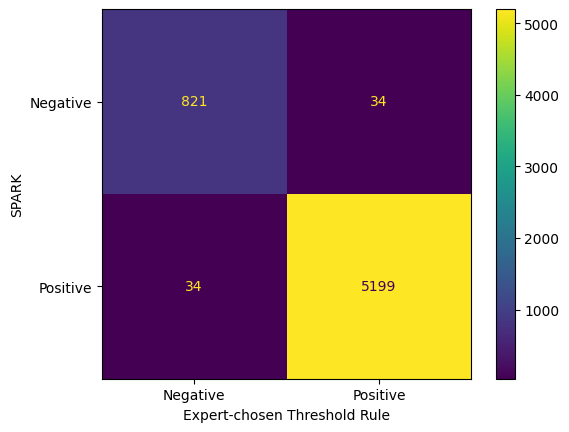

In [53]:
print(f'With the same true pos fraction - {true_pos_frac}, our model performance vs best achievable static threshold')
igi_posfrac_threshold = model_dict_df[model_dict_df.pos_frac == igi_pos_frac].head(1).thres.values[0]
test_pred['pred'] = 1*(test_pred.outputs >= igi_posfrac_threshold)
ConfusionMatrixDisplay(confusion_matrix(test_pred.pred, test_pred.encoded_igi_call, 
                                        labels=np.array([0,1])),
                       display_labels=['Negative','Positive']).plot()
plt.xlabel('Expert-chosen Threshold Rule')
plt.ylabel('SPARK')

In [54]:
print('IGI: positive - SPARK: positive')
print(test_pred[(test_pred.encoded_igi_call == 1) & (test_pred.pred == 1) & (test_pred.groundtruth == 1)].shape[0] / test_pred[(test_pred.encoded_igi_call == 1) & (test_pred.pred == 1)].shape[0])
print('IGI: negative - SPARK: positive')
print(test_pred[(test_pred.encoded_igi_call == 0) & (test_pred.pred == 1) & (test_pred.groundtruth == 1)].shape[0] / test_pred[(test_pred.encoded_igi_call == 0) & (test_pred.pred == 1)].shape[0])
print('IGI: negative - SPARK: negative')
print(test_pred[(test_pred.encoded_igi_call == 0) & (test_pred.pred == 0) & (test_pred.groundtruth == 1)].shape[0] / test_pred[(test_pred.encoded_igi_call == 0) & (test_pred.pred == 0)].shape[0])
print('IGI: positive - SPARK: negative')
print(test_pred[(test_pred.encoded_igi_call == 1) & (test_pred.pred == 0) & (test_pred.groundtruth == 1)].shape[0] / test_pred[(test_pred.encoded_igi_call == 1) & (test_pred.pred == 0)].shape[0])


IGI: positive - SPARK: positive
1.0
IGI: negative - SPARK: positive
0.9705882352941176
IGI: negative - SPARK: negative
0.2496954933008526
IGI: positive - SPARK: negative
1.0


In [59]:
linestyle_map = {'fusion': 'dashed',
                 'qpcr': (5,(10,3)),
                 'deepnet': 'dotted',
                 'achievable': (0,(3,1,1,1))}
color_map = {'igi': 'mediumorchid', #'#008080',
             'fusion': '#ffa500',
             'qpcr':'#00ff00',
             'deepnet': '#0000ff',
             'humanbased': '#ff1493'
             }
# beach
color_map = {'igi': '#ffeead', #'#008080',
             'fusion': '#ffcc5c',
             'qpcr':'#ff6f69',
             'deepnet': '#96ceb4',
             'humanbased': '#88d8b0'
             }
# # pastel rainbow
# color_map = {'igi': '#a8e6cf', #'#008080',
#              'fusion': '#dcedc1',
#              'qpcr':'#ffd3b6',
#              'deepnet': '#ffaaa5',
#              'humanbased': '#ff1493'
#              }

# summertime 3
color_map = {'igi': '#0b4479', #'#008080',
             'fusion': '#ffbe4f',
             'qpcr':'#6bd2db',
             'deepnet': '#0ea7b5',
             'humanbased': '#ff1493',
             'achievable': '#4682b4'
             }
# # city sunset
# color_map = {'igi': '#eeaf61', #'#008080',
#              'fusion': '#fb9062',
#              'qpcr':'#ee5d6c',
#              'deepnet': '#ce4993',
#              'humanbased': '#6a0d83'
#              }


In [56]:
model_dict_df[(model_dict_df.fnr <= .0101) * (model_dict_df.fnr >= 0.0099)].sort_values('fnr')

,thres,acc,fnr,fpr,pos_frac
659,0.659,0.986531,0.010053,0.04376,0.894054
660,0.660,0.986531,0.010053,0.04376,0.894054


In [60]:
best_achievable_roc = final_thres_df.groupby('fpr').tpr.max().reset_index()
# df = pd.DataFrame({'fpr': [0]*len})
# best_achievable_roc.loc[best_achievable_roc.shape[0]] = [0, 0.8]

/tmp/ipykernel_2578653/1990968475.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


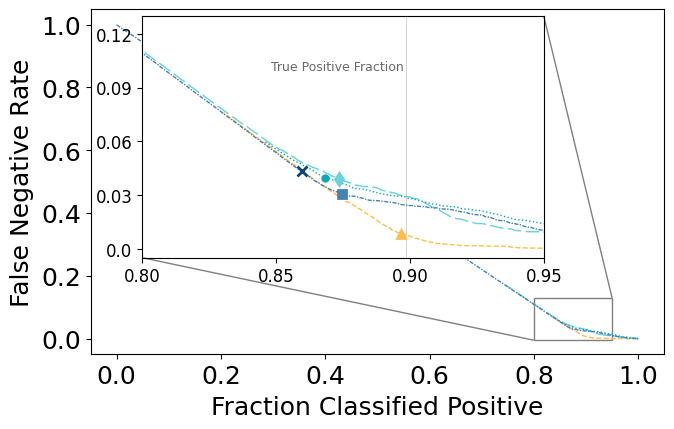

In [61]:
from matplotlib.gridspec import GridSpec

final_thres_df['pos_pred'] = final_thres_df['pos_pred'].round(3)
fnr_df = final_thres_df.groupby('pos_pred').fnr.min().reset_index().sort_values('pos_pred')
test_pred['pred'] = 1*(test_pred.outputs >= best_acc_threshold)
bestacc_pos_pred = test_pred.pred.sum()/test_pred.shape[0]
tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
bestacc_fnr = fn/(fn+tp) 
pos_frac = (fp + tp)/(fp+tp+fn+tn)
bestacc_fpr = fp/(fp + tn)
bestacc_tpr = tp/(tp + fn)

fig = plt.figure(figsize=(7,8))
# plt.rcParams.update({'font.size': 18})
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio


# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
# ax1.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
ax1.plot(model_dict_df.pos_frac, model_dict_df.fnr, 
         linewidth=1, color=color_map.get('fusion'), 
         linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fnr, 
         linewidth=1, color=color_map.get('qpcr'), 
         linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fnr, 
         linewidth=1, color=color_map.get('deepnet'), 
         linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(fnr_df.pos_pred, 
         fnr_df.fnr, color=color_map.get('achievable'), 
         linewidth=1, linestyle=linestyle_map.get('achievable'), 
         label='Best achievable threshold rule')
# ax1.plot(igi_pos_frac, igi_fnr, 'x', color='#0c457d', **{'ms':5,'mew':1}, label='Implemented threshold rule')
# ax1.plot(bestacc_pos_pred, bestacc_fnr, '^', color=color_map.get('fusion'), **{'ms':5,'mew':1}, label='SPARK best accuracy')
# ax1.plot(deepnet_best_acc_posfrac, deepnet_best_acc_fnr, '.', color=color_map.get('deepnet'), **{'ms':5,'mew':1}, label='qPCRdeepNet best accuracy')
# ax1.plot(qpcr_best_acc_posfrac, qpcr_best_acc_fnr, '*', color=color_map.get('qpcr'), **{'ms':5,'mew':1}, label='qpcR best accuracy')
# ax1.plot(bestacchieve_bestacc_posfrac, bestacchieve_bestacc_fnr, 's', color=color_map.get('igi'), **{'ms':5,'mew':1}, label='Best achievable threshold rule best accuracy')

# ax1.text(x=0.61, y = 0.99, s='True positive fraction', c='dimgray', fontsize=9.7)
ax1.set_xlabel('Fraction Classified Positive',fontsize=18, labelpad=5)
ax1.set_ylabel('False Negative Rate', fontsize=18, labelpad=5)
ax1.set_position([0., 0., 1., 1], which='both')
# ax1.tick_params(axis='x', labeltop=True, top=True, labelsize=18)   # Show ticks & labels on top
# ax1.tick_params(axis='x', labelbottom=False, bottom=False)  # Optional: Hide bottom labels
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# inset
axins = inset_axes(ax1, width="70%", height="70%", 
                bbox_to_anchor=(-0.06, 0.13, 1, 1),
                   bbox_transform=ax1.transAxes, 
                   loc="center")
# Connect inset to the main plot
mark_inset(ax1, axins, loc1=1, loc2=3, fc="none", ec="0.5")

axins.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
axins.plot(model_dict_df.pos_frac, model_dict_df.fnr, 
           linewidth=1, color=color_map.get('fusion'), 
           linestyle=linestyle_map.get('fusion'), label='SPARK')
axins.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fnr, 
           linewidth=1, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
axins.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fnr, 
           linewidth=1, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
axins.plot(fnr_df.pos_pred, 
         fnr_df.fnr, color=color_map.get('achievable'), 
         linewidth=1, 
         linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
axins.plot(igi_pos_frac, igi_fnr, 'x', color=color_map.get('igi'), 
           **{'ms':7,'mew':2}, label='Implemented threshold rule')
axins.plot(bestacc_pos_pred, bestacc_fnr, '^', color=color_map.get('fusion'), 
           **{'ms':6,'mew':2}, label='Smallest Possible Threshold-based FPR')
axins.plot(deepnet_best_acc_posfrac, deepnet_best_acc_fnr, '.', color=color_map.get('deepnet'), **{'ms':8,'mew':2}, label='qPCRdeepNet best accuracy')
axins.plot(qpcr_best_acc_posfrac, qpcr_best_acc_fnr, 'd', color=color_map.get('qpcr'), 
           **{'ms':6,'mew':2}, label='qpcR best accuracy')
axins.plot(bestacchieve_bestacc_posfrac, bestacchieve_bestacc_fnr, 's', color=color_map.get('achievable'), 
           **{'ms':6,'mew':2}, label='Best achievable threshold rule best accuracy')

axins.text(x=0.848, y = 0.1, s='True Positive Fraction', c='dimgray', fontsize=9)

axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
               labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
axins.set_ylim(-0.005, 0.13)
axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
               labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
axins.set_xlim(0.8, 0.95)
axins.set_position([0., 0., 1., 1], which='both')



plt.subplots_adjust(hspace=0.25)
plt.tight_layout()

## False positive rate

/tmp/ipykernel_2578653/3959544745.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


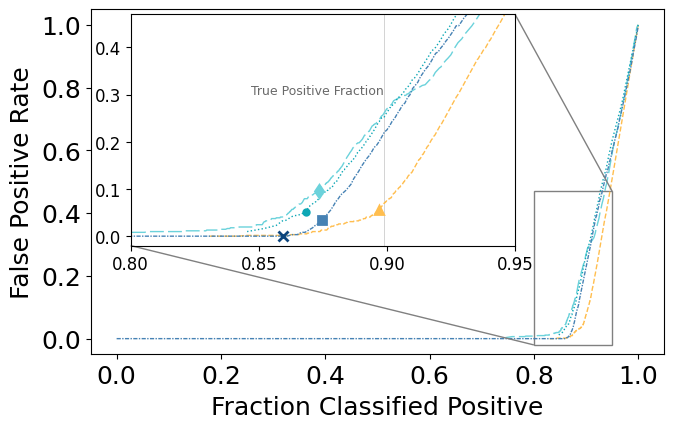

In [62]:
from matplotlib.gridspec import GridSpec

fpr_df = final_thres_df.groupby('pos_pred').fpr.min().reset_index().sort_values('pos_pred')

fig = plt.figure(figsize=(7,8))
# plt.rcParams.update({'font.size': 18})
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio


# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
# ax1.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
ax1.plot(model_dict_df.pos_frac, model_dict_df.fpr, 
         linewidth=1, color=color_map.get('fusion'), 
         linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, 
         linewidth=1, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, 
         linewidth=1, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(fpr_df.pos_pred, 
         fpr_df.fpr, 
         linewidth=1, color=color_map.get('achievable'), 
         linestyle=linestyle_map.get('achievable'),
         label='Best achievable threshold rule')
# ax1.plot(igi_pos_frac, igi_fpr, 'x', color='#0c457d', **{'ms':7,'mew':1}, label='Implemented threshold rule')
# ax1.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), **{'ms':8,'mew':1}, label='Smallest Possible Threshold-based FPR')

# ax1.text(x=0.61, y = 1, s='True positive fraction', c='dimgray', fontsize=9.7)
ax1.set_xlabel('Fraction Classified Positive',fontsize=18, labelpad=5)
ax1.set_ylabel('False Positive Rate', fontsize=18, labelpad=5)
ax1.set_position([0., 0., 1., 1], which='both')
# ax1.tick_params(axis='x', labeltop=True, top=True, labelsize=18)   # Show ticks & labels on top
# ax1.tick_params(axis='x', labelbottom=False, bottom=False)  # Optional: Hide bottom labels
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# inset
axins = inset_axes(ax1, width="67%", height="67%", 
                bbox_to_anchor=(-0.095, 0.15, 1, 1),
                   bbox_transform=ax1.transAxes, 
                   loc="center")
# Connect inset to the main plot
mark_inset(ax1, axins, loc1=1, loc2=3, fc="none", ec="0.5")

axins.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
axins.plot(model_dict_df.pos_frac, model_dict_df.fpr, 
           linewidth=1, color=color_map.get('fusion'), 
           linestyle=linestyle_map.get('fusion'), label='SPARK')
axins.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, 
           linewidth=1, color=color_map.get('qpcr'), 
           linestyle=linestyle_map.get('qpcr'), label='qpcR')
axins.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, 
           linewidth=1, color=color_map.get('deepnet'), 
           linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
axins.plot(fpr_df.pos_pred, 
         fpr_df.fpr, color=color_map.get('achievable'), 
         linewidth=1,
         linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
axins.plot(igi_pos_frac, igi_fpr, 'x', color='#0c457d', 
           **{'ms':7,'mew':2}, label='Implemented threshold rule')
axins.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), 
           **{'ms':6,'mew':2}, label='Smallest Possible Threshold-based FPR')
axins.plot(deepnet_best_acc_posfrac, deepnet_best_acc_fpr, '.', color=color_map.get('deepnet'), **{'ms':8,'mew':2}, label='qPCRdeepNet best accuracy')
axins.plot(qpcr_best_acc_posfrac, qpcr_best_acc_fpr, 'd', color=color_map.get('qpcr'), 
           **{'ms':6,'mew':2}, label='qpcR best accuracy')
axins.plot(bestacchieve_bestacc_posfrac, bestacchieve_bestacc_fpr, 's', color=color_map.get('achievable'), 
           **{'ms':6,'mew':2}, label='Best achievable threshold rule best accuracy')

axins.text(x=0.847, y = 0.3, s='True Positive Fraction', c='dimgray', fontsize=9)

# axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
#                labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
axins.set_ylim(-0.02, 0.47)
axins.tick_params(axis='y', labelsize=12)
axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
               labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
axins.set_xlim(0.8, 0.95)
axins.set_position([0., 0., 1., 1], which='both')

plt.subplots_adjust(hspace=0.25)
plt.tight_layout()

/tmp/ipykernel_2578653/91700556.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


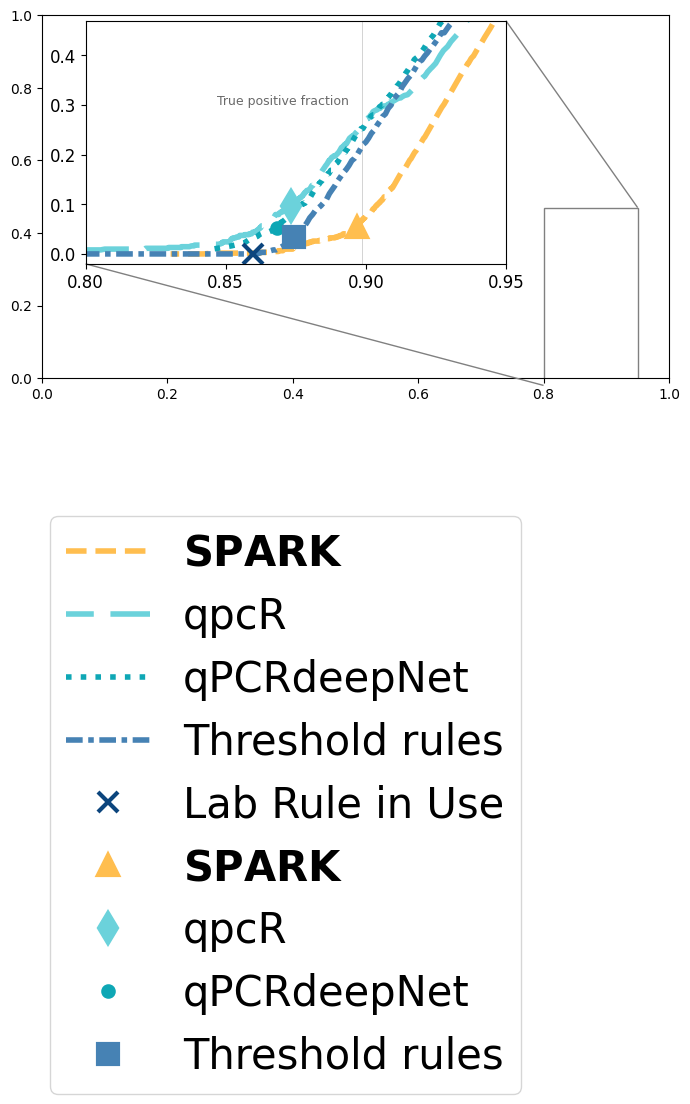

In [63]:
from matplotlib.gridspec import GridSpec

fpr_df = final_thres_df.groupby('pos_pred').fpr.min().reset_index()

fig = plt.figure(figsize=(7,8))
# plt.rcParams.update({'font.size': 18})
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio


# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
# ax1.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
# ax1.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), linewidth=2, label='SPARK')
# ax1.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), linewidth=2, label='qpcR')
# ax1.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), linewidth=2, label='qPCRdeepNet')
# ax1.plot(fpr_df.pos_pred, 
#          fpr_df.fpr, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'), linewidth=2, label='Best achievable threshold rule')
# ax1.set_xlabel('Fraction of predicted positive labels',fontsize=18, labelpad=5)
# ax1.set_ylabel('False Positive Rate', fontsize=18, labelpad=5)
# ax1.set_position([0., 0., 1., 1], which='both')
# ax1.tick_params(axis='y', labelsize=18)

# inset
axins = inset_axes(ax1, width="67%", height="67%", 
                bbox_to_anchor=(-0.095, 0.15, 1, 1),
                   bbox_transform=ax1.transAxes, 
                   loc="center")
# Connect inset to the main plot
mark_inset(ax1, axins, loc1=1, loc2=3, fc="none", ec="0.5")

axins.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
axins.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), linewidth=4, label=r'$\bf{SPARK}$')
axins.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), linewidth=4, label='qpcR')
axins.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), linewidth=4, label='qPCRdeepNet')
axins.plot(fpr_df.pos_pred, 
         fpr_df.fpr, color=color_map.get('achievable'), 
         linestyle=linestyle_map.get('achievable'), linewidth=4, label='Threshold rules')

axins.plot(igi_pos_frac, igi_fpr, 'x', color='#0c457d', 
           **{'ms':15,'mew':3}, label='Lab Rule in Use')
axins.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), 
           **{'ms':15,'mew':3}, label=r'$\bf{SPARK}$')
axins.plot(qpcr_best_acc_posfrac, qpcr_best_acc_fpr, 'd', color=color_map.get('qpcr'), 
           **{'ms':15,'mew':3}, label='qpcR')
axins.plot(deepnet_best_acc_posfrac, deepnet_best_acc_fpr, '.', color=color_map.get('deepnet'), **{'ms':15,'mew':3}, label='qPCRdeepNet')

axins.plot(bestacchieve_bestacc_posfrac, bestacchieve_bestacc_fpr, 's', color=color_map.get('achievable'), 
           **{'ms':15,'mew':3}, label='Threshold rules')

axins.text(x=0.847, y = 0.3, s='True positive fraction', c='dimgray', fontsize=9)

# axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
#                labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
axins.set_ylim(-0.02, 0.47)
axins.tick_params(axis='y', labelsize=12)
axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
               labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
axins.set_xlim(0.8, 0.95)
axins.set_position([0., 0., 1., 1], which='both')

plt.subplots_adjust(hspace=0.25)
# Suppose you want A first, then C, then B
# Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# desired_order = ['SPARK', 'qpcR','qPCRdeepNet']
# order = {label: i for i, label in enumerate(desired_order)}
# sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: order[x[0]])
# sorted_labels, sorted_handles = zip(*sorted_handles_labels)

# plt.legend(sorted_handles, sorted_labels)

plt.legend(loc='lower center', fontsize=30, ncol = 1, bbox_to_anchor=(0.475,-3.5))
plt.tight_layout()

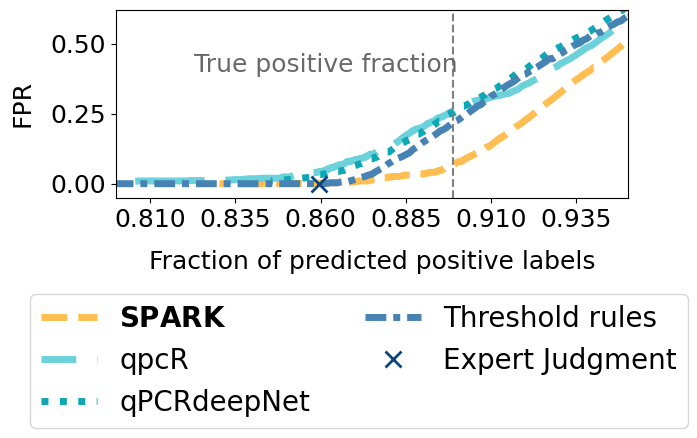

In [62]:
from matplotlib.gridspec import GridSpec

fpr_df = final_thres_df.groupby('pos_pred').fpr.min().reset_index()

fig = plt.figure(figsize=(7,8))
plt.rcParams.update({'font.size': 18})
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio

# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), linewidth = 5, label=r'$\bf{SPARK}$')
ax1.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), linewidth = 5, label='qpcR')
ax1.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), linewidth = 5, label='qPCRdeepNet')
ax1.plot(fpr_df.pos_pred, 
         fpr_df.fpr, color=color_map.get('achievable'), linestyle=linestyle_map.get('achievable'), linewidth = 5, label='Threshold rules')
ax1.plot(igi_pos_frac, igi_fpr, 'x', color='#0c457d', **{'ms':12,'mew':2}, label='Expert Judgment')
# ax1.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), **{'ms':12,'mew':2}, label='SPARK best accuracy') # Smallest Possible Threshold-based FPR
# ax1.plot(expert_pos_pred, expert_fpr, 'o', color='orange', **{'ms':12,'mew':2}, label='Smallest Possible Threshold-based FPR')
# zoom_region = Rectangle((0.855, 0.005), 0.047, 0.05, edgecolor="0.5", facecolor="none", linewidth=.7)
# ax1.add_patch(zoom_region)
ax1.axvline(true_pos_frac, linestyle='--', color='gray')
ax1.text(x=0.823, y = 0.4, s='True positive fraction', c='dimgray', fontsize=18)
ax1.set_xlabel('Fraction of predicted positive labels',fontsize=18, labelpad=13)
ax1.set_ylabel('FPR', fontsize=18, labelpad=12)
ax1.set_xticks(ticks=np.arange(0.81, 0.95, 0.025), 
               labels=['0.810','0.835','0.860', '0.885','0.910','0.935'], fontsize=18)
ax1.set_ylim(-0.05, 0.62)
ax1.set_xlim(0.80, 0.95)
ax1.set_position([0., 0., 1., 1], which='both')
# ax1.set_title('Using IGI threshold')
# Bottom plot (smaller)
# zoom_ax = fig.add_subplot(gs[1, 0])
# zoom_ax.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), label='SPARK')
# zoom_ax.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')

# zoom_ax.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
# zoom_ax.plot(fpr_df.pos_pred, 
#          fpr_df.fpr, color=color_map.get('igi'), linestyle=linestyle_map.get('igi'), label='Best achievable threshold rule')
# zoom_ax.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':12,'mew':2}, label='Implemented threshold rule')
# zoom_ax.axvline(true_pos_frac, linestyle='--', color='gray')
# zoom_ax.text(x=0.887, y = 0.045, s='True positive fraction', c='dimgray', fontsize=18)
# zoom_ax.yaxis.tick_right()         # Moves ticks to the right
# zoom_ax.yaxis.set_label_position("right")
# zoom_ax.grid(color='gainsboro')
# zoom_ax.grid(axis='y', linestyle='--', color='silver', alpha=0.7)

# zoom_ax.set_xlim(0.845, 0.902)
# zoom_ax.set_ylim(0.0, 0.058)
# zoom_ax.set_title('Zoomed in')
# zoom_ax.set_xlabel('Fraction of predicted positive labels', fontsize=20)
# zoom_ax.set_ylabel('FNR', fontsize=20)
plt.legend(loc='lower center', fontsize=20, ncol = 2, bbox_to_anchor=(0.475,-1.3))
plt.subplots_adjust(hspace=0.25)
# ax.grid(color='gainsboro')
plt.tight_layout()

In [63]:
df_1 = full_test_pred[full_test_pred.cycle_no == 1].copy()
final_metrics = final_thres_df.groupby('fpr').fnr.min().reset_index()
final_metrics['tpr'] = 1 - final_metrics.fnr
# final_metrics.loc[0,['fpr','tpr']] = [0, 0]
# final_metrics.loc[len(final_metrics),['fpr','tpr']] = [1, 1]
final_metrics.sort_values(['fpr','tpr'], inplace=True)
final_metrics['tp'] = final_metrics['tpr']*sum(df_1.groundtruth_label)
final_metrics['fn'] = sum(df_1.groundtruth_label) - final_metrics['tp']
final_metrics['fp'] = final_metrics['fpr']*sum(df_1.groundtruth_label == 0)
final_metrics['tn'] = sum(df_1.groundtruth_label == 0) - final_metrics['fp']

SPARK AUC: 0.9978643840944754
IGI AUC: 0.9782489490038384
qpcR AUC: 0.9816603354596669
deepnet AUC: 0.980412115509892
Best achievable AUC: 0.9754133108504635


/tmp/ipykernel_1308378/3610587765.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


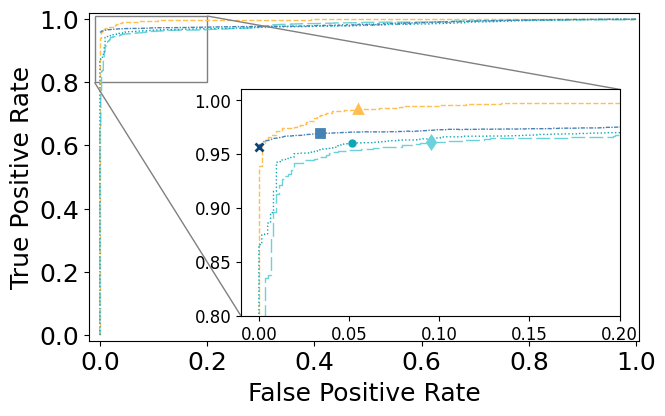

In [64]:


# Example data
fpr1, tpr1, _ = roc_curve(test_pred.groundtruth_label, test_pred.outputs)
fpr2, tpr2, _ = roc_curve(test_pred.groundtruth_label, test_pred.encoded_igi_call)
fpr3, tpr3, _ = roc_curve(qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label, qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob)
fpr4, tpr4, _ = roc_curve(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.prob)

auc1 = auc(fpr1, tpr1)
print(f'SPARK AUC: {auc1}')
auc2 = auc(fpr2, tpr2)
print(f'IGI AUC: {auc2}')
auc3 = auc(fpr3, tpr3)
print(f'qpcR AUC: {auc3}')
auc4 = auc(fpr4, tpr4)
print(f'deepnet AUC: {auc4}')

fpr = final_thres_df['fpr'].values
fpr = np.insert(fpr, [0, 1], [0, 1])
tpr = final_thres_df['tpr'].values
tpr = np.insert(tpr, [0, 1], [0, 1])

# Make sure fpr is sorted in ascending order
sorted_idx = fpr.argsort()
fpr = fpr[sorted_idx]
tpr = tpr[sorted_idx]

# Calculate AUC
roc_auc = auc(fpr, tpr)
print('Best achievable AUC:', roc_auc)

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fpr1, tpr1, label=f'SPARK (AUC = {auc1:.2f})', 
        linewidth=1, linestyle=linestyle_map.get('fusion'), color=color_map.get('fusion'))
# ax.plot(fpr2, tpr2, label=f'Expert Judgement (AUC = {auc2:.2f})', linestyle=linestyle_map.get('igi'), color=color_map.get('igi'))
ax.plot(fpr3, tpr3, label=f'qpcR (AUC = {auc3:.2f})', 
        linewidth=1, linestyle=linestyle_map.get('qpcr'), color=color_map.get('qpcr'))
ax.plot(fpr4, tpr4, label=f'qPCRdeepNet (AUC = {auc4:.2f})', 
        linewidth=1, linestyle=linestyle_map.get('deepnet'), color=color_map.get('deepnet'))
ax.plot(final_metrics.fpr, final_metrics.tpr, label=f'Best achievable threshold rule (AUC = {roc_auc:.2f})', 
        linewidth=1, linestyle=linestyle_map.get('achievable'), color=color_map.get('achievable'))
# ax.plot(bestacc_fpr, bestacc_tpr, '^', color=color_map.get('fusion'), **{'ms':10,'mew':1}, label='Smallest Possible Threshold-based FPR')
# ax.plot(test_igi_fpr, test_igi_tpr, 'x',**{'ms':10,'mew':1}, label=f'Expert Judgement (AUC = {auc2:.2f})', color='#0c457d', )
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
# Labels and legend
ax.set_xlabel('False Positive Rate', fontsize=18, labelpad=5)
ax.set_ylabel('True Positive Rate', fontsize=18)
# zoom_region = Rectangle((-0.01,0.8), 0.2 + 0.01, 1.01-0.8, edgecolor="0.5", facecolor="none", linewidth=.7)
# ax.add_patch(zoom_region)
# Create inset axes: position and size are relative to the main plot
axins = inset_axes(ax, width="65%", height="65%", 
                   bbox_to_anchor=(-0.095, 0.078, 1.06, 1.06),  # (x0, y0, width, height) in axes fraction
                   bbox_transform=ax.transAxes, 
                   loc="lower right", borderpad=0)
# Connect inset to the main plot
mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.5")

# # Plot the same data on inset
axins.plot(fpr1, tpr1, label=f'SPARK (AUC = {auc1:.2f})', linewidth=1, 
           linestyle=linestyle_map.get('fusion'), color=color_map.get('fusion'))
axins.plot(fpr3, tpr3, label=f'qpcR (AUC = {auc3:.2f})', linewidth=1, 
           linestyle=linestyle_map.get('qpcr'), color=color_map.get('qpcr'))
axins.plot(fpr4, tpr4, label=f'qPCRdeepNet (AUC = {auc4:.2f})', linewidth=1,  
           linestyle=linestyle_map.get('deepnet'), color=color_map.get('deepnet'))
axins.plot(final_metrics.fpr, final_metrics.tpr, label=f'Best achievable threshold rule (AUC = {roc_auc:.2f})', 
           linewidth=1, linestyle=linestyle_map.get('achievable'), color=color_map.get('achievable'))
axins.plot(fpr2, tpr2, 'x', color=color_map.get('igi'), 
           **{'ms':6,'mew':2}, label='Implemented threshold rule')
axins.plot(bestacc_fpr, 1 - bestacc_fnr, '^', color=color_map.get('fusion'), 
           **{'ms':6,'mew':2}, label='Smallest Possible Threshold-based FPR')
axins.plot(deepnet_best_acc_fpr, 1 - deepnet_best_acc_fnr, '.', color=color_map.get('deepnet'), **{'ms':8,'mew':2}, label='qPCRdeepNet best accuracy')
axins.plot(qpcr_best_acc_fpr, 1-qpcr_best_acc_fnr, 'd', color=color_map.get('qpcr'), 
           **{'ms':6,'mew':2}, label='qpcR best accuracy')
axins.plot(bestacchieve_bestacc_fpr, 1 - bestacchieve_bestacc_fnr, 's', color=color_map.get('achievable'), 
           **{'ms':6,'mew':2}, label='Best achievable threshold rule best accuracy')

axins.set_xlim([-0.01,0.2])
axins.set_ylim([0.8,1.01])
axins.tick_params(axis='x', labelsize=12)
axins.tick_params(axis='y', labelsize=12)
# axins.set_yticks(ticks=np.arange(0.8, 1.01, 0.05), 
#                labels=['0.80','0.85','0.90', '0.95','1.0'], fontsize=12)

# plt.title('ROC Curves for Multiple Models')
# plt.legend(loc='lower right', fontsize= 15)
ax.set_xlim([-0.02,1.005])
ax.set_ylim([-0.02,1.02])
plt.grid(False)
plt.tight_layout()
plt.show()


Spark aupcr: 0.9997621342373609
AUPRC for threshold rules: 0.9983864402986473
qpcr aupcr: 0.9979800264221274
deepnet aupcr: 0.9978929567868555


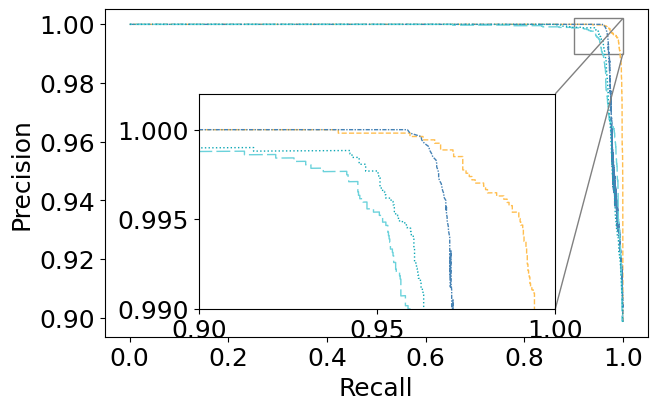

In [169]:

# Example: true labels and predicted scores
y_true = test_pred.groundtruth_label
y_scores =test_pred.outputs  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_spark, recall_spark, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_spark = average_precision_score(y_true, y_scores)
print('Spark aupcr:', auprc_spark)

# Compute the precision-recall pairs
precision_achievable = final_metrics['tp'] / (final_metrics['tp'] + final_metrics['fp'])
recall_achievable = final_metrics['tp']/ (final_metrics['tp'] + final_metrics['fn'])
sorted_indices = np.argsort(recall_achievable.values)
sorted_recalls = np.concatenate([[0], recall_achievable.values[sorted_indices]])
sorted_precisions = np.concatenate([[1], precision_achievable.values[sorted_indices]])
auprc_achievable = auc(sorted_recalls, sorted_precisions)
print('AUPRC for threshold rules:', auprc_achievable)


y_true = qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label
y_scores = qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_qpcr, recall_qpcr, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_qpcr = average_precision_score(y_true, y_scores)
print('qpcr aupcr:', auprc_qpcr)


y_true = test_qpcrdeepnet.groundtruth_target
y_scores = test_qpcrdeepnet.prob  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_deepnet, recall_deepnet, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_deepnet = average_precision_score(y_true, y_scores)
print('deepnet aupcr:', auprc_deepnet)

# Plot the curve
fig, ax = plt.subplots(figsize=(7,4.25))
ax.plot(recall_spark, precision_spark, label=r'$\bf{SPARK}$',
        linewidth=1, linestyle=linestyle_map.get('fusion'),
        color=color_map.get('fusion'))
ax.plot(sorted_recalls, sorted_precisions, label='Threshold rules',
        linewidth=1, linestyle=linestyle_map.get('achievable'),
        color=color_map.get('achievable'))
ax.plot(recall_qpcr, precision_qpcr, label='qpcR',
        linewidth=1, linestyle=linestyle_map.get('qpcr'),
        color=color_map.get('qpcr'))
ax.plot(recall_deepnet, precision_deepnet, label='qPCRdeepNet',
        linewidth=1, linestyle=linestyle_map.get('deepnet'),
        color=color_map.get('deepnet'))
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

axins = inset_axes(ax, width="62%", height="62%", 
                   bbox_to_anchor=(-0.23, 0.085, 1.06, 1.06),  # (x0, y0, width, height) in axes fraction
                   bbox_transform=ax.transAxes, 
                   loc="lower right", borderpad=0)
mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.5")
axins.plot(recall_spark, precision_spark, label=r'$\bf{SPARK}$',
        linewidth=1, linestyle=linestyle_map.get('fusion'),
        color=color_map.get('fusion'))
axins.plot(sorted_recalls, sorted_precisions, label='Threshold rules',
        linewidth=1, linestyle=linestyle_map.get('achievable'),
        color=color_map.get('achievable'))
axins.plot(recall_qpcr, precision_qpcr, label='qpcR',
        linewidth=1, linestyle=linestyle_map.get('qpcr'),
        color=color_map.get('qpcr'))
axins.plot(recall_deepnet, precision_deepnet, label='qPCRdeepNet',
        linewidth=1, linestyle=linestyle_map.get('deepnet'),
        color=color_map.get('deepnet'))
axins.set_xlim([0.9,1.0])
axins.set_xticks(ticks = [0.9, 0.95, 1.])
axins.set_ylim([0.99,1.002])
axins.set_yticks(ticks = [0.99, 0.995, 1.])

ax.set_xlabel("Recall", fontsize=18)
ax.set_ylabel("Precision", fontsize=18)
# ax.set_title("Precision-Recall Curve", fontsize=18)
# ax.legend(loc='lower center', fontsize=20, ncol = 4, bbox_to_anchor=(0.475,-1.3))
plt.show()


### Test Brier Score

In [170]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(test_pred.groundtruth_label, test_pred.outputs)
print('Brier score for SPARK:', brier_score)

brier_score = brier_score_loss(test_pred.groundtruth_label, test_pred.encoded_igi_call)
print('Brier score for IGI:', brier_score)

brier_score = brier_score_loss(qpcr_test_pred.groundtruth_label, qpcr_test_pred.fillna(0).prob)
print('Brier score for qPCR:', brier_score)

brier_score = brier_score_loss(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.fillna(0).prob)
print('Brier score for qPCR:', brier_score)



Brier score for SPARK: 0.010382352636239715
Brier score for IGI: 0.039093298291721416
Brier score for qPCR: 0.03294465281186433
Brier score for qPCR: 0.040570140942672736


### water vs asymptotic samples

In [171]:
df = test_pred.merge(join_df.loc[join_df.cycle_no == 1, ['sample_type','target','curve_idx']], on='curve_idx')
water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
print('water samples:', len(water_df))
asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
print('Asymptotic samples:', len(asymptomatic_df))


water_df['pred'] = 1*(water_df.outputs >= best_acc_threshold)
asymptomatic_df['pred'] = 1*(asymptomatic_df.outputs >= best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(water_df.groundtruth_label, water_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'SPARK water Accuracy: {accuracy_score(water_df.groundtruth_label, water_df.pred)}')
# print(f'SPARK water AUC: {roc_auc_score(water_df.groundtruth_label, water_df.outputs)}')
print(f'SPARK water AUPRC: {average_precision_score(water_df.groundtruth_label, water_df.outputs)}')
print(f'SPARK water Brier score: {brier_score_loss(water_df.groundtruth_label, water_df.outputs)}')

water_fp = fp
water_negs = fp + tn

print('\n')
tn, fp, fn, tp = confusion_matrix(asymptomatic_df.groundtruth_label, asymptomatic_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'SPARK asymptomatic Accuracy: {accuracy_score(asymptomatic_df.groundtruth_label, asymptomatic_df.pred)}')
# print(f'SPARK asymptomatic AUC: {roc_auc_score(asymptomatic_df.groundtruth_label, asymptomatic_df.outputs)}')
print(f'SPARK asymptomatic AUPRC: {average_precision_score(asymptomatic_df.groundtruth_label, asymptomatic_df.outputs)}')
print(f'SPARK asymptomatic Brier score: {brier_score_loss(asymptomatic_df.groundtruth_label, asymptomatic_df.outputs)}')
asymptomatic_fp = fp
asymptomatic_negs = fp + tn


print('\n')
tn, fp, fn, tp = confusion_matrix(water_df.groundtruth_label, water_df.encoded_igi_call, labels=np.array([0,1])).ravel()
print(f'IGI water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'IGI water Accuracy: {accuracy_score(water_df.groundtruth_label, water_df.encoded_igi_call)}')
# print(f'IGI water AUC: {roc_auc_score(water_df.groundtruth_label, water_df.outputs)}')
print(f'IGI water AUPRC: {average_precision_score(water_df.groundtruth_label, water_df.encoded_igi_call)}')
print(f'IGI water Brier score: {brier_score_loss(water_df.groundtruth_label, water_df.encoded_igi_call)}')
water_fp = fp
water_negs = fp + tn

print('\n')
tn, fp, fn, tp = confusion_matrix(asymptomatic_df.groundtruth_label, asymptomatic_df.encoded_igi_call, labels=np.array([0,1])).ravel()
print(f'IGI asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'IGI asymptomatic Accuracy: {accuracy_score(asymptomatic_df.groundtruth_label, asymptomatic_df.encoded_igi_call)}')
# print(f'IGI asymptomatic AUC: {roc_auc_score(asymptomatic_df.groundtruth_label, asymptomatic_df.encoded_igi_call)}')
print(f'IGI asymptomatic AUPRC: {average_precision_score(asymptomatic_df.groundtruth_label, asymptomatic_df.encoded_igi_call)}')
print(f'IGI asymptomatic Brier score: {brier_score_loss(asymptomatic_df.groundtruth_label, asymptomatic_df.encoded_igi_call)}')
asymptomatic_fp = fp
asymptomatic_negs = fp + tn


# count = [water_fp, asymptomatic_fp]
# nobs = [water_negs, asymptomatic_negs]

# zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
# print(f'Z-statistics: {zstat}, p-val: {pval}')

water samples: 254
Asymptotic samples: 128
SPARK water FNR:nan - FPR: 0.011811023622047244
SPARK water Accuracy: 0.9881889763779528
SPARK water AUPRC: -0.0
SPARK water Brier score: 0.011347777518956138


SPARK asymptomatic FNR:nan - FPR: 0.0
SPARK asymptomatic Accuracy: 1.0
SPARK asymptomatic AUPRC: -0.0
SPARK asymptomatic Brier score: 0.0018976823886223864


IGI water FNR:nan - FPR: 0.0
IGI water Accuracy: 1.0
IGI water AUPRC: -0.0
IGI water Brier score: 0.0


IGI asymptomatic FNR:nan - FPR: 0.0
IGI asymptomatic Accuracy: 1.0
IGI asymptomatic AUPRC: -0.0
IGI asymptomatic Brier score: 0.0


/tmp/ipykernel_1355909/1999758456.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/1999758456.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/1999758456.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f'SPARK water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tmp/ipykernel_1355909/1999758456.py:22: RuntimeWarning: invalid value encountered in scalar divide
  print(f'SPARK asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/ana

In [172]:
df = qpcr_test_pred.merge(join_df.loc[join_df.cycle_no == 1, ['sample_type','target','curve_idx']], on='curve_idx')
water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
print('water samples:', len(water_df))
asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
print('Asymptotic samples:', len(asymptomatic_df))


water_df['pred'] = 1*(water_df.prob >= qpcr_best_acc_threshold)
asymptomatic_df['pred'] = 1*(asymptomatic_df.prob >= qpcr_best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(water_df.groundtruth_label, water_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcR water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'qpcR water Accuracy: {accuracy_score(water_df.groundtruth_label, water_df.pred)}')
# print(f'qpcR water AUC: {roc_auc_score(water_df.groundtruth_label, water_df.prob)}')
print(f'qpcR water AUPRC: {average_precision_score(water_df.groundtruth_label, water_df.prob)}')
print(f'qpcR water Brier score: {brier_score_loss(water_df.groundtruth_label, water_df.prob)}')
water_fp = fp
water_negs = fp + tn

print('\n')
tn, fp, fn, tp = confusion_matrix(asymptomatic_df.groundtruth_label, asymptomatic_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcR asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'qpcR asymptomatic Accuracy: {accuracy_score(asymptomatic_df.groundtruth_label, asymptomatic_df.pred)}')
# print(f'qpcR asymptomatic AUC: {roc_auc_score(asymptomatic_df.groundtruth_label, asymptomatic_df.prob)}')
print(f'qpcR asymptomatic AUPRC: {average_precision_score(asymptomatic_df.groundtruth_label, asymptomatic_df.prob)}')
print(f'qpcR asymptomatic Brier score: {brier_score_loss(asymptomatic_df.groundtruth_label, asymptomatic_df.prob)}')
asymptomatic_fp = fp
asymptomatic_negs = fp + tn

count = [water_fp, asymptomatic_fp]
nobs = [water_negs, asymptomatic_negs]

zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
print(f'Z-statistics: {zstat}, p-val: {pval}')

water samples: 254
Asymptotic samples: 128
qpcR water FNR:nan - FPR: 0.051181102362204724
qpcR water Accuracy: 0.9488188976377953
qpcR water AUPRC: -0.0
qpcR water Brier score: 0.10796427314200115


qpcR asymptomatic FNR:nan - FPR: 0.0390625
qpcR asymptomatic Accuracy: 0.9609375
qpcR asymptomatic AUPRC: -0.0
qpcR asymptomatic Brier score: 0.10554464010991696
Z-statistics: 0.5276174076602318, p-val: 0.5977649083897888


/tmp/ipykernel_1355909/1365262046.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/1365262046.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/1365262046.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f'qpcR water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tmp/ipykernel_1355909/1365262046.py:21: RuntimeWarning: invalid value encountered in scalar divide
  print(f'qpcR asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/anaco

In [173]:
df = test_qpcrdeepnet.merge(join_df.loc[join_df.cycle_no == 1, ['sample_type','target','curve_idx']], on='curve_idx')
water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
print('water samples:', len(water_df))
asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
print('Asymptotic samples:', len(asymptomatic_df))


water_df['pred'] = 1*(water_df.prob >= deepnet_best_acc_threshold)
asymptomatic_df['pred'] = 1*(asymptomatic_df.prob >= deepnet_best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(water_df.groundtruth_target, water_df.pred, labels=np.array([0,1])).ravel()
print(f'deepNet water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'deepNet water Accuracy: {accuracy_score(water_df.groundtruth_target, water_df.pred)}')
# print(f'deepNet water AUC: {roc_auc_score(water_df.groundtruth_target, water_df.prob)}')
print(f'deepNet water AUPRC: {average_precision_score(water_df.groundtruth_target, water_df.prob)}')
print(f'deepNet water Brier score: {brier_score_loss(water_df.groundtruth_target, water_df.prob)}')
water_fp = fp
water_negs = fp + tn

print('\n')
tn, fp, fn, tp = confusion_matrix(asymptomatic_df.groundtruth_target, asymptomatic_df.pred, labels=np.array([0,1])).ravel()
print(f'deepNet asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'deepNet asymptomatic Accuracy: {accuracy_score(asymptomatic_df.groundtruth_target, asymptomatic_df.pred)}')
# print(f'deepNet asymptomatic AUC: {roc_auc_score(asymptomatic_df.groundtruth_target, asymptomatic_df.prob)}')
print(f'deepNet asymptomatic AUPRC: {average_precision_score(asymptomatic_df.groundtruth_target, asymptomatic_df.prob)}')
print(f'deepNet asymptomatic Brier score: {brier_score_loss(asymptomatic_df.groundtruth_target, asymptomatic_df.prob)}')
asymptomatic_fp = fp
asymptomatic_negs = fp + tn

count = [water_fp, asymptomatic_fp]
nobs = [water_negs, asymptomatic_negs]

zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
print(f'Z-statistics: {zstat}, p-val: {pval}')

water samples: 254
Asymptotic samples: 128
deepNet water FNR:nan - FPR: 0.04330708661417323
deepNet water Accuracy: 0.9566929133858267
deepNet water AUPRC: -0.0
deepNet water Brier score: 0.10146051452160101


deepNet asymptomatic FNR:nan - FPR: 0.046875
deepNet asymptomatic Accuracy: 0.953125
deepNet asymptomatic AUPRC: -0.0
deepNet asymptomatic Brier score: 0.14056343103374672
Z-statistics: -0.15962353875963664, p-val: 0.8731776354854176


/tmp/ipykernel_1355909/936682678.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  water_df = df[df.sample_type == 'Negative Control (qPCR)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/936682678.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  asymptomatic_df = df[df.sample_type == 'Human Normal Negative Control (Extraction)'][~df.target.isin(['RnaseP','MS2'])]
/tmp/ipykernel_1355909/936682678.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f'deepNet water FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tmp/ipykernel_1355909/936682678.py:21: RuntimeWarning: invalid value encountered in scalar divide
  print(f'deepNet asymptomatic FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
/home/alpaca/ana

### SPARK performance on TaqPath and Luner

In [174]:
test_kit_df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['target','sample_id']].drop_duplicates()
test_kit_df['test_kit'] = np.where(test_kit_df['target'] == 'MS2', 'Thermo', 'LuNER')
df = test_pred.merge(test_kit_df[['sample_id','test_kit']], on='sample_id')
df['pred'] = 1*(df['outputs'] >= 0.566)
luner_df = df[df.test_kit == 'LuNER']
print(f'Number of LuNER curves: {luner_df.shape[0]} - samples: {luner_df.sample_id.nunique()}')
print(luner_df.groundtruth_label.value_counts(normalize=True))
thermo_df = df[df.test_kit == 'Thermo']
print(f'Number of Thermo curves: {thermo_df.shape[0]} - samples: {thermo_df.sample_id.nunique()}')
print(thermo_df.groundtruth_label.value_counts(normalize=True))

Number of LuNER curves: 4536 - samples: 4104
groundtruth_label
1    0.906085
0    0.093915
Name: proportion, dtype: float64
Number of Thermo curves: 1552 - samples: 1333
groundtruth_label
1    0.876933
0    0.123067
Name: proportion, dtype: float64


In [175]:
from statsmodels.stats.proportion import proportions_ztest
test_kit_df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['target','sample_id']].drop_duplicates()
test_kit_df['test_kit'] = np.where(test_kit_df['target'] == 'MS2', 'Thermo', 'LuNER')
df = test_pred.merge(test_kit_df[['sample_id','test_kit']].drop_duplicates(), on='sample_id')
df['pred'] = 1*(df['outputs'] >= best_acc_threshold)

luner_df = df[df.test_kit == 'LuNER']
thermo_df = df[df.test_kit == 'Thermo']

tn, fp, fn, tp = confusion_matrix(luner_df.groundtruth_label, luner_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK luner FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'SPARK luner Accuracy: {accuracy_score(luner_df.groundtruth_label, luner_df.pred)}')
print(f'SPARK luner AUC: {roc_auc_score(luner_df.groundtruth_label, luner_df.outputs)}')
print(f'SPARK luner AUPRC: {average_precision_score(luner_df.groundtruth_label, luner_df.outputs)}')
print(f'SPARK luner Brier score: {brier_score_loss(luner_df.groundtruth_label, luner_df.outputs)}')

print('\n')
tn, fp, fn, tp = confusion_matrix(thermo_df.groundtruth_label, thermo_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK thermo FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'SPARK thermo Accuracy: {accuracy_score(thermo_df.groundtruth_label, thermo_df.pred)}')
print(f'SPARK thermo AUC: {roc_auc_score(thermo_df.groundtruth_label, thermo_df.outputs)}')
print(f'SPARK thermo AUPRC: {average_precision_score(thermo_df.groundtruth_label, thermo_df.outputs)}')
print(f'SPARK thermo Brier score: {brier_score_loss(thermo_df.groundtruth_label, thermo_df.outputs)}')
thermo_fp = fp
thermo_negs = fp + tn

SPARK luner FNR:0.007785888077858881 - FPR: 0.04225352112676056
SPARK luner Accuracy: 0.9889770723104057
SPARK luner AUC: 0.998081514227294
SPARK luner AUPRC: 0.9998033737659002
SPARK luner Brier score: 0.009240409736920668


SPARK thermo FNR:0.009551800146950772 - FPR: 0.08376963350785341
SPARK thermo Accuracy: 0.9813144329896907
SPARK thermo AUC: 0.9976726383049113
SPARK thermo AUPRC: 0.9996776052939862
SPARK thermo Brier score: 0.013719886780125798


In [176]:
from statsmodels.stats.proportion import proportions_ztest
test_kit_df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['target','sample_id']].drop_duplicates()
test_kit_df['test_kit'] = np.where(test_kit_df['target'] == 'MS2', 'Thermo', 'LuNER')
df = test_pred.merge(test_kit_df[['sample_id','test_kit']].drop_duplicates(), on='sample_id')

luner_df = df[df.test_kit == 'LuNER']
thermo_df = df[df.test_kit == 'Thermo']

tn, fp, fn, tp = confusion_matrix(luner_df.groundtruth_label, luner_df.encoded_igi_call, labels=np.array([0,1])).ravel()
print(f'IGI luner FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'IGI luner Accuracy: {accuracy_score(luner_df.groundtruth_label, luner_df.encoded_igi_call)}')
print(f'IGI luner AUC: {roc_auc_score(luner_df.groundtruth_label, luner_df.encoded_igi_call)}')
print(f'IGI luner AUPRC: {average_precision_score(luner_df.groundtruth_label, luner_df.encoded_igi_call)}')
print(f'IGI luner Brier score: {brier_score_loss(luner_df.groundtruth_label, luner_df.encoded_igi_call)}')

print('\n')
tn, fp, fn, tp = confusion_matrix(thermo_df.groundtruth_label, thermo_df.encoded_igi_call, labels=np.array([0,1])).ravel()
print(f'IGI thermo FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'IGI thermo Accuracy: {accuracy_score(thermo_df.groundtruth_label, thermo_df.encoded_igi_call)}')
print(f'IGI thermo AUC: {roc_auc_score(thermo_df.groundtruth_label, thermo_df.encoded_igi_call)}')
print(f'IGI thermo AUPRC: {average_precision_score(thermo_df.groundtruth_label, thermo_df.encoded_igi_call)}')
print(f'IGI thermo Brier score: {brier_score_loss(thermo_df.groundtruth_label, thermo_df.encoded_igi_call)}')
thermo_fp = fp
thermo_negs = fp + tn

IGI luner FNR:0.043552311435523114 - FPR: 0.0
IGI luner Accuracy: 0.9605379188712522
IGI luner AUC: 0.9782238442822384
IGI luner AUPRC: 0.9959097696932246
IGI luner Brier score: 0.03946208112874779


IGI thermo FNR:0.04335047759000735 - FPR: 0.0
IGI thermo Accuracy: 0.9619845360824743
IGI thermo AUC: 0.9783247612049963
IGI thermo AUPRC: 0.9946649863275184
IGI thermo Brier score: 0.03801546391752577


In [177]:
from statsmodels.stats.proportion import proportions_ztest
test_kit_df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['target','sample_id']].drop_duplicates()
test_kit_df['test_kit'] = np.where(test_kit_df['target'] == 'MS2', 'Thermo', 'LuNER')
df = qpcr_test_pred.merge(
    test_kit_df[['sample_id','test_kit']].drop_duplicates().merge(
        join_df.loc[(join_df.cycle_no == 1), ['curve_idx','sample_id']].drop_duplicates(), on='sample_id'), on='curve_idx')
df['pred'] = 1*(df['prob'] >= qpcr_best_acc_threshold)

luner_df = df[df.test_kit == 'LuNER']
thermo_df = df[df.test_kit == 'Thermo']

tn, fp, fn, tp = confusion_matrix(luner_df.groundtruth_label, luner_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcR luner FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'qpcR luner Accuracy: {accuracy_score(luner_df.groundtruth_label, luner_df.pred)}')
print(f'qpcR luner AUC: {roc_auc_score(luner_df.groundtruth_label, luner_df.prob)}')
print(f'qpcR luner AUPRC: {average_precision_score(luner_df.groundtruth_label, luner_df.prob)}')
print(f'qpcR luner Brier score: {brier_score_loss(luner_df.groundtruth_label, luner_df.prob)}')

print('\n')
tn, fp, fn, tp = confusion_matrix(thermo_df.groundtruth_label, thermo_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcR thermo FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'qpcR thermo Accuracy: {accuracy_score(thermo_df.groundtruth_label, thermo_df.pred)}')
print(f'qpcR thermo AUC: {roc_auc_score(thermo_df.groundtruth_label, thermo_df.prob)}')
print(f'qpcR thermo AUPRC: {average_precision_score(thermo_df.groundtruth_label, thermo_df.prob)}')
print(f'qpcR thermo Brier score: {brier_score_loss(thermo_df.groundtruth_label, thermo_df.prob)}')
thermo_fp = fp
thermo_negs = fp + tn

qpcR luner FNR:0.03236009732360097 - FPR: 0.12206572769953052
qpcR luner Accuracy: 0.9592151675485009
qpcR luner AUC: 0.9856430554127686
qpcR luner AUPRC: 0.9985599884645824
qpcR luner Brier score: 0.028343737484751275


qpcR thermo FNR:0.05878030859662013 - FPR: 0.03664921465968586
qpcR thermo Accuracy: 0.9439432989690721
qpcR thermo AUC: 0.9729025854872648
qpcR thermo AUPRC: 0.9962746959390525
qpcR thermo Brier score: 0.046391657917395815


In [178]:
from statsmodels.stats.proportion import proportions_ztest
test_kit_df = join_df.loc[join_df.target.isin(['MS2','RnaseP']), ['target','sample_id']].drop_duplicates()
test_kit_df['test_kit'] = np.where(test_kit_df['target'] == 'MS2', 'Thermo', 'LuNER')
df = test_qpcrdeepnet.merge(
    test_kit_df[['sample_id','test_kit']].drop_duplicates().merge(
        join_df.loc[(join_df.cycle_no == 1), ['curve_idx','sample_id']].drop_duplicates(), on='sample_id'), on='curve_idx')
df['pred'] = 1*(df['prob'] >= deepnet_best_acc_threshold)

luner_df = df[df.test_kit == 'LuNER']
thermo_df = df[df.test_kit == 'Thermo']

tn, fp, fn, tp = confusion_matrix(luner_df.groundtruth_target, luner_df.pred, labels=np.array([0,1])).ravel()
print(f'deepnet luner FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'deepnet luner Accuracy: {accuracy_score(luner_df.groundtruth_target, luner_df.pred)}')
print(f'deepnet luner AUC: {roc_auc_score(luner_df.groundtruth_target, luner_df.prob)}')
print(f'deepnet luner AUPRC: {average_precision_score(luner_df.groundtruth_target, luner_df.prob)}')
print(f'deepnet luner Brier score: {brier_score_loss(luner_df.groundtruth_target, luner_df.prob)}')

print('\n')
tn, fp, fn, tp = confusion_matrix(thermo_df.groundtruth_target, thermo_df.pred, labels=np.array([0,1])).ravel()
print(f'deepnet thermo FNR:{fn/(fn+tp)} - FPR: {fp/(fp+tn)}') 
print(f'deepnet thermo Accuracy: {accuracy_score(thermo_df.groundtruth_target, thermo_df.pred)}')
print(f'deepnet thermo AUC: {roc_auc_score(thermo_df.groundtruth_target, thermo_df.prob)}')
print(f'deepnet thermo AUPRC: {average_precision_score(thermo_df.groundtruth_target, thermo_df.prob)}')
print(f'deepnet thermo Brier score: {brier_score_loss(thermo_df.groundtruth_target, thermo_df.prob)}')
thermo_fp = fp
thermo_negs = fp + tn

deepnet luner FNR:0.03527980535279805 - FPR: 0.0539906103286385
deepnet luner Accuracy: 0.9629629629629629
deepnet luner AUC: 0.9818477776635482
deepnet luner AUPRC: 0.9981981335770944
deepnet luner Brier score: 0.04036037334739591


deepnet thermo FNR:0.05290227773695812 - FPR: 0.04712041884816754
deepnet thermo Accuracy: 0.9478092783505154
deepnet thermo AUC: 0.9769841239310485
deepnet thermo AUPRC: 0.9969593852857732
deepnet thermo Brier score: 0.041183224584538505


#### SPARK performance on different targets

In [180]:
df = test_pred.merge(join_df[['target','curve_idx']].drop_duplicates(), on = 'curve_idx')
df['pred'] = df.outputs >= best_acc_threshold
for target in df.target.unique():
    target_df = df[df.target == target]
    tn, fp, fn, tp = confusion_matrix(target_df.groundtruth_label, target_df.pred, labels=np.array([0,1])).ravel()
    print(f'Target: {target}') #, TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
    print(f'Accuracy: {accuracy_score(target_df.groundtruth_label, target_df.pred)}')
    print(f'AUC: {roc_auc_score(target_df.groundtruth_label, target_df.outputs)}')
    print(f'AUPRC: {average_precision_score(target_df.groundtruth_label, target_df.outputs)}')
    print(f'Brier Score: {brier_score_loss(target_df.groundtruth_label, target_df.outputs)}')
    print('\n')

Target: RnaseP
FNR: 0.006119326874043855 - FPR: 0.08791208791208792
Accuracy: 0.9902534113060428
AUC: 0.9973227944926057
AUPRC: 0.9998760748095217
Brier Score: 0.008309130791665908


Target: MS2
FNR: 0.01015625 - FPR: 0.2830188679245283
Accuracy: 0.9789947486871718
AUC: 0.9920400943396226
AUPRC: 0.9996744926845472
Brier Score: 0.015082089456856856


Target: E gene
FNR: 0.05319148936170213 - FPR: 0.01639344262295082
Accuracy: 0.9675925925925926
AUC: 0.9954656435298221
AUPRC: 0.9946988815461777
Brier Score: 0.032187911701463325


Target: N gene
FNR: 0.024793388429752067 - FPR: 0.0
Accuracy: 0.9896193771626297
AUC: 0.9999508067689886
AUPRC: 0.9999322585015581
Brier Score: 0.00373079040725628


Target: ORF1ab
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.00014935287868870933


Target: S gene
FNR: 0.0 - FPR: 0.021739130434782608
Accuracy: 0.9863013698630136
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.013164037247710807




In [181]:
df = test_pred.merge(join_df[['target','curve_idx']].drop_duplicates(), on = 'curve_idx')
# df['pred'] = df.outputs >= best_acc_threshold
for target in df.target.unique():
    target_df = df[df.target == target]
    tn, fp, fn, tp = confusion_matrix(target_df.groundtruth_label, target_df.encoded_igi_call).ravel()
    print(f'Target: {target}') #, TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
    print(f'Accuracy: {accuracy_score(target_df.groundtruth_label, target_df.encoded_igi_call)}')
    print(f'AUC: {roc_auc_score(target_df.groundtruth_label, target_df.encoded_igi_call)}')
    print(f'AUPRC: {average_precision_score(target_df.groundtruth_label, target_df.encoded_igi_call)}')
    print(f'Brier Score: {brier_score_loss(target_df.groundtruth_label, target_df.encoded_igi_call)}')
    print('\n')

Target: RnaseP
FNR: 0.04487506374298827 - FPR: 0.0
Accuracy: 0.9571150097465887
AUC: 0.9775624681285059
AUPRC: 0.9980099265104231
Brier Score: 0.042884990253411304


Target: MS2
FNR: 0.04609375 - FPR: 0.0
Accuracy: 0.9557389347336834
AUC: 0.976953125
AUPRC: 0.9981673152663166
Brier Score: 0.04426106526631658


Target: E gene
FNR: 0.031914893617021274 - FPR: 0.0
Accuracy: 0.9861111111111112
AUC: 0.9840425531914894
AUPRC: 0.9819739952718676
Brier Score: 0.013888888888888888


Target: N gene
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.0


Target: ORF1ab
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.0


Target: S gene
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.0




In [182]:
df = qpcr_test_pred.merge(join_df[['target','curve_idx']].drop_duplicates(), on = 'curve_idx')
df['pred'] = df.prob >= qpcr_best_acc_threshold
for target in ['RnaseP','MS2','E gene','N gene','ORF1ab','S gene']:
    target_df = df[df.target == target]
    tn, fp, fn, tp = confusion_matrix(target_df.groundtruth_label, target_df.pred, labels=np.array([0,1])).ravel()
    print(f'Target: {target}') #, TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
    print(f'Accuracy: {accuracy_score(target_df.groundtruth_label, target_df.pred)}')
    print(f'AUC: {roc_auc_score(target_df.groundtruth_label, target_df.prob)}')
    print(f'AUPRC: {average_precision_score(target_df.groundtruth_label, target_df.prob)}')
    print(f'Brier Score: {brier_score_loss(target_df.groundtruth_label, target_df.prob)}')
    print('\n')

Target: RnaseP
FNR: 0.03263640999490056 - FPR: 0.22527472527472528
Accuracy: 0.9588206627680312
AUC: 0.9771330785481729
AUPRC: 0.9989541435789824
Brier Score: 0.02452872074498633


Target: MS2
FNR: 0.059375 - FPR: 0.0
Accuracy: 0.9429857464366092
AUC: 0.9806014150943396
AUPRC: 0.9992025538566819
Brier Score: 0.03902671974748111


Target: E gene
FNR: 0.05319148936170213 - FPR: 0.040983606557377046
Accuracy: 0.9537037037037037
AUC: 0.9891001046389953
AUPRC: 0.9881559718747883
Brier Score: 0.06945153712584219


Target: N gene
FNR: 0.0 - FPR: 0.047619047619047616
Accuracy: 0.972318339100346
AUC: 0.999163715072806
AUPRC: 0.9988505179267817
Brier Score: 0.06602514388949468


Target: ORF1ab
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.05690049609430306


Target: S gene
FNR: 0.14814814814814814 - FPR: 0.10869565217391304
Accuracy: 0.8767123287671232
AUC: 0.8534621578099839
AUPRC: 0.9066463723997968
Brier Score: 0.1320825224614225




In [183]:
df = test_qpcrdeepnet.merge(join_df[['target','curve_idx']].drop_duplicates(), on = 'curve_idx')
df['pred'] = df.prob >= deepnet_best_acc_threshold
for target in ['RnaseP','MS2','E gene','N gene','ORF1ab','S gene']:
    target_df = df[df.target == target]
    tn, fp, fn, tp = confusion_matrix(target_df.groundtruth_target, target_df.pred, labels=np.array([0,1])).ravel()
    print(f'Target: {target}') #, TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
    print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
    print(f'Accuracy: {accuracy_score(target_df.groundtruth_target, target_df.pred)}')
    print(f'AUC: {roc_auc_score(target_df.groundtruth_target, target_df.prob)}')
    print(f'AUPRC: {average_precision_score(target_df.groundtruth_target, target_df.prob)}')
    print(f'Brier Score: {brier_score_loss(target_df.groundtruth_target, target_df.prob)}')
    print('\n')

Target: RnaseP
FNR: 0.03518612952575217 - FPR: 0.07692307692307693
Accuracy: 0.9629629629629629
AUC: 0.9763156272590235
AUPRC: 0.9989196257405338
Brier Score: 0.037029334663272254


Target: MS2
FNR: 0.05625 - FPR: 0.018867924528301886
Accuracy: 0.9452363090772693
AUC: 0.9829451650943396
AUPRC: 0.9992966428224116
Brier Score: 0.036585102939675346


Target: E gene
FNR: 0.07446808510638298 - FPR: 0.06557377049180328
Accuracy: 0.9305555555555556
AUC: 0.983170561562609
AUPRC: 0.9817358320431612
Brier Score: 0.11066966535920185


Target: N gene
FNR: 0.0 - FPR: 0.017857142857142856
Accuracy: 0.9896193771626297
AUC: 1.0
AUPRC: 0.9999999999999998
Brier Score: 0.03174069456153964


Target: ORF1ab
FNR: 0.0 - FPR: 0.0
Accuracy: 1.0
AUC: 1.0
AUPRC: 1.0
Brier Score: 0.005950277147830395


Target: S gene
FNR: 0.0 - FPR: 0.13043478260869565
Accuracy: 0.9178082191780822
AUC: 0.9975845410628019
AUPRC: 0.9958810051402645
Brier Score: 0.1745562699269981




In [185]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations, permutations
df = test_pred.merge(join_df[['target','curve_idx']].drop_duplicates(), on = 'curve_idx')
df['pred'] = df.outputs >= best_acc_threshold
target_1, target_2, fpr_zstat, fnr_zstat, acc_zstat, fnr_pval, fpr_pval, acc_pval = [], [], [], [], [], [], [], []
for t1, t2 in list(permutations(df.target.unique(),2)):
    t1_df = df[df.target == t1]
    t1_tn, t1_fp, t1_fn, t1_tp = confusion_matrix(t1_df.groundtruth_label, t1_df.pred, labels=np.array([0,1])).ravel()
    # print(f'Target: {t1}, TN: {t1_tn}, FP: {t1_fp}, FN: {t1_fn}, TP: {t1_tp}')
    t1_acc = (t1_tp + t1_tn) / (t1_tp + t1_fp + t1_tn + t1_fn)
    t1_fnr = t1_fn / (t1_fn + t1_tp)
    t1_fpr = t1_fp / (t1_fp + t1_tn)

    t2_df = df[df.target == t2]
    t2_tn, t2_fp, t2_fn, t2_tp = confusion_matrix(t2_df.groundtruth_label, t2_df.pred, labels=np.array([0,1])).ravel()
    # print(f'Target: {t2}, TN: {t2_tn}, FP: {t2_fp}, FN: {t2_fn}, TP: {t2_tp}')
    t2_acc = (t2_tp + t2_tn) / (t2_tp + t2_fp + t2_tn + t2_fn)
    t2_fnr = t2_fn / (t2_fn + t2_tp)
    t2_fpr = t2_fp / (t2_fp + t2_tn)
        
    count = [t1_fp, t2_fp]
    nobs = [t1_fp+t1_tn, t2_fp+t2_tn]
    zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
    fpr_pval.append(pval)
    fpr_zstat.append(zstat)
    print(f'Target {t1} FPR {t1_fpr:.4f} - Target {t2} FPR {t2_fpr:.4f}')
    print(f'FPR Z-statistics: {zstat}, p-val: {pval}')
    
    count = [t1_fn, t2_fn]
    nobs = [t1_fn+t1_tp, t2_fn+t2_tp]
    zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
    print(f'Target {t1} fnr {t1_fnr:.4f} - Target {t2} fnr {t2_fnr:.4f}')
    print(f'FNR Z-statistics: {zstat}, p-val: {pval}')
    fnr_pval.append(pval)
    fnr_zstat.append(zstat)
    
    count = [t1_tn + t1_tp, t2_tn + t2_tp]
    nobs = [t1_fn+t1_tp+t1_fp+t1_tn, t2_fn+t2_tp+t2_fp+t2_tn]
    zstat, pval = proportions_ztest(count=count, nobs=nobs, alternative='two-sided')
    print(f'Target {t1} acc {t1_acc:.4f} - Target {t2} acc {t2_acc:.4f}')
    print(f'Accuracy Z-statistics: {zstat}, p-val: {pval}')
    acc_pval.append(pval)
    acc_zstat.append(zstat)
    
    target_1.append(t1)
    target_2.append(t2)
    # fpr1.append(t1_fpr)
    # fpr2.append(t2_fpr)
    # fnr1.append(t1_fnr)
    # fnr2.append(t2_fnr)
    # acc1.append(t1_acc)
    # acc2.append(t2_acc)
    
    

Target RnaseP FPR 0.0879 - Target MS2 FPR 0.2830
FPR Z-statistics: -3.69389027491038, p-val: 0.00022084912915976243
Target RnaseP fnr 0.0061 - Target MS2 fnr 0.0102
FNR Z-statistics: -1.4923077959795898, p-val: 0.1356184739321549
Target RnaseP acc 0.9903 - Target MS2 acc 0.9790
Accuracy Z-statistics: 3.21354261896529, p-val: 0.0013110833884480485
Target RnaseP FPR 0.0879 - Target E gene FPR 0.0164
FPR Z-statistics: 2.5897176187222755, p-val: 0.009605468898008018
Target RnaseP fnr 0.0061 - Target E gene fnr 0.0532
FNR Z-statistics: -5.326679994920255, p-val: 1.0002415671245656e-07
Target RnaseP acc 0.9903 - Target E gene acc 0.9676
Accuracy Z-statistics: 3.1291951331067125, p-val: 0.0017528586144948083
Target RnaseP FPR 0.0879 - Target N gene FPR 0.0000
FPR Z-statistics: 3.934048656286834, p-val: 8.352686329292125e-05
Target RnaseP fnr 0.0061 - Target N gene fnr 0.0248
FNR Z-statistics: -2.4840389559934706, p-val: 0.012990159653824754
Target RnaseP acc 0.9903 - Target N gene acc 0.9896


/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


In [186]:
stat_target_df = pd.DataFrame({'target1': target_1, 
                               'target2': target_2, 
                               'fpr_pval': fpr_pval,
                               'fnr_pval': fnr_pval,
                               'acc_pval': acc_pval,
                               'fpr_zstat': fpr_zstat,
                               'fnr_zstat': fnr_zstat,
                               'acc_zstat': acc_zstat,
                               })
stat_target_df = stat_target_df.fillna(1.0)

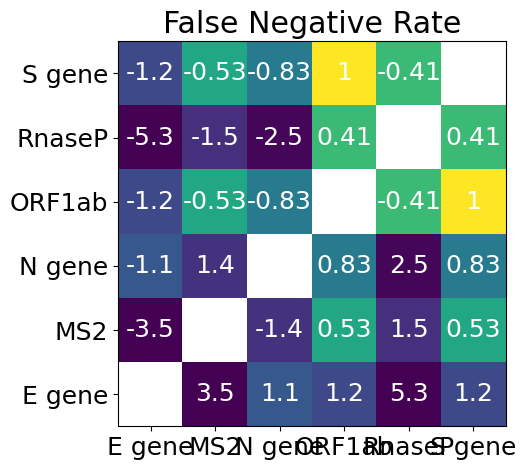

In [187]:
import matplotlib.pyplot as plt
fnr_df = pd.pivot(stat_target_df[['target1','target2','fnr_pval','fnr_zstat']],
                  index='target1', columns='target2', values=['fnr_pval','fnr_zstat'])

custom_text = fnr_df['fnr_zstat'].values
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(fnr_df['fnr_pval'], origin='lower', cmap='viridis', aspect='auto')
for i in range(custom_text.shape[0]):
    for j in range(custom_text.shape[1]):
        text = f"{custom_text[i, j]:.2g}"  # format text
        ax.text(j, i, text, ha="center", va="center", color="white")

xticks = fnr_df['fnr_pval'].columns
yticks = fnr_df['fnr_pval'].index
ax.set_xticks(range(len(xticks)))
ax.set_yticks(range(len(yticks)))
ax.set_xticklabels(xticks)
ax.set_yticklabels(yticks)
plt.title("False Negative Rate")
# plt.colorbar(im)
plt.show()


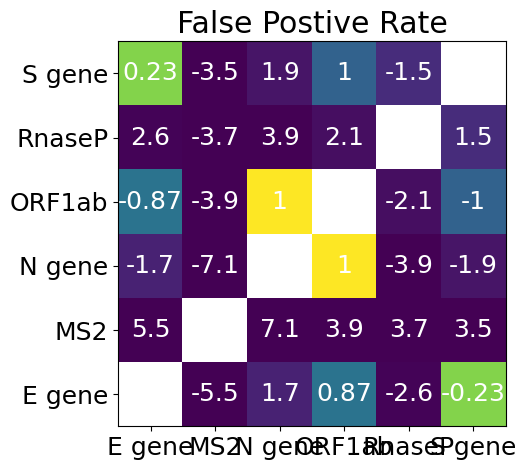

In [188]:
import matplotlib.pyplot as plt
fpr_df = pd.pivot(stat_target_df[['target1','target2','fpr_pval','fpr_zstat']],
                  index='target1', columns='target2', values=['fpr_pval','fpr_zstat'])
custom_text = fpr_df['fpr_zstat'].values
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(fpr_df['fpr_pval'], origin='lower', cmap='viridis', aspect='auto')
for i in range(custom_text.shape[0]):
    for j in range(custom_text.shape[1]):
        text = f"{custom_text[i, j]:.2g}"  # format text
        ax.text(j, i, text, ha="center", va="center", color="white")

xticks = fpr_df['fpr_pval'].columns
yticks = fpr_df['fpr_pval'].index
ax.set_xticks(range(len(xticks)))
ax.set_yticks(range(len(yticks)))
ax.set_xticklabels(xticks)
ax.set_yticklabels(yticks)
plt.title("False Postive Rate")
# plt.colorbar(im)
plt.show()


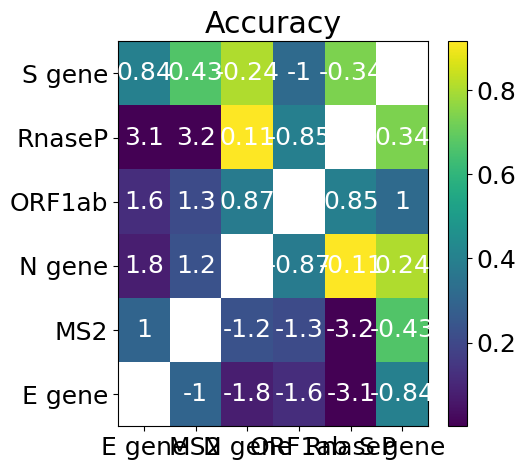

In [189]:
import matplotlib.pyplot as plt
acc_df = pd.pivot(stat_target_df[['target1','target2','acc_pval','acc_zstat']],
                  index='target1', columns='target2', values=['acc_pval','acc_zstat'])
custom_text = acc_df['acc_zstat'].values
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(acc_df['acc_pval'], origin='lower', cmap='viridis', aspect='auto')
for i in range(custom_text.shape[0]):
    for j in range(custom_text.shape[1]):
        text = f"{custom_text[i, j]:.2g}"  # format text
        ax.text(j, i, text, ha="center", va="center", color="white")

xticks = acc_df['acc_pval'].columns
yticks = acc_df['acc_pval'].index
ax.set_xticks(range(len(xticks)))
ax.set_yticks(range(len(yticks)))
ax.set_xticklabels(xticks)
ax.set_yticklabels(yticks)
plt.title("Accuracy")
plt.colorbar(im)
plt.show()


## retest

In [65]:
full_retest_pred = (retest_pred
                  .merge(join_df[['curve_idx','threshold','pcr_plate','thres_ct','cycle_no','drn','cq']], #'test_kit',
                         on = 'curve_idx'))
# full_retest_pred['encoded_igi_call'] = 1*(full_retest_pred.igi_call == 'Positive')
print(full_retest_pred.shape)

(39270, 17)


In [66]:
check_df = full_retest_pred.groupby(['pcr_plate','target','threshold']).drn.min().reset_index()
check_df['ratio'] = check_df['drn']/check_df['threshold'] -1 

In [67]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label==1)/retest_pred.shape[0]
print('True retest positive fraction:', true_retest_pos_frac)


True retest positive fraction: 0.3598233995584989


In [68]:
retest_thres_ct_df = full_retest_pred.loc[full_retest_pred.thres_ct != 'Undetermined', ['curve_idx','thres_ct']].drop_duplicates()
retest_thres_ct_df['cycle_no'] = retest_thres_ct_df.thres_ct.apply(lambda x: np.around(float(x)))

retest_new_thres_df = (full_retest_pred[['pcr_plate','target','curve_idx','cycle_no','drn','cq']]
                  .merge(retest_thres_ct_df, on=['curve_idx','cycle_no']))
retest_new_thres_df['igi_threshold'] = retest_new_thres_df.groupby(['pcr_plate','target']).drn.transform('mean')

full_retest_pred = (full_retest_pred
                  .merge(retest_new_thres_df[['curve_idx','igi_threshold']], on =['curve_idx'], how='left')
                  )


full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'igi_threshold'] = full_retest_pred.loc[full_retest_pred.igi_threshold.isna(),'threshold']
print(full_retest_pred.shape)

thres_df = {'fpr':[], 'fnr':[], 'pos_pred': [], 'perc': [], 'cycle': []}
cq_df = full_retest_pred[full_retest_pred.cq != 'Undetermined'][full_retest_pred.encoded_igi_call == 1].groupby(['pcr_plate','target']).cq.apply(lambda x: np.ceil(x.astype(float).max())).reset_index()
full_retest_pred = (full_retest_pred.merge(cq_df, how='left', on=['pcr_plate','target'], suffixes=('', '_new')))


(39270, 18)


/tmp/ipykernel_1308378/1432238028.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cq_df = full_retest_pred[full_retest_pred.cq != 'Undetermined'][full_retest_pred.encoded_igi_call == 1].groupby(['pcr_plate','target']).cq.apply(lambda x: np.ceil(x.astype(float).max())).reset_index()


### systematically move Fn thresholds

In [69]:
print(f"Number of invalid/inconclusive samples: {join_df[join_df.current_sample_result.isin(['Invalid','Inconclusive'])].sample_id.nunique()}")
print(f"Proportion of invalid/inconclusive samples got retested: {join_df[join_df.current_sample_result.isin(['Invalid','Inconclusive'])][join_df.retest_sample_id_1 != ' '].sample_id.nunique()/2548}")

Number of invalid/inconclusive samples: 2548
Proportion of invalid/inconclusive samples got retested: 0.4815541601255887


/tmp/ipykernel_1308378/3491393301.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"Proportion of invalid/inconclusive samples got retested: {join_df[join_df.current_sample_result.isin(['Invalid','Inconclusive'])][join_df.retest_sample_id_1 != ' '].sample_id.nunique()/2548}")


In [ ]:
retest_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in fn_range:
    for cycle in range(25):
        df = full_retest_pred.copy()
        df['new_threshold'] = df.igi_threshold * (1 + perc)
        
        df['if_pass'] = df.drn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')
        
        
        # if df.test_kit.iloc[0] == 'Thermo':
        df.loc[df.test_kit == 'Thermo','new_igi_call'] = 1*(df[df.test_kit == 'Thermo'].new_ct <= cycle_range_dict['Thermo'][cycle])
    
        df.loc[(df.test_kit == 'LuNER') & (df.target == 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target == 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['RnaseP'][cycle])
        df.loc[(df.test_kit == 'LuNER') & (df.target != 'RnaseP'), 'new_igi_call'] = 1*(df[(df.test_kit == 'LuNER') & (df.target != 'RnaseP')].new_ct <= cycle_range_dict['LuNER']['other'][cycle])
        
        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        retest_thres_df['fpr'].append(fp/(fp+tn))
        retest_thres_df['fnr'].append(fn/(fn+tp))
        retest_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
        

In [71]:
retest_final_thres_df_1 = pd.read_csv('final_thres_df_retest.csv')
retest_final_thres_df_2 = pd.read_csv('final_thres_df_new_retest_2.csv')
retest_final_thres_df_3 = pd.read_csv('final_thres_df_new_retest_2_wofakeids.csv')
retest_final_thres_df = pd.concat([retest_final_thres_df_1, retest_final_thres_df_2, retest_final_thres_df_3]).reset_index(drop=True)

In [72]:
prevalence = retest_pred[retest_pred.groundtruth_label == 1].shape[0]/retest_pred.shape[0]
retest_final_thres_df['accuracy'] = (prevalence*(1-retest_final_thres_df.fnr) + (1 - prevalence)*(1-retest_final_thres_df.fpr))
best_achievable_best_acc_idx = retest_final_thres_df.accuracy.idxmax()
bestacchieve_bestacc_posfrac = retest_final_thres_df.loc[best_achievable_best_acc_idx, 'pos_pred']
bestacchieve_bestacc_fnr = retest_final_thres_df.loc[best_achievable_best_acc_idx, 'fnr']
bestacchieve_bestacc_fpr = retest_final_thres_df.loc[best_achievable_best_acc_idx, 'fpr']
print('best achievable threshold rule Best Accuracy on ReTest:', retest_final_thres_df.loc[best_achievable_best_acc_idx, 'accuracy'])
print('best achievable threshold rule Best accuracy FNR on ReTest:', retest_final_thres_df.loc[best_achievable_best_acc_idx, 'fnr'])
print('best achievable threshold rule Best accuracy FPR on ReTest:', retest_final_thres_df.loc[best_achievable_best_acc_idx, 'fpr'])

best achievable threshold rule Best Accuracy on ReTest: 0.804635761589404
best achievable threshold rule Best accuracy FNR on ReTest: 0.4325153374233129
best achievable threshold rule Best accuracy FPR on ReTest: 0.0620689655172413


In [73]:
igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
retest_igi_fnr = igi_fn/(igi_fn+igi_tp) 
retest_igi_pos_frac = (igi_fp + igi_tp)/(igi_fp+igi_tp+igi_fn+igi_tn)
retest_igi_fpr = igi_fp/(igi_fp + igi_tn)
print('IGI FNR on retest:', retest_igi_fnr)
print('IGI FPR on retest:', retest_igi_fpr)
print('IGI positive fraction on retest:', retest_igi_pos_frac)

IGI FNR on retest: 0.36809815950920244
IGI FPR on retest: 0.16034482758620688
IGI positive fraction on retest: 0.33002207505518766


In [74]:
true_retest_pos_frac = sum(retest_pred.groundtruth_label == 1)/retest_pred.shape[0]
print('True retest positive rate:', true_retest_pos_frac)

True retest positive rate: 0.3598233995584989


In [75]:
retest_final_thres_df['diff'] = abs(retest_final_thres_df.pos_pred - true_retest_pos_frac)
retest_prevalance = retest_pred[retest_pred.groundtruth_label == 1].shape[0]/retest_pred.shape[0]
retest_final_thres_df['accuracy'] = (prevalence*(1-retest_final_thres_df.fnr) + (1 - prevalence)*(1-retest_final_thres_df.fpr))
retest_best_achievable_best_acc_idx = retest_final_thres_df.accuracy.idxmax()
retest_bestacchieve_bestacc_posfrac = retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'pos_pred']
retest_bestacchieve_bestacc_fnr = retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'fnr']
retest_bestacchieve_bestacc_fpr = retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'fpr']
print('best achievable threshold rule Best Accuracy on Re-Test:', retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'accuracy'])
print('best achievable threshold rule Best accuracy FNR on Re-Test:', retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'fnr'])
print('best achievable threshold rule Best accuracy FPR on Re-Test:', retest_final_thres_df.loc[retest_best_achievable_best_acc_idx, 'fpr'])
print('\n')
print('True positive fraction:')
print('Best achievable threshold rule FPR:', retest_final_thres_df.sort_values('diff').head(1).fpr.unique(),
      ' - FNR: ', deepnet_model_retest_dict_df.sort_values('diff').head(1).fnr.unique())

best achievable threshold rule Best Accuracy on Re-Test: 0.804635761589404
best achievable threshold rule Best accuracy FNR on Re-Test: 0.4325153374233129
best achievable threshold rule Best accuracy FPR on Re-Test: 0.0620689655172413


True positive fraction:
Best achievable threshold rule FPR: [0.18965517]  - FNR:  [0.34969325]


In [104]:
plate_thres_df = {'pcr_plate':[], 'fpr':[], 'fnr':[], 'pos_pred': [], 'cycle':[], 'perc':[]}
pcr_plate = 'AC00DB6F' #full_test_pred.pcr_plate.unique()[0]
fn_range = np.arange(8, 10, 0.05)
for perc in fn_range:
    # for cycle in range(-1,2):
    for cycle in range(-1,5):
        df = full_retest_pred[full_retest_pred.pcr_plate == pcr_plate].copy()
        df['new_threshold'] = df.threshold * (1 + perc)

        df['if_pass'] = df.drn >= df.new_threshold

        pass_ct = df[(df.if_pass)& (df.cycle_no >= 20)] \
            .groupby('curve_idx').cycle_no.min().reset_index()
        pass_ct.columns = ['curve_idx', 'new_ct']
        df = df.merge(pass_ct, how='left', on='curve_idx')
        df['new_ct'] = df['new_ct'].fillna(np.Inf)

        fake_df = df[(df.cycle_no >= df.new_ct)] \
            .sort_values(['curve_idx','cycle_no']) \
            .groupby('curve_idx').tail(5) \
            .groupby('curve_idx').if_pass.all().reset_index()
        fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

        df['new_igi_call'] = 1*((df.new_ct <= df.cq_new.astype(float) + cycle))
        df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0

        df_1 = df[df.cycle_no == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()


        plate_thres_df['fpr'].append(fp/(fp+tn))
        plate_thres_df['fnr'].append(fn/(fn+tp))
        plate_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        plate_thres_df['pcr_plate'].append(pcr_plate)
        plate_thres_df['cycle'].append(cycle)
        plate_thres_df['perc'].append(perc)


In [76]:
smallest_fnr = pd.read_csv('smallest_fnr_retest.csv')
smallest_fpr = pd.read_csv('smallest_fpr_retest.csv')

cycle_range = np.arange(20,45)

smallest_fpr_thres = full_retest_pred.merge(smallest_fpr[['pcr_plate','cycle','perc']], on=['pcr_plate'], how='left', suffixes=('', '_thres'))
smallest_fpr_thres['new_threshold'] = smallest_fpr_thres.igi_threshold * (1 + smallest_fpr_thres.perc)
smallest_fpr_thres['if_pass'] = smallest_fpr_thres.drn >= smallest_fpr_thres.new_threshold
passed_ids = smallest_fpr_thres[smallest_fpr_thres.if_pass].curve_idx.unique()
smallest_fpr_thres['new_ct'] = np.Inf
smallest_fpr_thres.loc[smallest_fpr_thres.curve_idx.isin(passed_ids), 'new_ct'] = smallest_fpr_thres[smallest_fpr_thres.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')

smallest_fpr_thres['new_igi_call'] = smallest_fpr_thres['new_ct'] <= cycle_range[smallest_fpr_thres['cycle']]

df_1 = smallest_fpr_thres[smallest_fpr_thres.cycle_no == 1]
tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
print('Smallest FPR and corresponding other metrics:')
igi_smallest_fpr = fp/(fp+tn) 
igi_smallestfpr_fnr = fn/(fn+tp)
igi_smallestfpr_pospred = (fp+tp)/(fp+tp+tn+fn)
igi_smallest_fpr, igi_smallestfpr_fnr, igi_smallestfpr_pospred

Smallest FPR and corresponding other metrics:


(0.4827586206896552, 0.07975460122699386, 0.6401766004415012)

In [77]:

smallest_fnr_thres = full_retest_pred.merge(smallest_fnr[['pcr_plate','cycle','perc']], on=['pcr_plate'], how='left', suffixes=('', '_thres'))
smallest_fnr_thres['new_threshold'] = smallest_fnr_thres.igi_threshold * (1 + smallest_fnr_thres.perc)
smallest_fnr_thres['if_pass'] = smallest_fnr_thres.drn >= smallest_fnr_thres.new_threshold
passed_ids = smallest_fnr_thres[smallest_fnr_thres.if_pass].curve_idx.unique()
smallest_fnr_thres['new_ct'] = np.Inf
smallest_fnr_thres.loc[smallest_fnr_thres.curve_idx.isin(passed_ids), 'new_ct'] = smallest_fnr_thres[smallest_fnr_thres.curve_idx.isin(passed_ids)].groupby('curve_idx').cycle_no.transform('min')

smallest_fnr_thres['new_igi_call'] = smallest_fnr_thres['new_ct'] <= cycle_range[smallest_fnr_thres['cycle']]

df_1 = smallest_fnr_thres[smallest_fnr_thres.cycle_no == 1]
tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
print('Smallest fnr and corresponding other metrics:')
igi_smallest_fnr = fn/(fn+tp) 
igi_smallestfnr_fpr = fp/(fp+tn)
igi_smallestfnr_pospred = (fp+tp)/(fp+tp+tn+fn)
igi_smallest_fnr, igi_smallestfnr_fpr, igi_smallestfnr_pospred

Smallest fnr and corresponding other metrics:


(0.03374233128834356, 0.593103448275862, 0.7273730684326711)

/tmp/ipykernel_1308378/3499067889.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


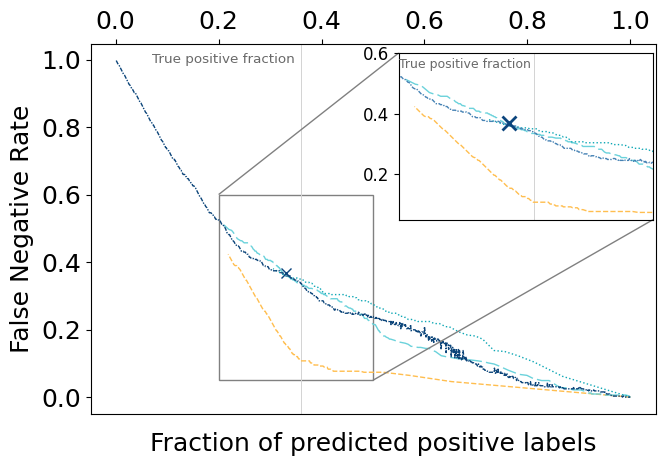

In [78]:
from matplotlib.gridspec import GridSpec

retest_final_thres_df['pos_pred'] = retest_final_thres_df['pos_pred'].round(3)
retest_fnr_df = retest_final_thres_df.groupby('pos_pred').fnr.min().reset_index()
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)

fig = plt.figure(figsize=(7,5))
# plt.rcParams.update({'font.size': 18})

# Top plot (larger)
ax1 = fig.add_subplot()
ax1.axvline(true_retest_pos_frac, color='lightgray', linewidth=0.7)
ax1.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color=color_map.get('fusion'), linewidth=1, 
         linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, linewidth=1, 
         color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, linewidth=1, 
         color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(retest_fnr_df.pos_pred, 
         retest_fnr_df.fnr, color=color_map.get('igi'), linewidth=1, 
         linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
ax1.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='#0c457d', **{'ms':7,'mew':1}, label='Implemented threshold rule')
# ax1.plot(bestacc_pos_pred, bestacc_fnr, '^', color=color_map.get('fusion'), **{'ms':8,'mew':1}, label='Smallest Possible Threshold-based FPR')

ax1.text(x=0.07, y = 0.99, s='True positive fraction', c='dimgray', fontsize=9.7)
ax1.set_xlabel('Fraction of predicted positive labels',fontsize=18, labelpad=13)
ax1.set_ylabel('False Negative Rate', fontsize=18, labelpad=5)
ax1.set_position([0., 0., 1., 1], which='both')
ax1.tick_params(axis='x', labeltop=True, top=True, labelsize=18)   # Show ticks & labels on top
ax1.tick_params(axis='x', labelbottom=False, bottom=False)  # Optional: Hide bottom labels
ax1.tick_params(axis='y', labelsize=18)

# inset
axins = inset_axes(ax1, width="45%", height="45%", 
                bbox_to_anchor=(0.27, 0.25, 1, 1),
                   bbox_transform=ax1.transAxes, 
                   loc="center")
# Connect inset to the main plot
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

axins.axvline(true_retest_pos_frac, color='lightgray', linewidth=0.7)
axins.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, 
           linewidth=1, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), label='SPARK')
axins.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, 
           linewidth=1, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
axins.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, 
           linewidth=1, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
axins.plot(retest_fnr_df.pos_pred, 
         retest_fnr_df.fnr, color=color_map.get('achievable'), 
         linestyle=linestyle_map.get('achievable'),
         linewidth=1, label='Best achievable threshold rule')
axins.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='#0c457d', **{'ms':10,'mew':2}, label='Implemented threshold rule')


axins.text(x=0.2, y = 0.55, s='True positive fraction', c='dimgray', fontsize=9)

# axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
#                labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
axins.tick_params(axis='x', labelsize=12)
axins.tick_params(axis='y', labelsize=12)
axins.set_ylim(0.05, 0.6)
axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
               labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
axins.set_xlim(0.2, 0.5)
axins.set_position([0., 0., 1., 1], which='both')



plt.subplots_adjust(hspace=0.25)
plt.tight_layout()

In [284]:
print('SPARK highest accuracy:', retest_model_dict_df.acc.max())
print('qpcR highest accuracy:', qpcr_model_retest_dict_df.acc.max())
print('qPCRdeepNet highest accuracy:', deepnet_model_retest_dict_df.acc.max())
print('IGI accuracy:', accuracy_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call))
print('Best achievable threshold rule accuracy:', retest_final_thres_df.accuracy.max())

retest_spark_maxacc_idx = retest_model_dict_df.acc.idxmax()
retest_qpcr_maxacc_idx = qpcr_model_retest_dict_df.acc.idxmax()
retest_deepnet_maxacc_idx = deepnet_model_retest_dict_df.acc.idxmax()
retest_achievable_maxacc_idx = retest_final_thres_df.accuracy.idxmax()

print('SPARK highest accuracy FNR:', retest_model_dict_df.loc[retest_spark_maxacc_idx, 'fnr'])
print('SPARK highest accuracy FPR:', retest_model_dict_df.loc[retest_spark_maxacc_idx, 'fpr'])
print('qpcR highest accuracy FNR:', qpcr_model_retest_dict_df.loc[retest_qpcr_maxacc_idx,'fnr'])
print('qpcR highest accuracy FPR:', qpcr_model_retest_dict_df.loc[retest_qpcr_maxacc_idx,'fpr'])
print('qPCRdeepNet highest accuracy FNR:', deepnet_model_retest_dict_df.loc[retest_deepnet_maxacc_idx, 'fnr'])
print('qPCRdeepNet highest accuracy FPR:', deepnet_model_retest_dict_df.loc[retest_deepnet_maxacc_idx, 'fpr'])

print('Best achievable threshold rule accuracy FNR:', retest_final_thres_df.loc[retest_achievable_maxacc_idx, 'fnr'])
print('Best achievable threshold rule accuracy FPR:', retest_final_thres_df.loc[retest_achievable_maxacc_idx, 'fpr'])

SPARK highest accuracy: 0.9238410596026491
qpcR highest accuracy: 0.7858719646799117
qPCRdeepNet highest accuracy: 0.7803532008830022
IGI accuracy: 0.7649006622516556
Best achievable threshold rule accuracy: 0.804635761589404
SPARK highest accuracy FNR: 0.10736196319018405
SPARK highest accuracy FPR: 0.05862068965517241
qpcR highest accuracy FNR: 0.46932515337423314
qpcR highest accuracy FPR: 0.0706896551724138
qPCRdeepNet highest accuracy FNR: 0.3803680981595092
qPCRdeepNet highest accuracy FPR: 0.12931034482758622
Best achievable threshold rule accuracy FNR: 0.4325153374233129
Best achievable threshold rule accuracy FPR: 0.0620689655172413


### inclusive and invalid results

In [205]:
retest_pred_copy = retest_pred.copy()
retest_pred_copy['sample_id'] = retest_pred_copy['sample_id'].astype('str')
best_retest_acc_threshold = retest_model_dict_df.loc[retest_spark_maxacc_idx, 'thres']
retest_pred_copy['pred'] = 1*(retest_pred_copy.outputs >= best_retest_acc_threshold)
sample_type_df = join_df[['sample_id','current_sample_result']].drop_duplicates()
sample_type_df['sample_id'] = sample_type_df['sample_id'].astype('str')
df = retest_pred_copy.merge(sample_type_df, on='sample_id')
invalid_df = df[df.current_sample_result == 'Invalid']
print('Invalid samples in retest:', invalid_df.shape[0])
print('SPARK invalid accuracy:', accuracy_score(invalid_df.groundtruth_label, invalid_df.pred))
tn, fp, fn, tp = confusion_matrix(invalid_df.groundtruth_label, invalid_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK Invalid FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')

qpcr_retest_pred_copy = qpcr_retest_pred.copy()
qpcr_retest_pred_copy['pred'] = 1*(qpcr_retest_pred_copy.prob >= qpcr_model_dict_df.loc[retest_qpcr_maxacc_idx, 'thres'])
qpcr_invalid_df = qpcr_retest_pred_copy[qpcr_retest_pred_copy.curve_idx.isin(invalid_df.curve_idx)]
print('qpcr invalid accuracy:', accuracy_score(qpcr_invalid_df.groundtruth_label, qpcr_invalid_df.pred))
tn, fp, fn, tp = confusion_matrix(qpcr_invalid_df.groundtruth_label, qpcr_invalid_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcr Invalid FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')

retest_qpcrdeepnet_copy = retest_qpcrdeepnet.copy()
retest_qpcrdeepnet_copy['pred'] = 1*(retest_qpcrdeepnet_copy.prob >= qpcr_model_dict_df.loc[retest_deepnet_maxacc_idx, 'thres'])
deepnet_invalid_df = retest_qpcrdeepnet_copy[retest_qpcrdeepnet_copy.curve_idx.isin(invalid_df.curve_idx)]
print('deepnet invalid accuracy:', accuracy_score(deepnet_invalid_df.groundtruth_label, deepnet_invalid_df.pred))
tn, fp, fn, tp = confusion_matrix(deepnet_invalid_df.groundtruth_label, deepnet_invalid_df.pred, labels=np.array([0,1])).ravel()
print(f'deepnet Invalid FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')

print('\n')
inconclusive_df = df[df.current_sample_result == 'Inconclusive']
print('inconclusive samples in retest:', inconclusive_df.shape[0])
print('SPARK inconclusive accuracy:', accuracy_score(inconclusive_df.groundtruth_label, inconclusive_df.pred))
tn, fp, fn, tp = confusion_matrix(inconclusive_df.groundtruth_label, inconclusive_df.pred, labels=np.array([0,1])).ravel()
print(f'SPARK Inconclusive FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')

qpcr_inconclusive_df = qpcr_retest_pred_copy[qpcr_retest_pred_copy.curve_idx.isin(inconclusive_df.curve_idx)]
print('qpcr inconclusive accuracy:', accuracy_score(qpcr_inconclusive_df.groundtruth_label, qpcr_inconclusive_df.pred))
tn, fp, fn, tp = confusion_matrix(qpcr_inconclusive_df.groundtruth_label, qpcr_inconclusive_df.pred, labels=np.array([0,1])).ravel()
print(f'qpcr Inconclusive FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')

deepnet_inconclusive_df = retest_qpcrdeepnet_copy[retest_qpcrdeepnet_copy.curve_idx.isin(inconclusive_df.curve_idx)]
print('deepnet inconclusive accuracy:', accuracy_score(deepnet_inconclusive_df.groundtruth_label, deepnet_inconclusive_df.pred))
tn, fp, fn, tp = confusion_matrix(deepnet_inconclusive_df.groundtruth_label, deepnet_inconclusive_df.pred, labels=np.array([0,1])).ravel()
print(f'deepnet Inconclusive FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')


Invalid samples in retest: 667
SPARK invalid accuracy: 0.952023988005997
SPARK Invalid FNR: 0.0815450643776824 - FPR: 0.029953917050691243
qpcr invalid accuracy: 0.7946026986506747
qpcr Invalid FNR: 0.51931330472103 - FPR: 0.03686635944700461
deepnet invalid accuracy: 0.782608695652174
deepnet Invalid FNR: 0.4721030042918455 - FPR: 0.08064516129032258


inconclusive samples in retest: 236
SPARK inconclusive accuracy: 0.847457627118644
SPARK Inconclusive FNR: 0.16666666666666666 - FPR: 0.14383561643835616
qpcr inconclusive accuracy: 0.7669491525423728
qpcr Inconclusive FNR: 0.3333333333333333 - FPR: 0.17123287671232876
deepnet inconclusive accuracy: 0.7754237288135594
deepnet Inconclusive FNR: 0.14444444444444443 - FPR: 0.273972602739726


In [207]:
perc=3.376
cycle = -5
df = full_retest_pred.copy()
df['cq_new'] = df.cq_new.fillna(20)
df['new_threshold'] = full_retest_pred.threshold * (1 + perc)

df['if_pass'] = df.drn >= df.new_threshold
# passed_ids = df[df.if_pass].curve_idx.unique()

pass_ct = df[(df.if_pass)& (df.cycle_no >= 15)] \
    .groupby('curve_idx').cycle_no.min().reset_index()
pass_ct.columns = ['curve_idx', 'new_ct']
df = df.merge(pass_ct, how='left', on='curve_idx')
df['new_ct'] = df['new_ct'].fillna(np.Inf)

fake_df = df[(df.cycle_no >= df.new_ct)] \
    .sort_values(['curve_idx','cycle_no']) \
    .groupby('curve_idx').tail(5) \
    .groupby('curve_idx').if_pass.all().reset_index()
# fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

df['new_igi_call'] = 1*((df.new_ct <= (df.cq_new.astype(float) + cycle)))
# df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0

df_1 = df[df.cycle_no == 1]
df_1 = df_1.merge(sample_type_df[['sample_id','current_sample_result']].drop_duplicates(), on='sample_id')
achievable_invalid_df = df_1[df_1.current_sample_result == 'Invalid']
tn, fp, fn, tp = confusion_matrix(achievable_invalid_df.groundtruth_label, achievable_invalid_df.new_igi_call, labels=np.array([0,1])).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)} - Accuracy: {accuracy_score(achievable_invalid_df.groundtruth_label, achievable_invalid_df.new_igi_call)}')

achievable_inconclusive_df = df_1[df_1.current_sample_result == 'Inconclusive']
tn, fp, fn, tp = confusion_matrix(achievable_inconclusive_df.groundtruth_label, achievable_inconclusive_df.new_igi_call, labels=np.array([0,1])).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)} - Accuracy: {accuracy_score(achievable_inconclusive_df.groundtruth_label, achievable_inconclusive_df.new_igi_call)}')


FNR: 0.8540772532188842 - FPR: 0.004608294930875576 - Accuracy: 0.6986506746626686
FNR: 1.0 - FPR: 0.0 - Accuracy: 0.6186440677966102


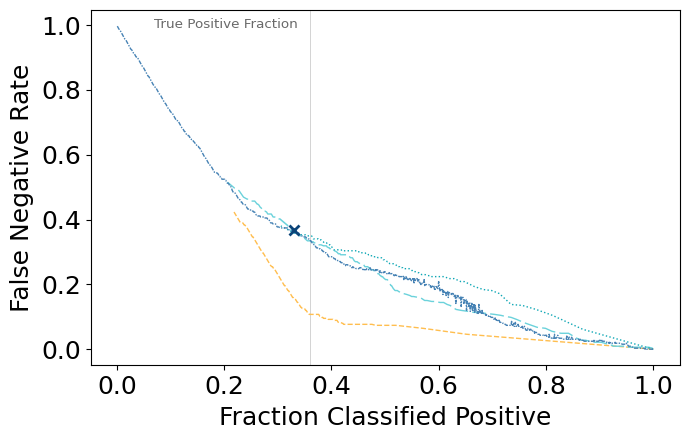

In [114]:
from matplotlib.gridspec import GridSpec
color_map = {'igi': '#0b4479', #'#008080',
             'fusion': '#ffbe4f',
             'qpcr':'#6bd2db',
             'deepnet': '#0ea7b5',
             'humanbased': '#ff1493',
             'achievable': '#4682b4'
             }
retest_final_thres_df['pos_pred'] = retest_final_thres_df['pos_pred'].round(3)
retest_fnr_df = retest_final_thres_df.groupby('pos_pred').fnr.min().reset_index()
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)

fig = plt.figure(figsize=(7,4.5))
# plt.rcParams.update({'font.size': 18})

# Top plot (larger)
ax1 = fig.add_subplot()
ax1.axvline(true_retest_pos_frac, color='lightgray', linewidth=0.7)
ax1.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, 
         color=color_map.get('fusion'), 
         linewidth=1, linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, 
         color=color_map.get('qpcr'), 
         linewidth=1, linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, 
         color=color_map.get('deepnet'), 
         linewidth=1, linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(retest_fnr_df.pos_pred, 
         retest_fnr_df.fnr, 
         color=color_map.get('achievable'), 
         linewidth=1, linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
ax1.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', 
         color=color_map.get('igi'), **{'ms':7,'mew':2}, label='Implemented threshold rule')
# ax1.plot(bestacc_pos_pred, bestacc_fnr, '^', color=color_map.get('fusion'), **{'ms':8,'mew':1}, label='Smallest Possible Threshold-based FPR')

ax1.text(x=0.07, y = 0.99, s='True Positive Fraction', c='dimgray', fontsize=9.7)
ax1.set_xlabel('Fraction Classified Positive',fontsize=18, labelpad=5)
ax1.set_ylabel('False Negative Rate', fontsize=18, labelpad=5)
ax1.set_position([0., 0., 1., 1], which='both')
# ax1.tick_params(axis='x', labeltop=True, top=True, labelsize=18)   # Show ticks & labels on top
# ax1.tick_params(axis='x', labelbottom=False, bottom=False)  # Optional: Hide bottom labels
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# inset
# axins = inset_axes(ax1, width="45%", height="45%", 
#                 bbox_to_anchor=(0.27, 0.25, 1, 1),
#                    bbox_transform=ax1.transAxes, 
#                    loc="center")
# # Connect inset to the main plot
# mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# axins.axvline(true_retest_pos_frac, color='lightgray', linewidth=0.7)
# axins.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), label='SPARK')
# axins.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
# axins.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
# axins.plot(retest_fnr_df.pos_pred, 
#          retest_fnr_df.fnr, color=color_map.get('igi'), 
#          linestyle=linestyle_map.get('igi'), label='Best achievable threshold rule')
# axins.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='#0c457d', **{'ms':10,'mew':2}, label='Implemented threshold rule')


# axins.text(x=0.2, y = 0.55, s='True positive fraction', c='dimgray', fontsize=9)

# # axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
# #                labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
# axins.tick_params(axis='x', labelsize=12)
# axins.tick_params(axis='y', labelsize=12)
# axins.set_ylim(0.05, 0.6)
# axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
#                labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
# axins.set_xlim(0.2, 0.5)
# axins.set_position([0., 0., 1., 1], which='both')



plt.subplots_adjust(hspace=0.25)
plt.tight_layout()

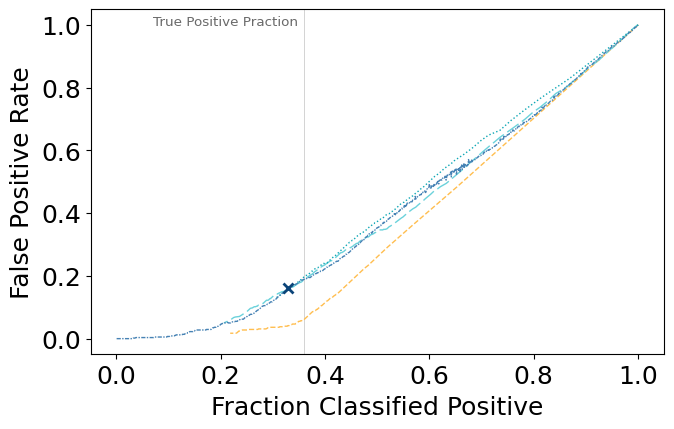

In [115]:
from matplotlib.gridspec import GridSpec

retest_fpr_df = retest_final_thres_df.groupby('pos_pred').fpr.min().reset_index()

fig = plt.figure(figsize=(7,8))
# plt.rcParams.update({'font.size': 18})
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio


# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
ax1.axvline(true_retest_pos_frac, color='lightgray', linewidth=0.7)
ax1.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, 
         color=color_map.get('fusion'), linewidth=1, linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fpr, 
         color=color_map.get('qpcr'), linewidth=1, linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fpr, 
         color=color_map.get('deepnet'), linewidth=1, linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(retest_fpr_df.pos_pred, 
         retest_fpr_df.fpr, color=color_map.get('achievable'), linewidth=1, linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
ax1.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color=color_map.get('igi'), 
         **{'ms':7,'mew':2}, label='Implemented threshold rule')
# ax1.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), **{'ms':8,'mew':1}, label='Smallest Possible Threshold-based FPR')

ax1.text(x=0.07, y = 1, s='True Positive Praction', c='dimgray', fontsize=9.7)
ax1.set_xlabel('Fraction Classified Positive',fontsize=18, labelpad=5)
ax1.set_ylabel('False Positive Rate', fontsize=18, labelpad=5)
ax1.set_position([0., 0., 1., 1], which='both')
# ax1.tick_params(axis='x', labeltop=True, top=True, labelsize=18)   # Show ticks & labels on top
# ax1.tick_params(axis='x', labelbottom=False, bottom=False)  # Optional: Hide bottom labels
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# inset
# axins = inset_axes(ax1, width="50%", height="50%", 
#                 bbox_to_anchor=(-0.18, 0.23, 1, 1),
#                    bbox_transform=ax1.transAxes, 
#                    loc="center")
# # Connect inset to the main plot
# mark_inset(ax1, axins, loc1=1, loc2=3, fc="none", ec="0.5")

# axins.axvline(true_pos_frac, color='lightgray', linewidth=0.7)
# axins.plot(model_dict_df.pos_frac, model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), label='SPARK')
# axins.plot(qpcr_model_dict_df.pos_frac, qpcr_model_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
# axins.plot(deepnet_model_dict_df.pos_frac, deepnet_model_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
# axins.plot(fpr_df.pos_pred, 
#          fpr_df.fpr, color=color_map.get('igi'), 
#          linestyle=linestyle_map.get('igi'), label='Best achievable threshold rule')
# axins.plot(igi_pos_frac, igi_fpr, 'x', color='#0c457d', **{'ms':10,'mew':2}, label='Implemented threshold rule')
# axins.plot(bestacc_pos_pred, bestacc_fpr, '^', color=color_map.get('fusion'), 
#            **{'ms':8,'mew':2}, label='Smallest Possible Threshold-based FPR')

# axins.text(x=0.825, y = 0.3, s='True positive fraction', c='dimgray', fontsize=9)

# # axins.set_yticks(ticks=np.arange(0.0, 0.13, 0.03), 
# #                labels=['0.0','0.03', '0.06','0.09','0.12'], fontsize=12)
# axins.set_ylim(-0.02, 0.62)
# axins.tick_params(axis='y', labelsize=12)
# axins.set_xticks(ticks=np.arange(0.8, 0.951, 0.05), 
#                labels=['0.80','0.85','0.90', '0.95'], fontsize=12)
# axins.set_xlim(0.8, 0.95)
# axins.set_position([0., 0., 1., 1], which='both')

plt.subplots_adjust(hspace=0.25)
plt.tight_layout()

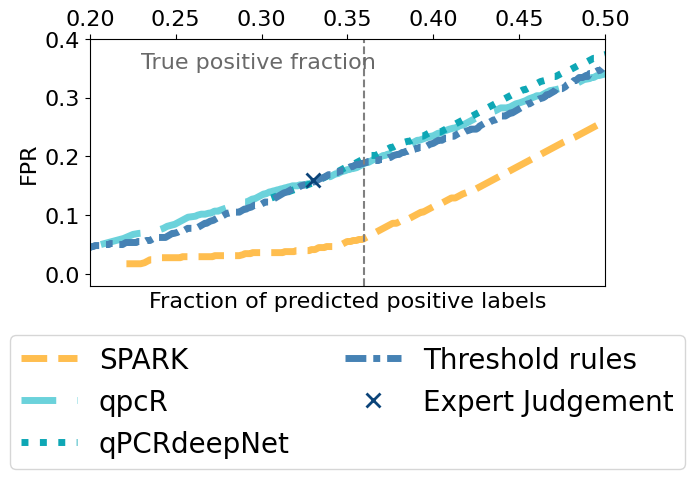

In [210]:
from matplotlib.gridspec import GridSpec
retest_fpr_df = retest_final_thres_df.groupby('pos_pred').fpr.min().reset_index()
fig = plt.figure(figsize=(7, 8))
plt.rcParams.update({'font.size': 16})  # 2:1 height ratio
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio

# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fpr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), linewidth=5, label='SPARK')
ax1.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fpr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), linewidth=5, label='qpcR')
ax1.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fpr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), linewidth=5, label='qPCRdeepNet')
ax1.plot(retest_fpr_df.pos_pred, 
         retest_fpr_df.fpr, color=color_map.get('achievable'), linestyle=linestyle_map.get('achievable'), 
         linewidth=5, label='Threshold rules')
ax1.plot(retest_igi_pos_frac, retest_igi_fpr, 'x', color=color_map.get('igi'),
         **{'ms':10,'mew':2}, linewidth=5, label='Expert Judgement')

# zoom_region = Rectangle((0.3, 0.038), 0.12, 0.18, edgecolor="0.5", facecolor="none", linewidth=.7)
# ax1.add_patch(zoom_region)
ax1.axvline(true_retest_pos_frac, linestyle='--', color='gray', linewidth=1.5)
ax1.text(x=0.23, y = 0.35, s='True positive fraction', c='dimgray', fontsize=16)
ax1.set_xlabel('Fraction of predicted positive labels', fontsize=16)
ax1.set_ylabel('FPR', fontsize=16)
ax1.set_position([0., 0., 1., 1], which='both')
ax1.set_xlim(0.2, 0.5)
ax1.set_ylim(-0.02, 0.4)
plt.subplots_adjust(hspace=0.25)
plt.tick_params(axis='x', top=True, bottom=False)  # Show ticks on top, hide bottom
plt.tick_params(axis='x', labeltop=True, labelbottom=False)  # Show labels on top, hide bottom
# ax.grid(color='gainsboro')
plt.legend(loc='lower center', fontsize=20, ncol = 2, bbox_to_anchor=(0.5,-0.8))

plt.tight_layout()

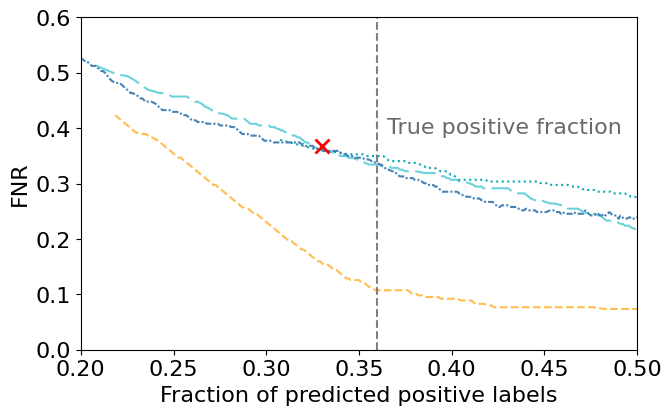

In [211]:
from matplotlib.gridspec import GridSpec
retest_fnr_df = retest_final_thres_df.groupby('pos_pred').fnr.min().reset_index()
fig = plt.figure(figsize=(7, 8))
plt.rcParams.update({'font.size': 16})  # 2:1 height ratio
gs = GridSpec(2, 1, height_ratios=[1, 1])  # 2:1 height ratio

# Top plot (larger)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(retest_model_dict_df.pos_frac, retest_model_dict_df.fnr, color=color_map.get('fusion'), linestyle=linestyle_map.get('fusion'), label='SPARK')
ax1.plot(qpcr_model_retest_dict_df.pos_frac, qpcr_model_retest_dict_df.fnr, color=color_map.get('qpcr'), linestyle=linestyle_map.get('qpcr'), label='qpcR')
ax1.plot(deepnet_model_retest_dict_df.pos_frac, deepnet_model_retest_dict_df.fnr, color=color_map.get('deepnet'), linestyle=linestyle_map.get('deepnet'), label='qPCRdeepNet')
ax1.plot(retest_fnr_df.pos_pred, 
         retest_fnr_df.fnr, color=color_map.get('achievable'), linestyle=linestyle_map.get('achievable'), label='Best achievable threshold rule')
ax1.plot(retest_igi_pos_frac, retest_igi_fnr, 'x', color='red', **{'ms':10,'mew':2}, label='Expert-chosen threshold rule')

# zoom_region = Rectangle((0.3, 0.038), 0.12, 0.18, edgecolor="0.5", facecolor="none", linewidth=.7)
# ax1.add_patch(zoom_region)
ax1.axvline(true_retest_pos_frac, linestyle='--', color='gray')
ax1.text(x=0.365, y = 0.39, s='True positive fraction', c='dimgray', fontsize=16)
ax1.set_xlabel('Fraction of predicted positive labels', fontsize=16)
ax1.set_ylabel('FNR', fontsize=16)
ax1.set_position([0., 0., 1., 1], which='both')
ax1.set_xlim(0.2, 0.5)
ax1.set_ylim(0.0, 0.6)
plt.subplots_adjust(hspace=0.25)
# ax.grid(color='gainsboro')
plt.tight_layout()

In [117]:
df_1 = full_retest_pred[full_retest_pred.cycle_no == 1].copy()
retest_final_metrics = retest_final_thres_df.groupby('fpr').fnr.min().reset_index()
retest_final_metrics['tpr'] = 1 - retest_final_metrics.fnr
# retest_final_metrics.loc[0,['fpr','tpr']] = [0, 0]
# retest_final_metrics.loc[len(retest_final_metrics),['fpr','tpr']] = [1, 1]
retest_final_metrics.sort_values('fpr', inplace=True)
retest_final_metrics['tp'] = retest_final_metrics['tpr']*sum(df_1.groundtruth_label)
retest_final_metrics['fn'] = sum(df_1.groundtruth_label) - retest_final_metrics['tp']
retest_final_metrics['fp'] = retest_final_metrics['fpr']*sum(df_1.groundtruth_label == 0)
retest_final_metrics['tn'] = sum(df_1.groundtruth_label == 0) - retest_final_metrics['fp']

In [118]:
retest_final_thres_df[retest_final_thres_df.fnr.isna()]

,fpr,fnr,pos_pred,perc,cycle,fpr_type,fnr_type,accuracy,diff,tpr


In [119]:
# retest_final_metrics = retest_final_thres_df.groupby('fpr').fnr.min().reset_index()
retest_final_metrics[retest_final_metrics.fnr.isna()]

,fpr,fnr,tpr,tp,fn,fp,tn


SPARK AUC: 0.9360006346519991
IGI AUC: 0.7357785064522951
qpcR AUC: 0.8171618037135279
deepNet AUC: 0.7743706367675058
Best achievable AUC: 0.7712185318383754


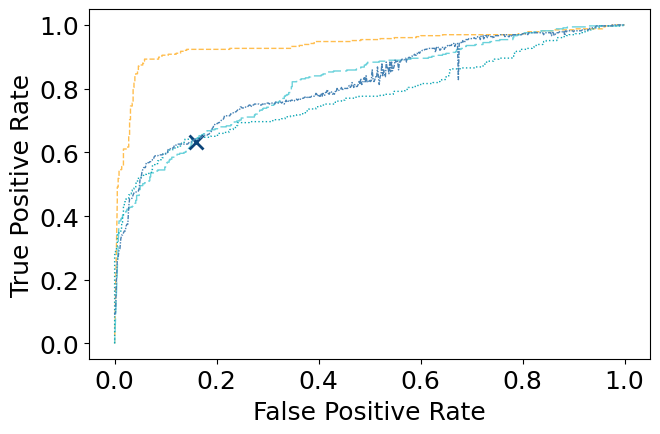

In [120]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

retest_final_thres_df['tpr'] = 1 - retest_final_thres_df['fnr']
retest_best_achievable_roc = retest_final_thres_df.groupby('fpr').tpr.max().reset_index()

# Example data
fpr1, tpr1, _ = roc_curve(retest_pred.groundtruth_label, retest_pred.outputs)
fpr2, tpr2, _ = roc_curve(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
fpr3, tpr3, _ = roc_curve(qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].groundtruth_label, qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].prob)
fpr4, tpr4, _ = roc_curve(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.prob)

auc1 = auc(fpr1, tpr1)
print('SPARK AUC:', auc1)
auc2 = auc(fpr2, tpr2)
print('IGI AUC:', auc2)
auc3 = auc(fpr3, tpr3)
print('qpcR AUC:', auc3)
auc4 = auc(fpr4, tpr4)
print('deepNet AUC:', auc4)


fpr = retest_final_thres_df['fpr'].values
fpr = np.insert(fpr, [0, 1], [0, 1])
tpr = retest_final_thres_df['tpr'].values
tpr = np.insert(tpr, [0, 1], [0, 1])
# Make sure fpr is sorted in ascending order
sorted_idx = fpr.argsort()
fpr = fpr[sorted_idx]
tpr = tpr[sorted_idx]

# Calculate AUC
roc_auc = auc(fpr, tpr)
print('Best achievable AUC:', roc_auc)


# Plot
plt.figure(figsize=(7, 4.75))
plt.rcParams.update({'font.size': 20, 'lines.linewidth': 2})
plt.plot(fpr1, tpr1, label=f'SPARK (AUC = {auc1:.2f})', 
         linewidth=1, linestyle=linestyle_map.get('fusion'), color=color_map.get('fusion'))
# plt.plot(fpr2, tpr2, label=f'Expert Judgement (AUC = {auc2:.2f})', linewidth=1, linestyle=linestyle_map.get('igi'), color=color_map.get('igi'))
plt.plot(fpr3, tpr3, label=f'qpcR (AUC = {auc3:.2f})', 
         linewidth=1, linestyle=linestyle_map.get('qpcr'), color=color_map.get('qpcr'))
plt.plot(fpr4, tpr4, label=f'qPCRdeepNet (AUC = {auc4:.2f})', 
         linewidth=1, linestyle=linestyle_map.get('deepnet'), color=color_map.get('deepnet'))
plt.plot(retest_igi_fpr, retest_igi_tpr, 'x',**{'ms':10,'mew':2},
         label=f'Expert Judgement (AUC = {auc2:.2f})', color=color_map.get('igi'), )
plt.plot(retest_final_metrics.fpr, retest_final_metrics.tpr, label=f'Best achievable (AUC = {roc_auc:.2f})', 
         linewidth=1, linestyle=linestyle_map.get('achievable'), color=color_map.get('achievable'))
# plt.plot(bestacc_fpr, bestacc_tpr, '^', color='blue', **{'ms':12,'mew':2}, label='Smallest Possible Threshold-based FPR')
# Plot diagonal
# plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Labels and legend
plt.xlabel('False Positive Rate', fontsize=18, labelpad=5)
plt.ylabel('True Positive Rate', fontsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
# plt.title('ROC Curves for Multiple Models')
# plt.legend(loc='lower right', fontsize= 15)
# plt.xlim([0,0.3])
# plt.ylim([0.4,1])
plt.grid(False)
plt.tight_layout()
plt.show()


AUPRC for SPARK: 0.9190168310685183
AUPRC for threshold rules: 0.6850861175323241
AUPRC for qpcr: 0.768136484575235
AUPRC for deepnet: 0.7648425639080368


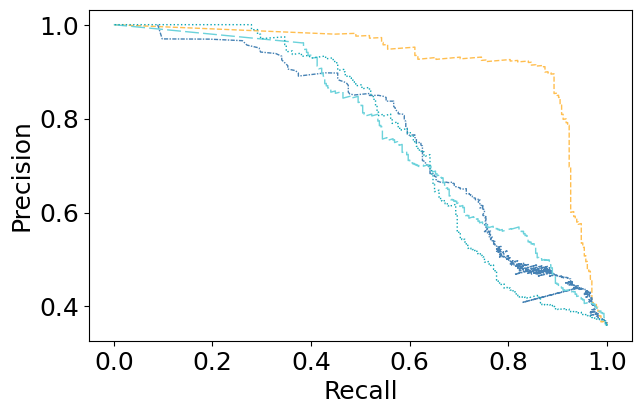

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


# Example: true labels and predicted scores
y_true = retest_pred.groundtruth_label
y_scores =retest_pred.outputs  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_spark, recall_spark, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_spark = average_precision_score(y_true, y_scores)
print('AUPRC for SPARK:', auprc_spark)
# Compute the precision-recall pairs
precision_achievable = retest_final_metrics['tp'] / (retest_final_metrics['tp'] + retest_final_metrics['fp'])
recall_achievable = retest_final_metrics['tp']/ (retest_final_metrics['tp'] + retest_final_metrics['fn'])
sorted_indices = np.argsort(recall_achievable.values)
sorted_recalls = recall_achievable.values[sorted_indices]
sorted_precisions = precision_achievable.values[sorted_indices]
auprc_achievable = auc(sorted_recalls, sorted_precisions)
print('AUPRC for threshold rules:', auprc_achievable)

y_true = qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].groundtruth_label
y_scores = qpcr_retest_pred[~qpcr_retest_pred.prob.isna()].prob  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_qpcr, recall_qpcr, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_qpcr = average_precision_score(y_true, y_scores)
print('AUPRC for qpcr:', auprc_qpcr)

y_true = retest_qpcrdeepnet.groundtruth_label
y_scores = retest_qpcrdeepnet.prob  # Usually predicted probabilities
# Compute the precision-recall pairs
precision_deepnet, recall_deepnet, _ = precision_recall_curve(y_true, y_scores)
# Compute AUPRC
auprc_deepnet = average_precision_score(y_true, y_scores)
print('AUPRC for deepnet:', auprc_deepnet)

# Plot the curve
fig, ax = plt.subplots(figsize=(7,4.3))
ax.plot(recall_spark, precision_spark, label=r'$\bf{SPARK}$',
        linewidth=1, linestyle=linestyle_map.get('fusion'),
        color=color_map.get('fusion'))
ax.plot(recall_achievable, precision_achievable, label='Threshold rules',
        linewidth=1, linestyle=linestyle_map.get('achievable'),
        color=color_map.get('achievable'))
ax.plot(recall_qpcr, precision_qpcr, label='qpcR',
        linewidth=1, linestyle=linestyle_map.get('qpcr'),
        color=color_map.get('qpcr'))
ax.plot(recall_deepnet, precision_deepnet, label='qPCRdeepNet',
        linewidth=1, linestyle=linestyle_map.get('deepnet'),
        color=color_map.get('deepnet'))
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# axins = inset_axes(ax, width="62%", height="62%", 
#                    bbox_to_anchor=(-0.3, 0.078, 1.06, 1.06),  # (x0, y0, width, height) in axes fraction
#                    bbox_transform=ax.transAxes, 
#                    loc="lower right", borderpad=0)
# mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.5")
# axins.plot(recall_spark, precision_spark, label=r'$\bf{SPARK}$',
#         linestyle=linestyle_map.get('fusion'),
#         color=color_map.get('fusion'))
# axins.plot(recall_achievable, precision_achievable, label='Threshold rules',
#         linestyle=linestyle_map.get('achievable'),
#         color=color_map.get('achievable'))
# axins.plot(recall_qpcr, precision_qpcr, label='qpcR',
#         linestyle=linestyle_map.get('qpcr'),
#         color=color_map.get('qpcr'))
# axins.plot(recall_deepnet, precision_deepnet, label='qPCRdeepNet',
#         linestyle=linestyle_map.get('deepnet'),
#         color=color_map.get('deepnet'))
# axins.set_xlim([0.9,1.0])
# axins.set_ylim([0.99,1.002])

ax.set_xlabel("Recall", fontsize=18)
ax.set_ylabel("Precision", fontsize=18)
# ax.set_title("Precision-Recall Curve", fontsize=18)
# plt.legend()
plt.show()


### Retest Brier Score

In [217]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(retest_pred.groundtruth_label, retest_pred.outputs)
print('Brier score for SPARK:', brier_score)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
print(f'Accuracy: {accuracy_score(retest_pred.groundtruth_label, retest_pred.pred)}')
print(f'AUC: {roc_auc_score(retest_pred.groundtruth_label, retest_pred.outputs)}')
print(f'AUPRC: {average_precision_score(retest_pred.groundtruth_label, retest_pred.outputs)}')
print('\n')

brier_score = brier_score_loss(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)
print('Brier score for IGI:', brier_score)
tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.encoded_igi_call).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
print(f'Accuracy: {accuracy_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)}')
print(f'AUC: {roc_auc_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)}')
print(f'AUPRC: {average_precision_score(retest_pred.groundtruth_label, retest_pred.encoded_igi_call)}')
print('\n')

brier_score = brier_score_loss(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.fillna(0).prob)
print('Brier score for qPCR:', brier_score)
qpcr_retest_pred['pred'] = 1*(qpcr_retest_pred.prob >= qpcr_best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
print(f'Accuracy: {accuracy_score(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.pred)}')
print(f'AUC: {roc_auc_score(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.prob.fillna(0))}')
print(f'AUPRC: {average_precision_score(qpcr_retest_pred.groundtruth_label, qpcr_retest_pred.prob.fillna(0))}')
print('\n')

brier_score = brier_score_loss(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.fillna(0).prob)
print('Brier score for qPCR:', brier_score)
retest_qpcrdeepnet['pred'] = 1*(retest_qpcrdeepnet.prob >= deepnet_best_acc_threshold)
tn, fp, fn, tp = confusion_matrix(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred).ravel()
print(f'FNR: {fn/(fn+tp)} - FPR: {fp/(fp+tn)}')
print(f'Accuracy: {accuracy_score(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.pred)}')
print(f'AUC: {roc_auc_score(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.prob)}')
print(f'AUPRC: {average_precision_score(retest_qpcrdeepnet.groundtruth_label, retest_qpcrdeepnet.prob)}')
print('\n')


Brier score for SPARK: 0.07117661774234009
FNR: 0.1441717791411043 - FPR: 0.04655172413793104
Accuracy: 0.9183222958057395
AUC: 0.9360006346519991
AUPRC: 0.9190168310685183


Brier score for IGI: 0.23509933774834438
FNR: 0.36809815950920244 - FPR: 0.16034482758620688
Accuracy: 0.7649006622516556
AUC: 0.7357785064522951
AUPRC: 0.5678074519990863


Brier score for qPCR: 0.20511594068795078
FNR: 0.3343558282208589 - FPR: 0.1810344827586207
Accuracy: 0.7637969094922737
AUC: 0.814655172413793
AUPRC: 0.7668839904494167


Brier score for qPCR: 0.280488059208501
FNR: 0.34049079754601225 - FPR: 0.21379310344827587
Accuracy: 0.7406181015452539
AUC: 0.7743706367675058
AUPRC: 0.7648425639080368




# Retest calibration

In [79]:
import statsmodels.api as sm
retest_pred = retest_pred.merge(join_df[['sample_id','current_sample_result','final_patient_result']].drop_duplicates(), on='sample_id')
retest_pred['sample_groundtruth'] = 1*(retest_pred.final_patient_result == 'Positive')
df3 = retest_pred[~retest_pred.target.isin(['MS2','RnaseP'])].groupby(['sample_id','sample_groundtruth']).outputs.agg(['mean','var']).reset_index()
X = df3[df3.columns.drop(['sample_id','sample_groundtruth'])]
X = sm.add_constant(X)
y = df3['sample_groundtruth'].values


model3 = sm.OLS(y,X).fit()
print(model3.summary())
df3['regress_prob'] = model3.predict(X)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     31.15
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           6.45e-13
Time:                        07:48:13   Log-Likelihood:                -13.352
No. Observations:                 277   AIC:                             32.70
Df Residuals:                     274   BIC:                             43.58
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0478      0.017      2.855      0.0

In [80]:
df3['pred'] = 1*(df3['regress_prob'] >= 0.5)

In [81]:
tn, fp, fn, tp = confusion_matrix(df3.sample_groundtruth, df3.pred, labels=np.array([0,1])).ravel()
print(f'FPR: {fp/(fp + tn)} - FNR: {fn/(fn + tp)}')

FPR: 0.007905138339920948 - FNR: 0.75


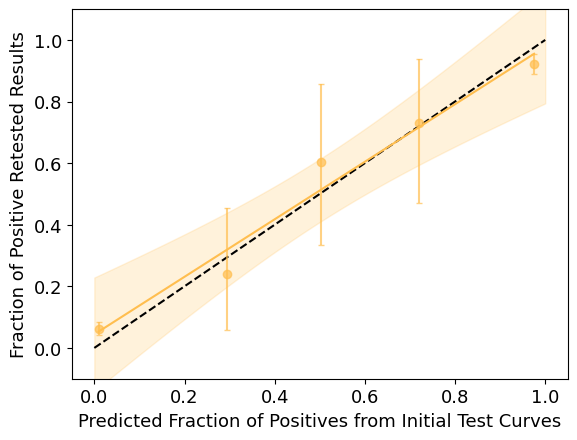

In [84]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import linregress, t
import matplotlib.pyplot as plt

def bootstrap_calibration(y_true, y_prob, n_bins=10, n_bootstrap=1000):
    prob_true_list = []
    
    for _ in range(n_bootstrap):
        flag = True
        while flag:
            indices = resample(range(len(y_true)), replace=True)  # Bootstrap sample
            y_true_boot = y_true[indices]
            y_prob_boot = y_prob[indices]
        
            prob_true, prob_pred = calibration_curve(y_true_boot, y_prob_boot, n_bins=n_bins)
            if np.isnan(prob_pred).sum() == 0:
                flag = False
        if len(prob_true) < n_bins:
            prob_true = np.concatenate([prob_true, np.full(n_bins - len(prob_true), 0)])
        prob_true_list.append(prob_true)
    
    prob_true_array = np.vstack(prob_true_list)
    lower = np.percentile(prob_true_array, 2.5, axis=0)
    upper = np.percentile(prob_true_array, 97.5, axis=0)
    
    return prob_pred, prob_true_array.mean(axis=0), lower, upper

# Example usage
# retest_pred.groundtruth_label, retest_pred.outputs
y_true = retest_pred.groundtruth_label.values  # Binary labels
y_prob = retest_pred.outputs.values  # Model probabilities

prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression 
# line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting
plt.rcParams.update({'font.size': 13})  # 2:1 height ratio
# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('fusion'), 
         label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('fusion'), alpha=0.2, label="95% CI (Regression)")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('fusion'), 
             alpha=0.7, capsize=2, label="95% CI (Calibration)")
plt.xlabel("Predicted Fraction of Positives from Initial Test Curves", fontsize=13)
plt.ylabel("Fraction of Positive Retested Results", fontsize=13)
plt.ylim(-0.1,1.1)
# plt.legend(loc='lower center', fontsize=20, ncol = 5, bbox_to_anchor=(0.5,-0.5))
plt.show()


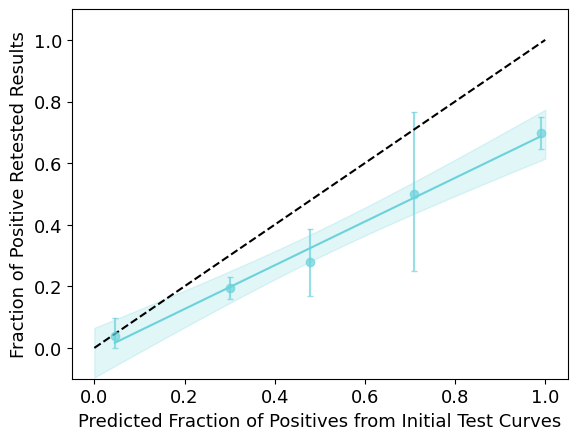

In [86]:
y_true = qpcr_retest_pred.groundtruth_label.values  # Binary labels
y_prob = qpcr_retest_pred.prob.values  # Model probabilities

prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('qpcr'), alpha=0.7, capsize=2)
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('qpcr'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('qpcr'), alpha=0.2, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positives from Initial Test Curves")
plt.ylabel("Fraction of Positive Retested Results")
plt.ylim(-0.1, 1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

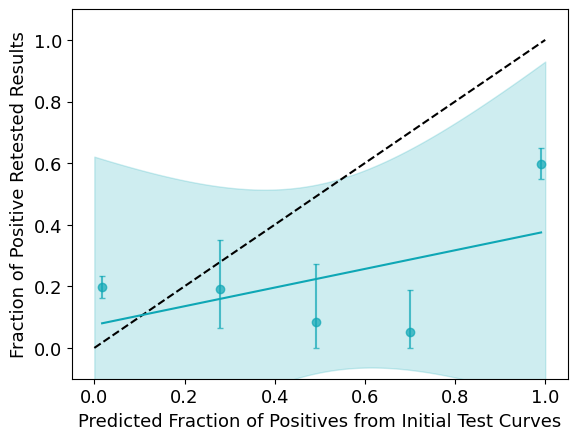

In [87]:
y_true = retest_qpcrdeepnet.groundtruth_label.values  # Binary labels
y_prob = retest_qpcrdeepnet.prob.values  # Model probabilities


prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")

plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('deepnet'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('deepnet'), alpha=0.2, label="95% CI (Regression)")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('deepnet'), alpha=0.7, capsize=2)

plt.xlabel("Predicted Fraction of Positives from Initial Test Curves")
plt.ylabel("Fraction of Positive Retested Results")
plt.ylim(-0.1, 1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

/tmp/ipykernel_1308378/1259153347.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))


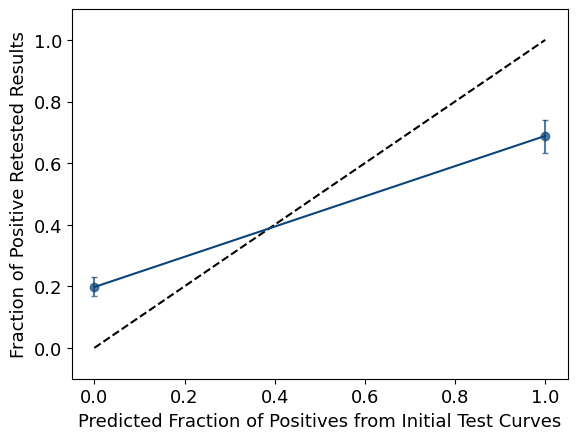

In [88]:
y_true = retest_pred.groundtruth_label.values  # Binary labels
y_prob = retest_pred.encoded_igi_call.values  # Model probabilities


prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=2)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('igi'), alpha=0.7, capsize=2)
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('igi'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('igi'), alpha=0.2, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positives from Initial Test Curves")
plt.ylabel("Fraction of Positive Retested Results")
plt.ylim(-0.1, 1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

# Binomial proportion confidence intervals for IGI FPR and FNR

## 95% CI of Expert Judgement on Test set

In [225]:
from statsmodels.stats.proportion import proportion_confint

tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
igi_fpr = fp/(fp + tn)
igi_fnr = fn/(fn + tp)
n = test_pred.shape[0]

# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fp, fp+tn, alpha=0.05, method='beta')

print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")


# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fn, fn+tp, alpha=0.05, method='beta')

print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")


False Positive Rate: 0.0000
95% CI: (0.0000, 0.0060)
False Negative Rate: 0.0435
95% CI: (0.0383, 0.0492)


## 95% CI of best achievable threshold at true pos frac on test set

In [226]:
print(f'True positive frac on test set: {true_pos_frac}')
perc, cycle = final_thres_df[(final_thres_df.pos_pred >= true_pos_frac - 0.0001) & (final_thres_df.pos_pred <= true_pos_frac + 0.0001)].sort_values('fnr').head(1)[['perc','cycle']].values[0]
print('fn change:', perc, 'cycle_change:', cycle)

df = full_test_pred.copy()
df['cq_new'] = df.cq_new.fillna(20)
df['new_threshold'] = full_test_pred.threshold * (1 + perc)

df['if_pass'] = df.drn >= df.new_threshold
# passed_ids = df[df.if_pass].curve_idx.unique()

pass_ct = df[(df.if_pass)& (df.cycle_no >= 15)] \
    .groupby('curve_idx').cycle_no.min().reset_index()
pass_ct.columns = ['curve_idx', 'new_ct']
df = df.merge(pass_ct, how='left', on='curve_idx')
df['new_ct'] = df['new_ct'].fillna(np.Inf)

fake_df = df[(df.cycle_no >= df.new_ct)] \
    .sort_values(['curve_idx','cycle_no']) \
    .groupby('curve_idx').tail(5) \
    .groupby('curve_idx').if_pass.all().reset_index()
fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

df['new_igi_call'] = 1*((df.new_ct <= (df.cq_new.astype(float) + cycle)))
# df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0

df_1 = df[df.cycle_no == 1]
tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
expert_pos_pred = (fp+tp)/(fp+tp+tn+fn)
expert_fnr = fn/(fn+tp)
expert_fpr = fp/(fp+tn)
print(f'At true positive fraction, best achievable FNR: {expert_fnr} - FPR: {expert_fpr}')

True positive frac on test set: 0.8986530880420499
fn change: -0.9520000000001594 cycle_change: -1.0
At true positive fraction, best achievable FNR: 0.025041125936757447 - FPR: 0.22204213938411668


In [227]:
from statsmodels.stats.proportion import proportion_confint


tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call).ravel()
igi_fpr = fp/(fp + tn)
igi_fnr = fn/(fn + tp)
n = test_pred.shape[0]

# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fp, fp+tn, alpha=0.05, method='beta')

print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")


# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fn, fn+tp, alpha=0.05, method='beta')

print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")

False Positive Rate: 0.2220
95% CI: (0.1898, 0.2569)
False Negative Rate: 0.0250
95% CI: (0.0211, 0.0295)


## 95% CI of SPARK at 1% FNR on test set

In [228]:
model_dict_df[(model_dict_df.fnr <= 0.0101)].sort_values('fnr', ascending=False).head(3)

,thres,acc,fnr,fpr,pos_frac
660,0.660,0.986531,0.010053,0.043760,0.894054
659,0.659,0.986531,0.010053,0.043760,0.894054
650,0.650,0.986531,0.009870,0.045381,0.894382


In [229]:
from sklearn.utils import resample
test_pred['pred'] = test_pred.outputs >= 0.659

def compute_fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else np.nan

def compute_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

n_bootstraps = 1000
fpr_scores, fnr_scores = [], []

np.random.seed(10)
for _ in range(n_bootstraps):
    # Resample rows with replacement
    sample = resample(test_pred.sample_id.unique(), replace=True, n_samples=test_pred.sample_id.nunique())
    df = test_pred[test_pred.sample_id.isin(sample)].copy()
    y_true_sample, y_pred_sample = df['groundtruth_label'], df['pred']
    
    fnr = compute_fnr(y_true_sample, y_pred_sample)
    fpr = compute_fpr(y_true_sample, y_pred_sample)
    if not np.isnan(fnr):
        fnr_scores.append(fnr)
        fpr_scores.append(fpr)

# Convert to numpy array
fnr_scores = np.array(fnr_scores)
fpr_scores = np.array(fpr_scores)

# 95% CI (can change alpha as needed)
alpha = 0.05
lower = np.percentile(fnr_scores, 100 * (alpha / 2))
upper = np.percentile(fnr_scores, 100 * (1 - alpha / 2))

print(f"Bootstrap FNR 95% CI: ({lower:.4f}, {upper:.4f})")

lower = np.percentile(fpr_scores, 100 * (alpha / 2))
upper = np.percentile(fpr_scores, 100 * (1 - alpha / 2))

print(f"Bootstrap FPR 95% CI: ({lower:.4f}, {upper:.4f})")

Bootstrap FNR 95% CI: (0.0081, 0.0122)
Bootstrap FPR 95% CI: (0.0305, 0.0553)


In [230]:
test_pred['pred'] = test_pred.outputs >= 0.659
tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
igi_fpr = fp/(fp + tn)
igi_fnr = fn/(fn + tp)
n = test_pred.shape[0]

# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fp, fp+tn, alpha=0.05, method='beta')

print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")


# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fn, fn+tp, alpha=0.05, method='beta')

print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")

False Positive Rate: 0.0438
95% CI: (0.0290, 0.0630)
False Negative Rate: 0.0101
95% CI: (0.0076, 0.0131)


## 95% CI FNR, FPR on Retest set

In [231]:
from statsmodels.stats.proportion import proportion_confint
model_true_posfrac_threshold = retest_model_dict_df[retest_model_dict_df.pos_frac == true_retest_pos_frac].thres.values[0]
retest_pred['pred'] = 1*(retest_pred.outputs >= model_true_posfrac_threshold)
tn, fp, fn, tp = confusion_matrix(retest_pred.groundtruth_label, retest_pred.pred, labels=np.array([0,1])).ravel()
# igi_fpr = fp/(fp + tn)
# igi_fnr = fn/(fn + tp)

# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fp, fp+tn, alpha=0.05, method='beta')

print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")

False Positive Rate: 0.0603
95% CI: (0.0424, 0.0829)


In [232]:

# 95% CI using Clopper-Pearson (exact)
ci_low, ci_high = proportion_confint(fn, fn+tp, alpha=0.05, method='beta')

print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print(f"95% CI: ({ci_low:.4f}, {ci_high:.4f})")

False Negative Rate: 0.1074
95% CI: (0.0759, 0.1461)


In [233]:
from sklearn.utils import resample
model_true_posfrac_threshold = retest_model_dict_df[retest_model_dict_df.pos_frac == true_retest_pos_frac].thres.values[0]
retest_pred['pred'] = 1*(retest_pred.outputs >= model_true_posfrac_threshold)

def compute_fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else np.nan

def compute_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

n_bootstraps = 1000
fpr_scores, fnr_scores = [], []


for _ in range(n_bootstraps):
    # Resample rows with replacement
    sample = resample(retest_pred.sample_id.unique(), replace=True, n_samples=retest_pred.sample_id.nunique())
    df = retest_pred[retest_pred.sample_id.isin(sample)].copy()
    y_true_sample, y_pred_sample = df['groundtruth_label'], df['pred']
    
    fnr = compute_fnr(y_true_sample, y_pred_sample)
    fpr = compute_fpr(y_true_sample, y_pred_sample)
    if not np.isnan(fnr):
        fnr_scores.append(fnr)
        fpr_scores.append(fpr)

# Convert to numpy array
fnr_scores = np.array(fnr_scores)
fpr_scores = np.array(fpr_scores)

# 95% CI (can change alpha as needed)
alpha = 0.05
lower = np.percentile(fnr_scores, 100 * (alpha / 2))
upper = np.percentile(fnr_scores, 100 * (1 - alpha / 2))

print(f"Bootstrap FNR 95% CI: ({lower:.4f}, {upper:.4f})")

lower = np.percentile(fpr_scores, 100 * (alpha / 2))
upper = np.percentile(fpr_scores, 100 * (1 - alpha / 2))

print(f"Bootstrap FPR 95% CI: ({lower:.4f}, {upper:.4f})")

Bootstrap FNR 95% CI: (0.0732, 0.1362)
Bootstrap FPR 95% CI: (0.0461, 0.0753)


In [273]:
retest_final_thres_df[(retest_final_thres_df.pos_pred > true_retest_pos_frac - 0.0002) & (retest_final_thres_df.pos_pred < true_retest_pos_frac + 0.0002)].sort_values(['fnr','fpr']).head(1)

,fpr,fnr,pos_pred,perc,cycle,fpr_type,fnr_type,diff,accuracy,tpr
216093,0.189655,0.337423,0.36,-0.598,3,simulated,simulated,0.0,0.677553,0.662577


In [ ]:
0.337423 - 0.107, 0.189655 - 6.03

(0.230423, -5.840345)

## Hypothesis testing for FNR

In [234]:
def mcnemar_test(n00, n01, n10, n11, continuity_correction=True):
    """
    Performs McNemar's test given the four counts from a 2×2 table.
    
    Parameters:
    -----------
    n00 : int
        Count of subjects missed by both conditions.
    n01 : int
        Count of subjects missed by condition A only.
    n10 : int
        Count of subjects missed by condition B only.
    n11 : int
        Count of subjects detected by both conditions.
    continuity_correction : bool
        If True, applies the continuity correction (the -1 in the numerator).

    Returns:
    --------
    chi2_stat : float
        McNemar's chi-squared statistic (with 1 degree of freedom).
    p_value : float
        Two-sided p-value for the test.
    """
    import math
    from math import comb
    import numpy as np
    from scipy.stats import chi2
    
    # n01 = (# missed by A, detected by B)
    # n10 = (# detected by A, missed by B)
    
    # The typical McNemar's chi-square statistic:
    # chi2 = (|n01 - n10| - correction)^2 / (n01 + n10)
    #   correction is usually 1 if continuity_correction is True, else 0.
    
    diff = abs(n01 - n10)
    if continuity_correction and diff > 0:
        diff = diff - 1

    chi2_stat = (diff**2) / float(n01 + n10)
    
    # Under the null, this statistic ~ chi-square(df=1)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
    
    return chi2_stat, p_value



In [235]:
perc = -0.952
cycle = -1
df = full_test_pred.copy()
df['cq_new'] = df.cq_new.fillna(20)
df['new_threshold'] = full_test_pred.threshold * (1 + perc)

df['if_pass'] = df.drn >= df.new_threshold
# passed_ids = df[df.if_pass].curve_idx.unique()

pass_ct = df[(df.if_pass)& (df.cycle_no >= 15)] \
    .groupby('curve_idx').cycle_no.min().reset_index()
pass_ct.columns = ['curve_idx', 'new_ct']
df = df.merge(pass_ct, how='left', on='curve_idx')
df['new_ct'] = df['new_ct'].fillna(np.Inf)

# fake_df = df[(df.cycle_no >= df.new_ct)] \
#     .sort_values(['curve_idx','cycle_no']) \
#     .groupby('curve_idx').tail(5) \
#     .groupby('curve_idx').if_pass.all().reset_index()
# fake_ids = fake_df[~fake_df.if_pass].curve_idx.unique()

df['new_igi_call'] = 1*((df.new_ct <= (df.cq_new.astype(float) + cycle)))
# df.loc[df.curve_idx.isin(fake_ids), 'new_igi_call'] = 0

df_1 = df[df.cycle_no == 1]
tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()

print('FPR:', fp/(fp + tn), 'FNR:', fn/(fn + tp), 'Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

FPR: 0.22204213938411668 FNR: 0.025041125936757447 Pos Pred: 0.8986530880420499


In [236]:
from statsmodels.stats.contingency_tables import mcnemar

model_thres = model_dict_df[model_dict_df.pos_frac == true_pos_frac].thres.values[0]
test_pred['pred'] = 1*(test_pred.outputs >= model_thres)
full_df = test_pred.merge(df_1[['curve_idx','new_igi_call']], on='curve_idx')

tn, fp, fn, tp = confusion_matrix(full_df.groundtruth_label, full_df.new_igi_call, labels=np.array([0,1])).ravel()
print('Achievable FPR:', fp/(fp + tn), 'Achievable FNR:', fn/(fn + tp), 'Achievable Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

tn, fp, fn, tp = confusion_matrix(full_df.groundtruth_label, full_df.pred, labels=np.array([0,1])).ravel()
print('SPARK FPR:', fp/(fp + tn), 'SPARK FNR:', fn/(fn + tp), 'SPARK Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

n00 = full_df[(full_df.pred == full_df.new_igi_call) & (full_df.pred == 1) & (full_df.pred != full_df.groundtruth_label)].shape[0]
n01 = full_df[(full_df.pred == 0) & (full_df.new_igi_call == 1)  & (full_df.groundtruth_label != full_df.pred)].shape[0]
n10 = full_df[(full_df.pred == 1) & (full_df.new_igi_call == 0)  & (full_df.groundtruth_label == full_df.pred)].shape[0]
n11 = full_df[(full_df.pred == 0) & (full_df.new_igi_call == full_df.pred) & (full_df.groundtruth_label == full_df.pred)].shape[0]
table = np.array([[n00, n01], [n10, n11]])
print(f"Contingency Table:\n{table}")
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FNR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue}")

n00 = test_pred[(test_pred.pred == test_pred.encoded_igi_call) & (test_pred.pred == 0) & (test_pred.pred != test_pred.groundtruth_label)].shape[0]
n01 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == 0)  & (test_pred.groundtruth_label != test_pred.pred)].shape[0]
n10 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == 1)  & (test_pred.groundtruth_label == test_pred.pred)].shape[0]
n11 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == test_pred.pred) & (test_pred.groundtruth_label == test_pred.pred)].shape[0]

table = np.array([[n00, n01], [n10, n11]])
print(f"Contingency Table:\n{table}")
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FPR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue:.5f}")

Achievable FPR: 0.22204213938411668 Achievable FNR: 0.025041125936757447 Achievable Pos Pred: 0.8986530880420499
SPARK FPR: 0.06807131280388978 SPARK FNR: 0.007676841528057028 SPARK Pos Pred: 0.8986530880420499
Contingency Table:
[[ 19  19]
 [114 457]]
McNemar's FNR test statistic: 66.436
p-value: 3.6142381439567537e-16
Contingency Table:
[[  38   42]
 [   0 5229]]
McNemar's FPR test statistic: 40.024
p-value: 0.00000


In [237]:
from statsmodels.stats.contingency_tables import mcnemar

model_thres = model_dict_df[model_dict_df.pos_frac == true_pos_frac].thres.values[0]
print('model thres:', model_thres)
test_pred['pred'] = 1*(test_pred.outputs >= model_thres)

tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
print('IGI FPR:', fp/(fp + tn), 'IGI FNR:', fn/(fn + tp), 'IGI Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
print('SPARK FPR:', fp/(fp + tn), 'SPARK FNR:', fn/(fn + tp), 'SPARK Pos Pred:', (fp+tp)/(fp+tp+tn+fn))


n00 = test_pred[(test_pred.pred == test_pred.encoded_igi_call) & (test_pred.pred == 1) & (test_pred.pred != test_pred.groundtruth_label)].shape[0]
n01 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == 1)  & (test_pred.groundtruth_label != test_pred.pred)].shape[0]
n10 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == 0)  & (test_pred.groundtruth_label == test_pred.pred)].shape[0]
n11 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == test_pred.pred) & (test_pred.groundtruth_label == test_pred.pred)].shape[0]

table = np.array([[n00, n01], [n10, n11]])

result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FNR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue:.5f}")

model thres: 0.541
IGI FPR: 0.0 IGI FNR: 0.043502101992323156 IGI Pos Pred: 0.8595597897503285
SPARK FPR: 0.06807131280388978 SPARK FNR: 0.007676841528057028 SPARK Pos Pred: 0.8986530880420499
McNemar's FNR test statistic: 186.397
p-value: 0.00000


In [238]:
from statsmodels.stats.contingency_tables import mcnemar
print('IGI pos frac:', true_pos_frac)
model_thres = model_dict_df[model_dict_df.pos_frac == igi_pos_frac].thres.values[0]
test_pred['pred'] = 1*(test_pred.outputs >= model_thres)
tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.encoded_igi_call, labels=np.array([0,1])).ravel()
print('IGI FPR:', fp/(fp + tn), 'IGI FNR:', fn/(fn + tp), 'IGI Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
print('SPARK FPR:', fp/(fp + tn), 'SPARK FNR:', fn/(fn + tp), 'SPARK Pos Pred:', (fp+tp)/(fp+tp+tn+fn))

n00 = test_pred[(test_pred.pred == test_pred.encoded_igi_call) & (test_pred.pred == 1) & (test_pred.pred != test_pred.groundtruth_label)].shape[0]
n01 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == 1)  & (test_pred.groundtruth_label != test_pred.pred)].shape[0]
n10 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == 0)  & (test_pred.groundtruth_label == test_pred.pred)].shape[0]
n11 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == test_pred.pred) & (test_pred.groundtruth_label == test_pred.pred)].shape[0]

table = np.array([[n00, n01], [n10, n11]])
print(table)
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FNR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue}")


n00 = test_pred[(test_pred.pred == test_pred.encoded_igi_call) & (test_pred.pred == 0) & (test_pred.pred != test_pred.groundtruth_label)].shape[0]
n01 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == 0)  & (test_pred.groundtruth_label != test_pred.pred)].shape[0]
n10 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == 1)  & (test_pred.groundtruth_label == test_pred.pred)].shape[0]
n11 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == test_pred.pred) & (test_pred.groundtruth_label == test_pred.pred)].shape[0]

table = np.array([[n00, n01], [n10, n11]])
print(table)
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FPR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue}")

IGI pos frac: 0.8986530880420499
IGI FPR: 0.0 IGI FNR: 0.043502101992323156 IGI Pos Pred: 0.8595597897503285
SPARK FPR: 0.0016207455429497568 SPARK FNR: 0.043684883933467374 SPARK Pos Pred: 0.8595597897503285
[[  0  34]
 [ 33 616]]
McNemar's FNR test statistic: 0.000
p-value: 1.0
[[ 205    1]
 [   0 5199]]
McNemar's FPR test statistic: 0.000
p-value: 1.0


In [239]:
# Only include true negatives (where groundtruth is 0)
tn_cases = test_pred[test_pred.groundtruth_label == 0]

# Predictions of both models
a = tn_cases.pred
b = tn_cases.encoded_igi_call

# Build confusion:
# b = A correct (0), B wrong (1)
# c = A wrong (1), B correct (0)
b_count = ((a == 0) & (b == 1)).sum()  # A correct, B wrong
c_count = ((a == 1) & (b == 0)).sum()  # A wrong, B correct

table = [[0, b_count],
         [c_count, 0]]
print(table)
from statsmodels.stats.contingency_tables import mcnemar
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's FPR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue}")


[[0, 0], [1, 0]]
McNemar's FPR test statistic: 0.000
p-value: 1.0


In [240]:
# 1. Filter to actual positives (ground truth = 1)
pos_cases = test_pred[test_pred.groundtruth_label == 1]

# 2. Get predictions
a = pos_cases.pred
b = pos_cases.encoded_igi_call

# 3. Count disagreements on FNs
# False negatives: model predicts 0 when truth is 1

# b: A correct (1), B wrong (0)
b_count = ((a == 1) & (b == 0)).sum()

# c: A wrong (0), B correct (1)
c_count = ((a == 0) & (b == 1)).sum()

# 4. Build McNemar's table
table = [[0, b_count],
         [c_count, 0]]
print(table)
# 5. Run McNemar's test
result = mcnemar(table, exact=False, correction=False)

print(f"McNemar's FNR test statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue}")

[[0, 33], [34, 0]]
McNemar's FNR test statistic: 0.015
p-value: 0.9027648250246224


In [241]:
n00 = test_pred[(test_pred.pred == test_pred.encoded_igi_call) & (test_pred.pred == 1) & (test_pred.pred != test_pred.groundtruth_label)].shape[0]
n01 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == 1)  & (test_pred.groundtruth_label != test_pred.pred)].shape[0]
n10 = test_pred[(test_pred.pred == 1) & (test_pred.encoded_igi_call == 0)  & (test_pred.groundtruth_label == test_pred.pred)].shape[0]
n11 = test_pred[(test_pred.pred == 0) & (test_pred.encoded_igi_call == test_pred.pred) & (test_pred.groundtruth_label == test_pred.pred)].shape[0]

table = np.array([[n00, n01], [n10, n11]])
table

array([[  0,  34],
       [ 33, 616]])

## Hypothesis testing for SPARK and Expert Judgement AUC

In [242]:
from MLstatkit.stats import Delong_test
spark_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.outputs)
expert_auc = roc_auc_score(test_pred.groundtruth_label, test_pred.encoded_igi_call)
z_score, p_value = Delong_test(test_pred.groundtruth_label, test_pred.outputs, test_pred.encoded_igi_call)


print(f"SPARK AUC: {spark_auc:.3f}")
print(f"Expert AUC: {expert_auc:.3f}")
print(f"Z-Score: {z_score:.3f}")
print(f"P-Value: {p_value:.4f}")


SPARK AUC: 0.998
Expert AUC: 0.978
Z-Score: -15.046
P-Value: 0.0000


## Groundtruth dataset overview

In [243]:
print(groundtruth_df.shape)
print(groundtruth_df['groundtruth_target'].value_counts())
print(groundtruth_df[groundtruth_df.groundtruth_target == 0].sample_type.value_counts())

(24756, 15)
groundtruth_target
1    22199
0     2557
Name: count, dtype: int64
sample_type
Negative Control (qPCR)                       1540
Human Normal Negative Control (Extraction)     548
Positive Control (qPCR)                        469
Name: count, dtype: int64


# Confusion matrix on clinical samples

In [244]:
join_df[join_df.sample_type == 'Clinical Sample'][join_df.cycle_no == 1][~join_df.target.isin(['MS2','RnaseP'])][['sample_id','final_patient_result']].drop_duplicates().final_patient_result.value_counts()

/tmp/ipykernel_1355909/2638587790.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  join_df[join_df.sample_type == 'Clinical Sample'][join_df.cycle_no == 1][~join_df.target.isin(['MS2','RnaseP'])][['sample_id','final_patient_result']].drop_duplicates().final_patient_result.value_counts()
/tmp/ipykernel_1355909/2638587790.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  join_df[join_df.sample_type == 'Clinical Sample'][join_df.cycle_no == 1][~join_df.target.isin(['MS2','RnaseP'])][['sample_id','final_patient_result']].drop_duplicates().final_patient_result.value_counts()


final_patient_result
Negative    17635
Positive     1766
ReSample     1173
Name: count, dtype: int64

In [245]:
clinical_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_clinical_pred_df.csv'))
print(clinical_pred.shape)
clinical_pred = clinical_pred.merge(join_df.loc[join_df.cycle_no == 1]
                                    .loc[join_df.sample_type == 'Clinical Sample']
                                    # .loc[join_df.retest_sample_id_1 == ' ']
                                    # .loc[join_df.final_patient_result.isin(['Negative','Positive'])]
                                    .loc[~join_df.target.isin(['MS2','RnaseP'])]
                                    .loc[join_df.current_sample_result.isin(['Negative','Positive'])], 
                                    on='curve_idx')
print(clinical_pred.shape)

(63677, 3)
(41212, 29)


In [246]:
clinical_pred.groupby('final_patient_result').sample_id.nunique()

final_patient_result
Negative    16470
Positive     1628
ReSample        2
Name: sample_id, dtype: int64

In [247]:
clinical_pred['pred'] = 1*(clinical_pred.outputs >= best_acc_threshold)
clinical_sample_pred = clinical_pred.groupby(['sample_id','final_patient_result']).pred.mean().reset_index()
clinical_sample_pred['sample_pred'] = 1*(clinical_sample_pred.pred >= 0.5)
clinical_sample_pred['encoded_patient_result'] = 1*(clinical_sample_pred.final_patient_result == 'Positive')

Text(0.5, 0, 'SPARK')

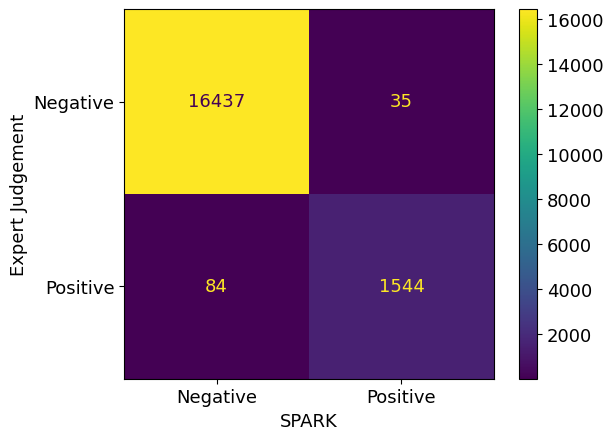

In [248]:

ConfusionMatrixDisplay(confusion_matrix(clinical_sample_pred.encoded_patient_result,
                                        clinical_sample_pred.sample_pred, 
                                        labels=np.array([0,1])),
                       display_labels=['Negative','Positive']).plot()
plt.ylabel('Expert Judgement')
plt.xlabel('SPARK')

In [249]:
35/(35 + 16437)

0.002124817872753764

# Calibration curves for test set

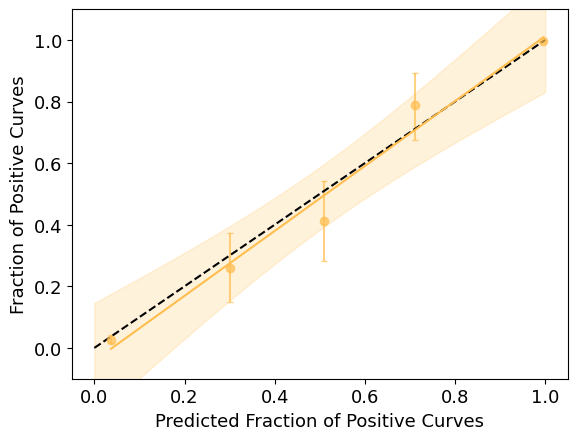

In [89]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import linregress, t
import matplotlib.pyplot as plt

def bootstrap_calibration(y_true, y_prob, n_bins=10, n_bootstrap=1000):
    prob_true_list = []
    
    for _ in range(n_bootstrap):
        flag = True
        while flag:
            indices = resample(range(len(y_true)), replace=True)  # Bootstrap sample
            y_true_boot = y_true[indices]
            y_prob_boot = y_prob[indices]
        
            prob_true, prob_pred = calibration_curve(y_true_boot, y_prob_boot, n_bins=n_bins)
            if np.isnan(prob_pred).sum() == 0:
                flag = False
        if len(prob_true) < n_bins:
            prob_true = np.concatenate([prob_true, np.full(n_bins - len(prob_true), 0)])
        prob_true_list.append(prob_true)
    
    prob_true_array = np.vstack(prob_true_list)
    lower = np.percentile(prob_true_array, 2.5, axis=0)
    upper = np.percentile(prob_true_array, 97.5, axis=0)
    
    return prob_pred, prob_true_array.mean(axis=0), lower, upper

# Example usage
# test_pred.groundtruth_label, test_pred.outputs
y_true = test_pred.groundtruth_label.values  # Binary labels
y_prob = test_pred.outputs.values  # Model probabilities

prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting
plt.rcParams.update({'font.size': 13})
# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('fusion'), alpha=0.7, capsize=2, label="95% CI (Calibration)")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('fusion'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('fusion'), alpha=0.2, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positive Curves", fontsize=13)
plt.ylabel("Fraction of Positive Curves",fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.ylim(-0.1, 1.1)
# plt.legend(loc='lower center', fontsize=13, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

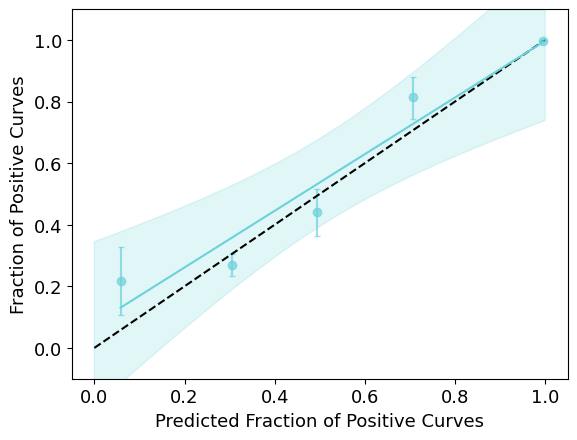

In [90]:
y_true = qpcr_test_pred[~qpcr_test_pred.prob.isna()].groundtruth_label.values  # Binary labels
y_prob = qpcr_test_pred[~qpcr_test_pred.prob.isna()].prob.values  # Model probabilities

prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('qpcr'), alpha=0.7, capsize=2)
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('qpcr'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('qpcr'), alpha=0.2, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positive Curves", fontsize=13)
plt.ylabel("Fraction of Positive Curves",fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.ylim(-0.1,1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

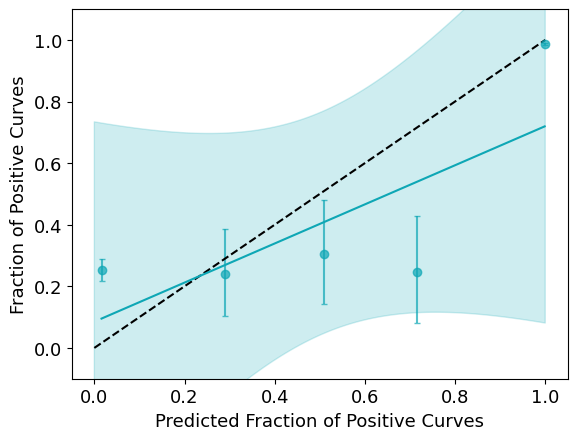

In [91]:
y_true = test_qpcrdeepnet.groundtruth_target.values  # Binary labels
y_prob = test_qpcrdeepnet.prob.values  # Model probabilities


prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=5)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('deepnet'), alpha=0.7, capsize=2)
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('deepnet'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color=color_map.get('deepnet'), alpha=0.2, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positive Curves", fontsize=13)
plt.ylabel("Fraction of Positive Curves",fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.ylim(-0.1,1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

/tmp/ipykernel_1355909/1364148696.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))


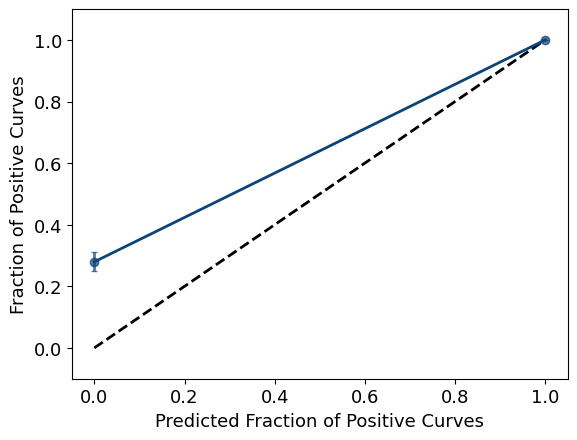

In [253]:
y_true = test_pred.groundtruth_label.values  # Binary labels
y_prob = test_pred.encoded_igi_call.values  # Model probabilities


prob_pred, prob_true_mean, lower_ci, upper_ci = bootstrap_calibration(y_true, y_prob, n_bins=2)
error_lower = np.abs(prob_true_mean - lower_ci)
error_upper = np.abs(upper_ci - prob_true_mean)


# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(prob_pred, prob_true_mean)
regression_line = slope * np.array(prob_pred) + intercept


# Generate regression line
x_fit = np.linspace(0, 1, 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval
t_value = t.ppf(0.975, df=len(prob_pred) - 2)  # 95% CI for two-tailed test
y_pred = slope * prob_pred + intercept
s_err = np.sqrt(np.sum((prob_true_mean - y_pred) ** 2) / (len(prob_pred) - 2))

delta = t_value * s_err * np.sqrt(1 / len(prob_pred) + (x_fit - np.mean(prob_pred))**2 / np.sum((prob_pred - np.mean(prob_pred))**2))
lower_reg = y_fit - delta
upper_reg = y_fit + delta

# Plotting

# plt.scatter(prob_pred, prob_true_mean, label="Mean Calibration")
# plt.fill_between(prob_pred, lower_ci, upper_ci, color='b', alpha=0.2, label="95% CI")
plt.errorbar(prob_pred, prob_true_mean, yerr=[error_lower, error_upper], fmt='o', color=color_map.get('igi'), alpha=0.7, capsize=2)
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.plot(prob_pred, regression_line, color_map.get('igi'), label="Linear Regression of Calibrated Points")  # Regression line
# plt.plot(x_fit, y_fit, 'r-', label="Linear Regression")  # Regression line
plt.fill_between(x_fit, lower_reg, upper_reg, color='mistyrose', alpha=1, label="95% CI (Regression)")

plt.xlabel("Predicted Fraction of Positive Curves", fontsize=13)
plt.ylabel("Fraction of Positive Curves",fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.ylim(-0.1, 1.1)
# plt.legend(loc='lower center', fontsize=10, ncol = 5, bbox_to_anchor=(0.5,-0.3))
plt.show()

### Brier Score for test set

In [254]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(test_pred.groundtruth_label, test_pred.outputs)
print('Brier score for SPARK:', brier_score)

brier_score = brier_score_loss(test_pred.groundtruth_label, test_pred.encoded_igi_call)
print('Brier score for IGI:', brier_score)

brier_score = brier_score_loss(qpcr_test_pred.groundtruth_label, qpcr_test_pred.fillna(0).prob)
print('Brier score for qPCR:', brier_score)

brier_score = brier_score_loss(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.fillna(0).prob)
print('Brier score for deepnet:', brier_score)

brier_score = prevalence*(1 - final_thres_df.pos_pred)**2 + (1 - prevalence)*(final_thres_df.pos_pred)**2
min_brier_score_idx = brier_score.idxmin()
print('Brier score for achievable:', brier_score[min_brier_score_idx])

Brier score for SPARK: 0.010382352636239715
Brier score for IGI: 0.039093298291721416
Brier score for qPCR: 0.03294465281186433
Brier score for deepnet: 0.040570140942672736
Brier score for achievable: 0.0910757153945376


### Adjust values to population prevalence

In [255]:
df = clinical_sample_pred[clinical_sample_pred.final_patient_result != 'ReSample'].drop_duplicates('sample_id')
print(df.final_patient_result.value_counts(normalize=True))
population_prevelance = df[df.final_patient_result == 'Positive'].shape[0]/df.shape[0]
print(f"Population Prevalence: {population_prevelance:.4f}")

final_patient_result
Negative    0.910045
Positive    0.089955
Name: proportion, dtype: float64
Population Prevalence: 0.0900


In [256]:
print('True Positive fraction:', true_pos_frac)
true_pos_achieveable = final_thres_df[(final_thres_df.pos_pred <= true_pos_frac + 0.0001) & (final_thres_df.pos_pred >= true_pos_frac - 0.0001)].sort_values(['pos_pred','fpr','fnr'])
print(f'achievable FPR: {true_pos_achieveable.fpr.values[0]:.4f} - Adjusted FPR: {(1 - population_prevelance)*true_pos_achieveable.fpr.values[0]:.4f}')
print(f'achievable FNR: {true_pos_achieveable.fnr.values[0]:.4f} - Adjusted FNR: {population_prevelance*true_pos_achieveable.fnr.values[0]:.4f}')

achievable_adj_acc = (1 - population_prevelance)*(1 - true_pos_achieveable.fpr.values[0]) + population_prevelance*(1 - true_pos_achieveable.fnr.values[0])
print(f'achievable accuracy: {true_pos_achieveable.accuracy.values[0]} - Adjusted achievable accuracy: {achievable_adj_acc}')


print(f'achievable Brier score: {prevalence*true_pos_achieveable.fnr.values[0] + (1 - prevalence)*(true_pos_achieveable.fpr.values[0])} - \
    Adj achievable Brier score: {population_prevelance*true_pos_achieveable.fnr.values[0] + (1 - population_prevelance)*(true_pos_achieveable.fpr.values[0])}')


True Positive fraction: 0.8986530880420499
achievable FPR: 0.2220 - Adjusted FPR: 0.2021
achievable FNR: 0.0250 - Adjusted FNR: 0.0023
achievable accuracy: 0.954993429697766 - Adjusted achievable accuracy: 0.7956790259320676
achievable Brier score: 0.04500657030223386 -     Adj achievable Brier score: 0.20432097406793245


In [257]:

model_thres = model_dict_df[(model_dict_df.pos_frac <= true_pos_frac + 0.0001) & (model_dict_df.pos_frac >= true_pos_frac - 0.0001)].thres.values[0]
test_pred['pred'] = 1*(test_pred.outputs >= model_thres)
tn, fp, fn, tp = confusion_matrix(test_pred.groundtruth_label, test_pred.pred, labels=np.array([0,1])).ravel()
spark_fpr = fp/(fp + tn)
spark_fnr = fn/(fn + tp)
print(f'spark FPR: {spark_fpr:.4f} - Adjusted FPR: {(1 - population_prevelance)*spark_fpr:.4f}')
print(f'spark FNR: {spark_fnr:.4f} - Adjusted FNR: {population_prevelance*spark_fnr:.4f}')


print('SPARK accuracy:', accuracy_score(test_pred.groundtruth_label, test_pred.pred))
accuracy_pop = (1 - population_prevelance) * (1 - spark_fpr) + population_prevelance * (1 - spark_fnr)
print(f'Population Adjusted Accuracy: {accuracy_pop:.4f}')

spark_brier_score = brier_score_loss(test_pred.groundtruth_label, test_pred.outputs)
print('Brier score for SPARK:', spark_brier_score)
B1 = (1/test_pred[test_pred.groundtruth_label == 1].shape[0]) * np.sum((test_pred[test_pred.groundtruth_label == 1].outputs - 1)**2)
B0 = (1/test_pred[test_pred.groundtruth_label == 0].shape[0]) * np.sum(test_pred[test_pred.groundtruth_label == 0].outputs**2)
brier_score_pop = population_prevelance*B1 + \
    (1 - population_prevelance) * B0
print('Population Adj Brier Score for SPARK:', brier_score_pop)


spark FPR: 0.0681 - Adjusted FPR: 0.0619
spark FNR: 0.0077 - Adjusted FNR: 0.0007
SPARK accuracy: 0.9862023653088042
Population Adjusted Accuracy: 0.9374
Brier score for SPARK: 0.010382352636239715
Population Adj Brier Score for SPARK: 0.05180903816377835


In [258]:

thres = qpcr_model_dict_df[(qpcr_model_dict_df.pos_frac <= true_pos_frac + 0.001) & (qpcr_model_dict_df.pos_frac >= true_pos_frac - 0.001)].sort_values(['fpr','fnr']).thres.values[0]
qpcr_test_pred['pred'] = 1*(qpcr_test_pred.prob >= thres)
tn, fp, fn, tp = confusion_matrix(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred, labels=np.array([0,1])).ravel()
qpcr_fpr = fp/(fp + tn)
qpcr_fnr = fn/(fn + tp)
print(f'qpcr FPR: {qpcr_fpr:.4f} - Adjusted FPR: {(1 - population_prevelance)*qpcr_fpr:.4f}')
print(f'qpcr FNR: {qpcr_fnr:.4f} - Adjusted FNR: {population_prevelance*qpcr_fnr:.4f}')


print('qpcr accuracy:', accuracy_score(qpcr_test_pred.groundtruth_label, qpcr_test_pred.pred))
accuracy_pop = (1 - population_prevelance) * (1 - qpcr_fpr) + population_prevelance * (1 - qpcr_fnr)
print(f'Population Adjusted Accuracy: {accuracy_pop:.4f}')

qpcr_brier_score = brier_score_loss(qpcr_test_pred.groundtruth_label, qpcr_test_pred.prob)
print('Brier score for qpcr:', qpcr_brier_score)
B1 = (1/qpcr_test_pred[qpcr_test_pred.groundtruth_label == 1].shape[0]) * np.sum((qpcr_test_pred[qpcr_test_pred.groundtruth_label == 1].prob - 1)**2)
B0 = (1/qpcr_test_pred[qpcr_test_pred.groundtruth_label == 0].shape[0]) * np.sum(qpcr_test_pred[qpcr_test_pred.groundtruth_label == 0].prob**2)
brier_score_pop = population_prevelance*B1 + \
    (1 - population_prevelance) * B0
print('Population Adj Brier Score for qpcr:', brier_score_pop)


qpcr FPR: 0.2545 - Adjusted FPR: 0.2316
qpcr FNR: 0.0296 - Adjusted FNR: 0.0027
qpcr accuracy: 0.9476018396846255
Population Adjusted Accuracy: 0.7658
Brier score for qpcr: 0.03294465281186433
Population Adj Brier Score for qpcr: 0.12524982950297883


In [259]:

thres = deepnet_model_dict_df[(deepnet_model_dict_df.pos_frac <= true_pos_frac + 0.0001) & (deepnet_model_dict_df.pos_frac >= true_pos_frac - 0.0001)].sort_values(['fpr','fnr']).thres.values[0]
test_qpcrdeepnet['pred'] = 1*(test_qpcrdeepnet.prob >= thres)
tn, fp, fn, tp = confusion_matrix(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred, labels=np.array([0,1])).ravel()
qpcr_fpr = fp/(fp + tn)
qpcr_fnr = fn/(fn + tp)
print(f'qpcr FPR: {qpcr_fpr:.4f} - Adjusted FPR: {(1 - population_prevelance)*qpcr_fpr:.4f}')
print(f'qpcr FNR: {qpcr_fnr:.4f} - Adjusted FNR: {population_prevelance*qpcr_fnr:.4f}')


print('qpcr accuracy:', accuracy_score(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.pred))
accuracy_pop = (1 - population_prevelance) * (1 - qpcr_fpr) + population_prevelance * (1 - qpcr_fnr)
print(f'Population Adjusted Accuracy: {accuracy_pop:.4f}')

qpcr_brier_score = brier_score_loss(test_qpcrdeepnet.groundtruth_target, test_qpcrdeepnet.prob)
print('Brier score for qpcr:', qpcr_brier_score)
B1 = (1/test_qpcrdeepnet[test_qpcrdeepnet.groundtruth_target == 1].shape[0]) * np.sum((test_qpcrdeepnet[test_qpcrdeepnet.groundtruth_target == 1].prob - 1)**2)
B0 = (1/test_qpcrdeepnet[test_qpcrdeepnet.groundtruth_target == 0].shape[0]) * np.sum(test_qpcrdeepnet[test_qpcrdeepnet.groundtruth_target == 0].prob**2)
brier_score_pop = population_prevelance*B1 + \
    (1 - population_prevelance) * B0
print('Population Adj Brier Score for qpcr:', brier_score_pop)


qpcr FPR: 0.2528 - Adjusted FPR: 0.2301
qpcr FNR: 0.0285 - Adjusted FNR: 0.0026
qpcr accuracy: 0.9487516425755584
Population Adjusted Accuracy: 0.7673
Brier score for qpcr: 0.040570140942672736
Population Adj Brier Score for qpcr: 0.12670056755274217
